# Анализ бизнес-показателей маркетплейса

Автор: Ульзана Давлетова<br>
Дата: 13.07.2026


### Цели и задачи проекта
**Целью** проекта является определение, соответствует ли продукт базовым ожиданиям, есть ли рост, что нужно улучшить.<br>
Основные **задачи** исследования:

- анализ общей динамики ключевых метрик
- анализ монетизации (сколько зарабатывает продукт и сколько тратит на привлечение)
- поиск закономерностей и аномалий (какие сегменты работают лучше и хуже остальных, на каких этапах воронки теряются пользователи, какие группы можно или нужно масштабировать, куда стоит инвестировать больше внимания или ресурсов)
- проведение А/В-тестирования, анализ результатов


### Описание данных

Данные состоят из четырех таблиц

Таблица **`Users`** содержит следующую информацию: 
- `user_id` - Уникальный идентификатор пользователя
- `registration_date`	- Дата регистрации пользователя
- `age` - Возраст пользователя
- `gender` - Пол
- `region` - Регион
- `acq_channel` - Канал привлечения
- `buyer_segment` - Сегмент покупателя
- `cohort_week` - Неделя привлечения
- `cohort_month` - Месяц привлечения

Таблица **`Events`** содержит следующую информацию: 
- `event_id`- Уникальный идентификатор события
- `user_id` - Идентификатор пользователя
- `event_date` - Дата события
- `event_type` - Тип события
- `os` - Операционная система
- `device` - Тип устройства
- `product_name` - Наименование товара, к которому относится событие (если применимо)
- `event_week` - Неделя события
- `event_month` - Месяц события

Таблица **`Orders`** содержит следующую информацию:
- `order_id` - Уникальный идентификатор заказа
- `user_id` - Идентификатор пользователя, который сделал заказ
- `order_date` - Дата и время оформления заказа
- `product_name` - Наименование товара
- `quantity` - Количество единиц товара в заказе
- `unit_price` - Цена за одну единицу товара
- `total_price` - Итоговая сумма заказа
- `category_name` - Наименование категории товара
- `order_week` - Неделя заказа
- `order_month` - Месяц заказа

Таблица **`Campaign_costs`** содержит следующую информацию:
- `acq_channel` - Канал привлечения
- `spend_month` - Месяц, в который был потрачен бюджет (отражает период, в котором были привлечены пользователи)
- `budget` - Маркетинговый бюджет (в денежном выражении), потраченный на данный канал в указанном месяце

    
### Содержание проекта

- Обзор ключевых метрик
- Оценка метрик монетизации и юнит-экономики
- Поиск инсайтов и точек роста. Сегментация и формулирование гипотез
- Подготовка эксперимента и подведение его итогов

*Проведем небольшую предобработку данных*

In [1]:
# Импортируем необходимые библиотеки

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from scipy.stats import rankdata, mannwhitneyu, ttest_ind
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize, proportions_ztest, proportion_confint

In [2]:
# Выгружаем данные

pa_marketplace_orders = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_orders.csv', 
                                    parse_dates=['order_date'])

pa_marketplace_campaign_costs = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_campaign_costs.csv')

pa_marketplace_users = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_users.csv',
                                  parse_dates=['registration_date'])

pa_marketplace_events = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_events.csv')

In [3]:
def data_info(data):
    print('Информация о датасете:')
    print (data.info())
    print ('________________________________________________')
    print ('Первые 5 строк датасета:')
    if len(data.columns) <=15:
        display (data.head())
    else:
        display(data.head().T)
    print ('________________________________________________')
    print ('Количество пропусков в абсолютном выражении:')
    print (data.isna().sum().sort_values())
    print ('________________________________________________')
    print ('Количество пропусков в относительном выражении:')
    print (data.isna().mean().sort_values().round(3))
    print ('________________________________________________')
    duplicates = data.duplicated().sum()
    print('Наличие дубликатов в абсолютном выражении:')
    print (duplicates)
    print('Наличие дубликатов в относительном выражении:')
    print ((duplicates/data.shape[0]).round(2))

# Функция для отображения уникальных значений
def unique_values_data (data, columns):
    for column in columns:
        print(f'Уникальные значения в столбце "{column}":')
        print(data[column].sort_values().unique())
        print()

*Данные о пользователях*

In [4]:
data_info (pa_marketplace_users)

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44151 entries, 0 to 44150
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            44151 non-null  int64         
 1   registration_date  44151 non-null  datetime64[ns]
 2   age                44151 non-null  int64         
 3   gender             44151 non-null  object        
 4   region             44151 non-null  object        
 5   acq_channel        44151 non-null  object        
 6   buyer_segment      44151 non-null  object        
 7   cohort_week        44151 non-null  object        
 8   cohort_month       44151 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(6)
memory usage: 3.0+ MB
None
________________________________________________
Первые 5 строк датасета:


,user_id,registration_date,age,gender,region,acq_channel,buyer_segment,cohort_week,cohort_month
0,1,2024-01-01 00:47:00,35,M,Москва,Google Ads,regular,2024-01-01,2024-01-01
1,2,2024-01-01 19:01:00,53,M,Москва,Email Marketing,rare,2024-01-01,2024-01-01
2,3,2024-01-01 04:13:00,66,F,Санкт-Петербург,Google Ads,regular,2024-01-01,2024-01-01
3,4,2024-01-01 17:18:00,58,M,Краснодар,Affiliate,one_time,2024-01-01,2024-01-01
4,5,2024-01-01 08:29:00,58,F,Другие регионы,Google Ads,regular,2024-01-01,2024-01-01


________________________________________________
Количество пропусков в абсолютном выражении:
user_id              0
registration_date    0
age                  0
gender               0
region               0
acq_channel          0
buyer_segment        0
cohort_week          0
cohort_month         0
dtype: int64
________________________________________________
Количество пропусков в относительном выражении:
user_id              0.0
registration_date    0.0
age                  0.0
gender               0.0
region               0.0
acq_channel          0.0
buyer_segment        0.0
cohort_week          0.0
cohort_month         0.0
dtype: float64
________________________________________________
Наличие дубликатов в абсолютном выражении:
0
Наличие дубликатов в относительном выражении:
0.0


In [5]:
unique_values_data (pa_marketplace_users, columns=['gender', 'region', 'acq_channel', 'buyer_segment'])

Уникальные значения в столбце "gender":
['F' 'M']

Уникальные значения в столбце "region":
['Другие регионы' 'Екатеринбург' 'Краснодар' 'Москва' 'Московская область'
 'Нижний Новгород' 'Новосибирск' 'Ростов-на-Дону' 'Санкт-Петербург']

Уникальные значения в столбце "acq_channel":
['Affiliate' 'Email Marketing' 'Google Ads' 'SEO' 'Social Media' 'TikTok']

Уникальные значения в столбце "buyer_segment":
['medium' 'one_time' 'rare' 'regular']



*Информация о рекламных расходах*

In [6]:
data_info (pa_marketplace_campaign_costs)

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   88 non-null     int64  
 1   acq_channel  88 non-null     object 
 2   spend_month  88 non-null     object 
 3   budget       88 non-null     float64
dtypes: float64(1), int64(1), object(2)
memory usage: 2.9+ KB
None
________________________________________________
Первые 5 строк датасета:


,Unnamed: 0,acq_channel,spend_month,budget
0,0,Affiliate,2024-01-01,179343.3875
1,1,Affiliate,2024-02-01,175488.4875
2,2,Affiliate,2024-03-01,164543.4750
3,3,Affiliate,2024-04-01,186869.9750
4,4,Affiliate,2024-05-01,166443.7750


________________________________________________
Количество пропусков в абсолютном выражении:
Unnamed: 0     0
acq_channel    0
spend_month    0
budget         0
dtype: int64
________________________________________________
Количество пропусков в относительном выражении:
Unnamed: 0     0.0
acq_channel    0.0
spend_month    0.0
budget         0.0
dtype: float64
________________________________________________
Наличие дубликатов в абсолютном выражении:
0
Наличие дубликатов в относительном выражении:
0.0


In [7]:
unique_values_data (pa_marketplace_campaign_costs, columns=['acq_channel'])

Уникальные значения в столбце "acq_channel":
['Affiliate' 'Direct' 'Email Marketing' 'Google Ads' 'SEO' 'Social Media'
 'TikTok']



*Информация о заказах*

In [8]:
data_info(pa_marketplace_orders)

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31357 entries, 0 to 31356
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       31357 non-null  int64         
 1   user_id        31357 non-null  int64         
 2   order_date     31357 non-null  datetime64[ns]
 3   product_name   31357 non-null  object        
 4   quantity       31357 non-null  int64         
 5   unit_price     31357 non-null  float64       
 6   total_price    31357 non-null  float64       
 7   category_name  31357 non-null  object        
 8   order_week     31357 non-null  object        
 9   order_month    31357 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(4)
memory usage: 2.4+ MB
None
________________________________________________
Первые 5 строк датасета:


,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month
0,1,3,2024-01-19 01:52:52,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
1,2,3,2024-01-19 01:52:52,Молоток слесарный,1,11340.38,11340.38,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
2,3,3,2024-01-19 01:52:52,Секатор садовый,2,10892.09,21784.18,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
3,4,3,2024-01-25 13:59:38,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-22,2024-01-01
4,5,3,2024-01-25 13:59:38,Чай черный,1,2099.59,2099.59,Продукты питания,2024-01-22,2024-01-01


________________________________________________
Количество пропусков в абсолютном выражении:
order_id         0
user_id          0
order_date       0
product_name     0
quantity         0
unit_price       0
total_price      0
category_name    0
order_week       0
order_month      0
dtype: int64
________________________________________________
Количество пропусков в относительном выражении:
order_id         0.0
user_id          0.0
order_date       0.0
product_name     0.0
quantity         0.0
unit_price       0.0
total_price      0.0
category_name    0.0
order_week       0.0
order_month      0.0
dtype: float64
________________________________________________
Наличие дубликатов в абсолютном выражении:
0
Наличие дубликатов в относительном выражении:
0.0


In [9]:
unique_values_data (pa_marketplace_orders, columns=['category_name'])

Уникальные значения в столбце "category_name":
['Автотовары' 'Аксессуары для гаджетов' 'Бытовая техника'
 'Декор и освещение' 'Детская одежда' 'Детские игрушки' 'Женская одежда'
 'Зоотовары' 'Инструменты и садовый инвентарь' 'Книги и канцтовары'
 'Косметика и парфюмерия' 'Мебель для дома' 'Медицинские товары'
 'Мужская одежда' 'Обувь женская' 'Обувь мужская' 'Одежда для спорта'
 'Продукты питания' 'Спортивный инвентарь' 'Средства для ухода'
 'Сумки и аксессуары' 'Товары для кухни' 'Товары для новорожденных'
 'Товары для туризма' 'Украшения и часы']



*Данные о событиях*

In [10]:
data_info(pa_marketplace_events)

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785859 entries, 0 to 785858
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   event_id      785859 non-null  int64 
 1   user_id       785859 non-null  int64 
 2   event_date    785859 non-null  object
 3   event_type    785859 non-null  object
 4   os            785859 non-null  object
 5   device        785859 non-null  object
 6   product_name  385740 non-null  object
 7   event_week    785859 non-null  object
 8   event_month   785859 non-null  object
dtypes: int64(2), object(7)
memory usage: 54.0+ MB
None
________________________________________________
Первые 5 строк датасета:


,event_id,user_id,event_date,event_type,os,device,product_name,event_week,event_month
0,3132,100,2024-01-01,page_view,iOS,mobile,NaN,2024-01-01,2024-01-01
1,3133,100,2024-01-01,product_view,iOS,mobile,Шорты для тренировок,2024-01-01,2024-01-01
2,3134,100,2024-01-01,product_click,iOS,mobile,Куртка детская,2024-01-01,2024-01-01
3,3135,100,2024-01-01,add_to_cart,iOS,mobile,Балетки классические,2024-01-01,2024-01-01
4,3136,100,2024-01-01,checkout_start,iOS,mobile,NaN,2024-01-01,2024-01-01


________________________________________________
Количество пропусков в абсолютном выражении:
event_id             0
user_id              0
event_date           0
event_type           0
os                   0
device               0
event_week           0
event_month          0
product_name    400119
dtype: int64
________________________________________________
Количество пропусков в относительном выражении:
event_id        0.000
user_id         0.000
event_date      0.000
event_type      0.000
os              0.000
device          0.000
event_week      0.000
event_month     0.000
product_name    0.509
dtype: float64
________________________________________________
Наличие дубликатов в абсолютном выражении:
0
Наличие дубликатов в относительном выражении:
0.0


In [11]:
unique_values_data (pa_marketplace_events, columns=['event_type','os', 'device'])

Уникальные значения в столбце "event_type":
['add_to_cart' 'banner_click' 'category_view' 'checkout_complete'
 'checkout_start' 'filter_apply' 'page_view' 'product_click'
 'product_view' 'promo_view' 'remove_from_cart' 'search' 'user_login'
 'user_logout' 'wishlist_add']

Уникальные значения в столбце "os":
['Android' 'Windows' 'iOS' 'macOS']

Уникальные значения в столбце "device":
['desktop' 'mobile' 'tablet']



Информация для анализа распределена по четырем датасетам: Пользователи, События, Покупки и Затраты на маркетинг. Данные не требуют преобразований, соответствуют всем стандартам. Типы для данных с датами преобразованы в datetime64[ns].
Все датасеты имеют полные данные без явных и скрытых дубликатов. В таблице События есть пропуски в столбце `product_name`, которые не повлияют на исследование основных показателей. Таблицы готовы для последующего анализа.

## 1. Обзор ключевых метрик

На этом этапе вам нужно выполнить верхнеуровневую оценку состояния продукта с помощью собранных витрин. Бизнес просит просто оценить текущее состояние — без глубокой сегментации и оценки сложных метрик.

Выручка бизнеса — 5% комиссии от стоимости любой продажи.

Посмотрите на общую динамику ключевых метрик: например, Revenue, ARPU или ARPPU, MAU, WAU, DAU, AOV, Retention, CTR, CR в заказ. Следовать этому списку необязательно, исходите из данных.

Ваша цель — быстро получить целостную картину, не применяя сегментацию и не рассматривая глубокие срезы. Определите, соответствует ли продукт базовым ожиданиям, виден ли рост, есть ли тревожные сигналы.

Результатом задания будет ваш вывод о динамике основных продуктовых метрик.

**1) Динамика привлечения новых пользователей по дням**

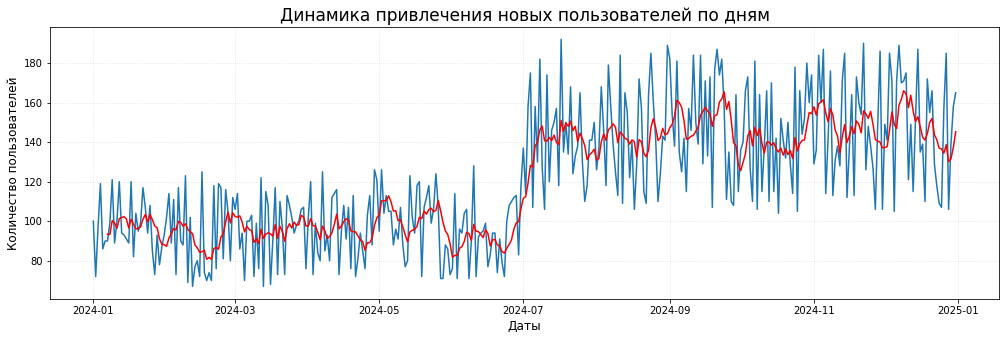

In [12]:
pa_marketplace_users['date'] = pa_marketplace_users['registration_date'].dt.date

new_users_day = pa_marketplace_users.groupby('date')['user_id'].nunique().reset_index()
new_users_day['user_id_r'] = new_users_day.user_id.rolling(7).mean()
plt.subplots(figsize=(17,5))

plt.plot(new_users_day['date'], new_users_day['user_id'])

plt.plot(new_users_day['date'], 
         new_users_day['user_id_r'],  
         color='red', 
         linewidth=1.5)

plt.title('Динамика привлечения новых пользователей по дням', fontsize=17)
plt.xlabel('Даты', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.grid(linestyle=':', alpha=0.4)
plt.show()

Ключевые особенности:
- до середины 2024 года количество новых пользователей держалось в диапазоне 80–120 в день. С июля наблюдается устойчивый рост: среднее значение поднимается со 100 до 140–160, а пики достигают 180+
- синяя линия имеет широкий диапазон, что типично для метрик по дням: влияние выходные, акции, технические сбои, всплески трафика
- регулярные провалы и пики с периодичностью около недели намекают на недельную сезонность

**2) Динамика привлечения новых пользователей по месяцам**

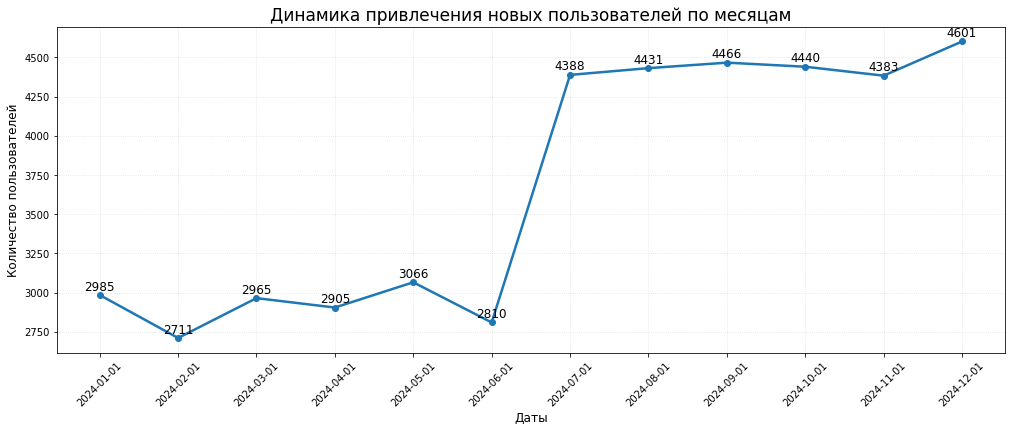

In [13]:
new_users_month = pa_marketplace_users.groupby('cohort_month')['user_id'].nunique().reset_index()
plt.subplots(figsize=(17,6))

plt.plot(new_users_month['cohort_month'], new_users_month['user_id'], linewidth=2.5, marker='o')

plt.title('Динамика привлечения новых пользователей по месяцам', fontsize=17)
plt.xlabel('Даты', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
for x, y in zip(new_users_month['cohort_month'], new_users_month['user_id']):
    plt.annotate(
        f'{y:.0f}',  
        xy=(x, y),
        xytext=(0, 5), 
        textcoords='offset points',
        ha='center',
        fontsize=12,
        color='black'
    )
plt.xticks(rotation=45)
plt.grid(linestyle=':', alpha=0.4)
plt.show()

Ключевые особенности:
- 01.2024–06.2024. Значения колеблются в диапазоне 2711–3066. Минимум - февраль (2711), максимум — май (3066). Июнь (2810) — небольшое снижение.
- Резкий скачок в июле (с 2810 до 4388). Рост на 56% за один месяц. Вероятно, была проведена масштабная рекламная кампания, выход на новый канал или партнёрство.
- 07.2024–11.2024: новый уровень. После скачка метрика держится в узком диапазоне 4383–4466. Это говорит о том, что рост не был разовым всплеском, а закрепился.
- Завершающий месяц года показывает новый максимум (4601). Возможные причины: сезонный спрос (новогодние покупки/подписки), финальные промо-акции.

**3) DAU пользователей**

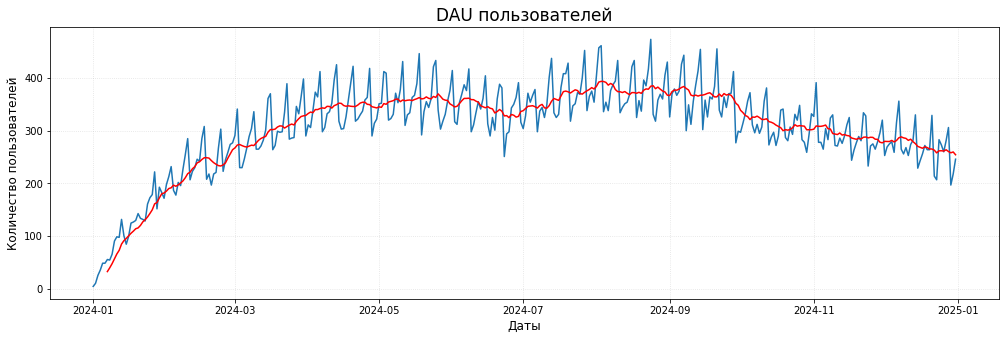

In [14]:
dau = pa_marketplace_events.groupby('event_date')['user_id'].nunique().reset_index()
dau['event_date'] = pd.to_datetime(dau['event_date']).dt.date
dau['user_id_r'] = dau.user_id.rolling(7).mean()
plt.subplots(figsize=(17,5))

plt.plot(dau['event_date'], dau['user_id'])

plt.plot(dau['event_date'], 
         dau['user_id_r'],  
         color='red', 
         linewidth=1.5)

plt.title('DAU пользователей', fontsize=17)
plt.xlabel('Даты', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.grid(linestyle=':', alpha=0.4)
plt.show()

Ключевые особенности:
- Январь–май 2024: устойчивый рост без резких провалов. DAU поднялся с 50 до 350 пользователей в день. Продукт набирает аудиторию, каналы привлечения работают
- Июнь–сентябрь 2024. После мая рост замедлился, тренд держится на уровне 350–370
- Октябрь–январь 2025: постепенное снижение с 360-370 в сентябре до 260–280 к январю следующего года. Общий уровень активности падает.

**4) MAU пользователей**

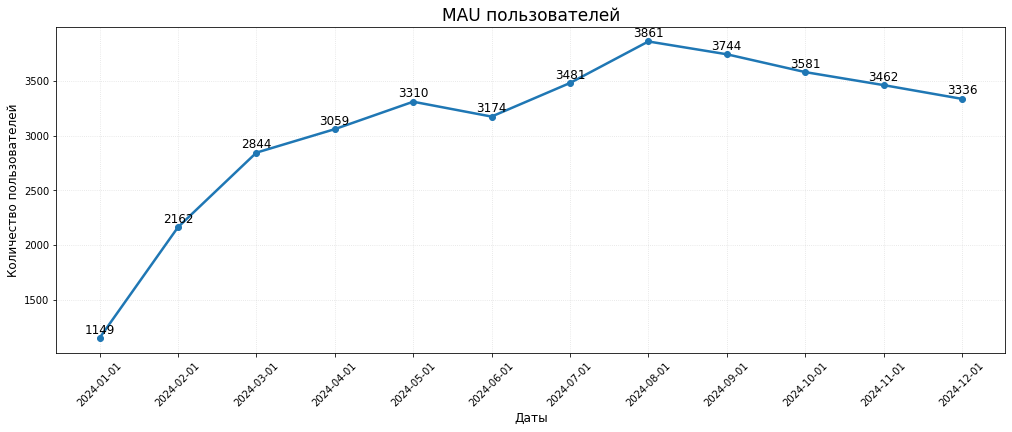

In [15]:
mau = pa_marketplace_events.groupby('event_month')['user_id'].nunique().reset_index()
plt.subplots(figsize=(17,6))

plt.plot(mau['event_month'], mau['user_id'], linewidth=2.5, marker='o')

plt.title('MAU пользователей', fontsize=17)
plt.xlabel('Даты', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
for x, y in zip(mau['event_month'], mau['user_id']):
    plt.annotate(
        f'{y:.0f}',  
        xy=(x, y),
        xytext=(0, 5), 
        textcoords='offset points',
        ha='center',
        fontsize=12,
        color='black'
    )
plt.xticks(rotation=45)
plt.grid(linestyle=':', alpha=0.4)
plt.show()

Особенности:
- Январь–август 2024: рост. MAU вырос с 1149 до 3861 пользователя - почти в 3.4 раза за 8 месяцев. Особенно сильный прирост был в первые три месяца: с 1149 до 2844 (+147%), что говорит о мощном старте
- Август 2024: пик активности. Значение 3861 - абсолютный максимум за год
- Сентябрь–декабрь 2024: снижение. После августа MAU плавно падает с 3861 до 3336 (-13,6% за 4 месяца)

**5) Stickiness**

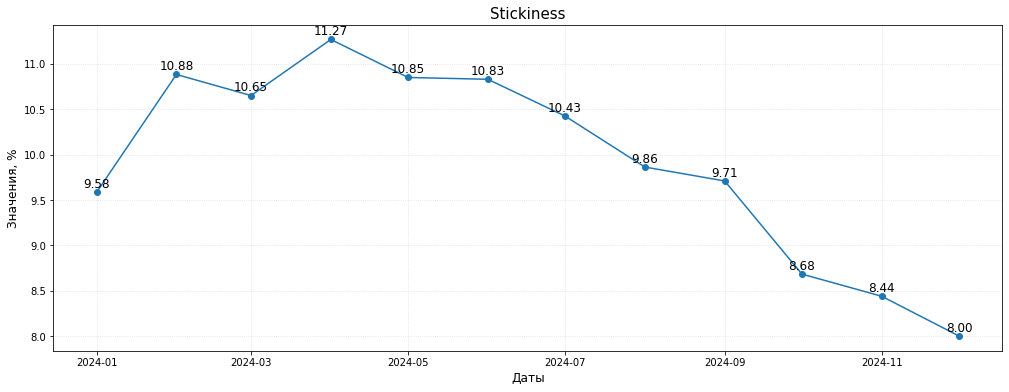

In [16]:
dau['month'] = pd.to_datetime(dau['event_date']).dt.to_period('M').dt.to_timestamp()
mau['event_month'] = pd.to_datetime(mau['event_month']).dt.to_period('M').dt.to_timestamp()
dau_monthly_average = dau.groupby('month')['user_id'].mean().reset_index().rename(columns={'month': 'event_month', 
                                                                                           'user_id': 'user_id_dau'})
stickiness = pd.merge(mau, dau_monthly_average, on='event_month')
stickiness['stick'] = stickiness['user_id_dau'] / stickiness['user_id']*100


plt.subplots(figsize=(17,6))

plt.plot(stickiness['event_month'], stickiness['stick'], marker='o')
plt.title('Stickiness', fontsize=15)
plt.xlabel('Даты', fontsize=12)
plt.ylabel('Значения, %', fontsize=12)
for x, y in zip(stickiness['event_month'], stickiness['stick']):
    plt.annotate(
        f'{y:.2f}',  
        xy=(x, y),
        xytext=(0, 5), 
        textcoords='offset points',
        ha='center',
        fontsize=12,
        color='black'
    )
plt.grid(linestyle=':', alpha=0.4)
plt.show()

Особенности:
- Январь–апрель 2024: рост. Значение Stickiness поднялось с 9,58% до 11,27%. Затем показатель немного упал, но остался на высоком уровне (10,83%)
- Май–сентябрь 2024: плавное снижение. Метрика опустилась с 10,85% до 9,71%. Это может быть эффектом масштабирования: новые пользователи, которые заходят реже, начинают влиять на среднее значение
- Сентябрь-декабрь 2024: выраженный спад с 9,71% в сентябре до 8,00% в декабре. Пользователи стали возвращаться реже, либо изменилась структура аудитории (стало больше редких пользователей)

**6) Средний чек по месяцам**

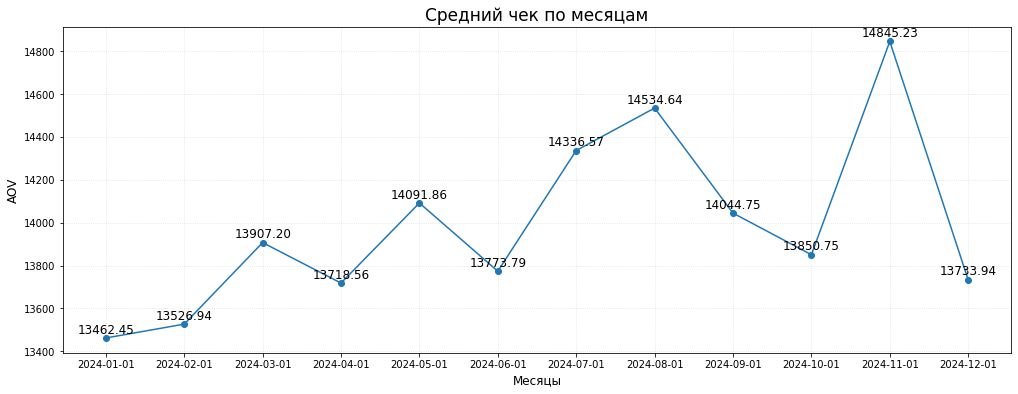

In [17]:
aov_group = pa_marketplace_orders.groupby('order_month').agg(total_sum=('total_price', 'sum'),
                                                       order_quantity=('order_id', 'count')
                                                       ).reset_index()

aov_group['aov'] = aov_group['total_sum'] / aov_group['order_quantity']

plt.figure(figsize=(17,6))
plt.plot(aov_group['order_month'], aov_group['aov'], marker='o')
plt.title('Средний чек по месяцам', fontsize=17)
plt.xlabel('Месяцы', fontsize=12)
plt.ylabel('AOV', fontsize=12)
for x, y in zip(aov_group['order_month'], aov_group['aov']):
    plt.annotate(
        f'{y:.2f}',  
        xy=(x, y),
        xytext=(0, 5), 
        textcoords='offset points',
        ha='center',
        fontsize=12,
        color='black'
    )
plt.grid(linestyle=':', alpha=0.4)
plt.show()

Особенности:
- Январь–март 2024: AOV поднялся с 13462 до 13907 рублей. Вероятно, повышение цен или продажи более дорогих позиций.
- Апрель–июнь 2024: значения колеблются в коридоре 13719–14092 рублей. Возможно, изменился ассортимент, что повлекло к снижению среднего чека
- Июль–август 2024: AOV вырос с 14337 до 14535 рублей. Это может быть связано с сезонным спросом на дорогие товары, сокращением доли дешёвых позиций
- Сентябрь–октябрь 2024: снижение с 14045 до 13851 рубля. Возможно изменение структуры спроса (например, рост доли бюджетных категорий)
- Ноябрь 2024: абсолютный максимум года 14845 рублей. Возможно, причиной стали предновогодние акции, либо всплеск продаж дорогих товаров (техника, подарки)
- Декабрь 2024: резкое падение до 13734 рублей. Возможные причины: массовые распродажи и скидки, рост доли дешёвых товаров в чеке.

**7) Cредняя выручка на одного пользователя по месяцам**

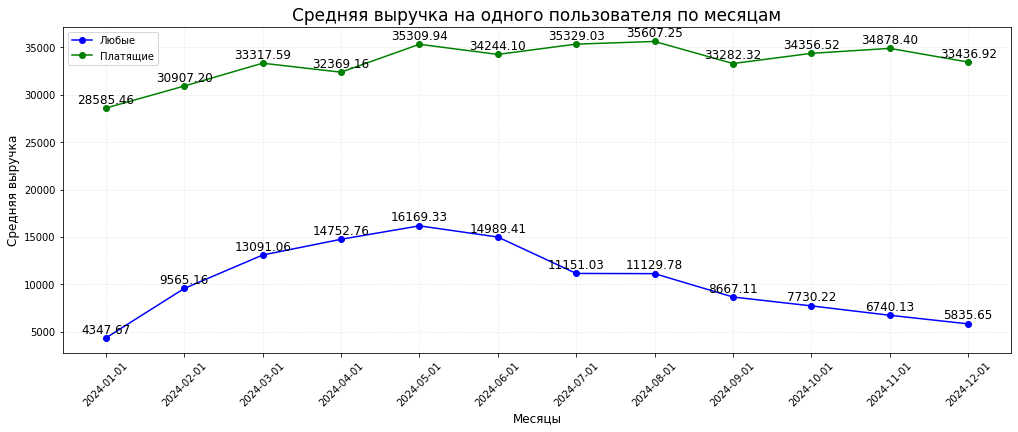

In [18]:
users = pa_marketplace_users.groupby('cohort_month')['user_id'].nunique().reset_index(name='users')
revenue = pa_marketplace_orders.groupby('order_month').agg(total_sum=('total_price', 'sum'),
                                                       buyers=('user_id', 'nunique')
                                                       ).reset_index().rename(columns={'order_month':'cohort_month'})
revenues = pd.merge(users, revenue, on='cohort_month')
revenues['arpu'] = revenues['total_sum'] / revenues['users']
revenues['arppu'] = revenues['total_sum'] / revenues['buyers']

plt.subplots(figsize=(17,6))

plt.plot(revenues['cohort_month'], revenues['arpu'], marker='o', color='blue')
for x, y in zip(revenues['cohort_month'], revenues['arpu']):
    plt.annotate(
        f'{y:.2f}',  
        xy=(x, y),
        xytext=(0, 5), 
        textcoords='offset points',
        ha='center',
        fontsize=12,
        color='black'
    )

plt.plot(revenues['cohort_month'], revenues['arppu'], marker='o', color='green')  
for x, y in zip(revenues['cohort_month'], revenues['arppu']):
    plt.annotate(
        f'{y:.2f}',  
        xy=(x, y),
        xytext=(0, 5), 
        textcoords='offset points',
        ha='center',
        fontsize=12,
        color='black'
    )
                              
plt.title('Cредняя выручка на одного пользователя по месяцам', fontsize=17)
plt.legend(labels=['Любые', 'Платящие'], loc='best')
plt.xlabel('Месяцы', fontsize=12)
plt.ylabel('Средняя выручка', fontsize=12)
plt.xticks(rotation=45)
plt.grid(linestyle=':', alpha=0.4)
plt.show()

Сегмент «Платящие пользователи» (зелёная линия):
- Январь-май: плавный подъём с 28585 до 35309 рублей
- Июнь–август: стабилизация на высоком уровне - 34244–35607 рублей
- Сентябрь–декабрь: слабое снижение до 33437 рублей
Средний платёж одного платящего пользователя в целом стабилен, а небольшое снижение в конце года может быть связано с изменением структуры покупок (например, больше мелких платежей, меньше крупных).

Сегмент «Любые пользователи» (синяя линия):
- Январь-май: рост с 4348 до 16169 рублей
- Июнь–август: небольшое снижение до 11130 рублей
- Август–декабрь: устойчивое падение до 5836 рублей<br>
Резкий контраст с зелёной линией: если у платящих выручка держится на высоком уровне, то общая средняя выручка падает - значит, доля платящих пользователей в общей базе сокращается либо растёт доля «бесплатных» пользователей.

**9) Динамика рекламных расходов по месяцам**

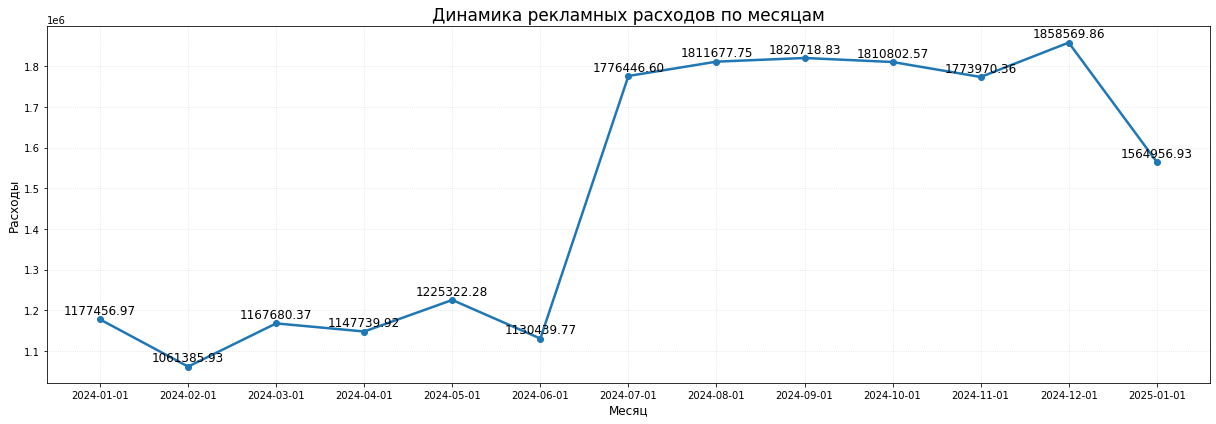

In [19]:
ads = pa_marketplace_campaign_costs.groupby('spend_month')['budget'].sum().reset_index()

plt.figure(figsize=(17,6))
plt.plot(ads['spend_month'], ads['budget'], marker='o', linewidth=2.5)
plt.title('Динамика рекламных расходов по месяцам', fontsize=17)
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Расходы', fontsize=12)
for x, y in zip(ads['spend_month'], ads['budget']):
    plt.annotate(
        f'{y:.2f}',  
        xy=(x, y),
        xytext=(0, 5), 
        textcoords='offset points',
        ha='center',
        fontsize=12,
        color='black',
        fontweight=500
    )
plt.grid(linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

Особенности:
- Январь–июнь 2024: небольшие колебания в диапазоне 1,06–1,23 млн рублей
- Июль 2024: резкий скачок с 1,13 млн в июне до 1,78 млн рублей в июле. Такой скачок типичен для масштабирования, запуска крупной кампании или выхода на новый канал
- Август–декабрь 2024: удержание на высоком уровне с пиком в декабре (1,86 млн рублей). Это говорит о поддержании высокой интенсивности рекламы
- К январю 2025: резкое снижение до 1,56 млн рублей. Возможно, сокращение бюджета.

**10) Retention Rate по когортам**

In [20]:
cmap = mcolors.LinearSegmentedColormap.from_list('green_red', ['#FF3333', '#FFFF66', '#4C9900'], N=100)

pa_marketplace_orders['order_month'] = pd.to_datetime(pa_marketplace_orders['order_month'])
pa_marketplace_orders['first_order_month'] = pa_marketplace_orders.groupby('user_id')['order_month'].transform('min')
pa_marketplace_orders['last_order_month'] = pa_marketplace_orders.groupby('user_id')['order_month'].transform('max')
pa_marketplace_orders['n_period'] = pa_marketplace_orders['last_order_month'].dt.to_period('M').astype('int64') - pa_marketplace_orders['first_order_month'].dt.to_period('M').astype('int64')

In [21]:
pa_marketplace_orders['first_order_month'] = pa_marketplace_orders['first_order_month'].dt.date

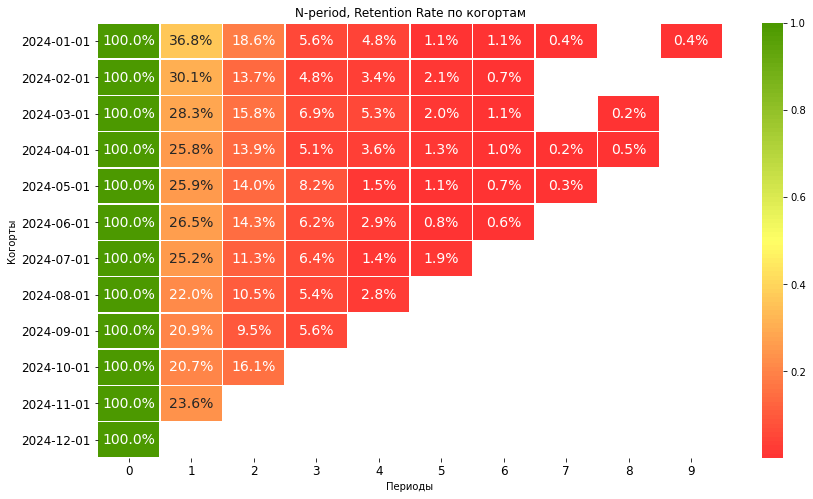

In [22]:
data_pivot = pd.pivot_table(pa_marketplace_orders, values='user_id', index='first_order_month', columns='n_period', aggfunc=pd.Series.nunique).fillna(0).astype(int)

data_pivot = data_pivot.div(data_pivot[0], axis=0)
data_pivot[data_pivot==0]=float('nan')

plt.subplots(figsize=(14,8))
sns.heatmap(data_pivot, cmap=cmap, annot=True, fmt='.1%', linewidth=0.5, annot_kws={'size':14})
                              
plt.title('N-period, Retention Rate по когортам')
plt.xlabel('Периоды')
plt.ylabel('Когорты')
plt.xticks(rotation=0)
plt.tick_params(labelsize=12)
plt.show()

Ключевые особенности:
- Первый месяц: удержание колеблется от 20,7% (когорта октября) до 36,8% (когорта января). Это может говорить об ухудшении качества привлечения
- Второй месяц: значения в диапазоне 9,5–18,6%
- Третий и далее месяцы: удержание быстро падает до единиц и долей процента. Основная часть пользователей отваливается в первые 1–3 месяца

Сравнение когорт<br>
Сильные когорты: январь (36,8% в 1‑м периоде, 18,6% во 2‑м) и февраль (30,1% и 13,7%) — у них выше удержание на всех этапах.
Слабые когорты: сентябрь (20,9% и 9,5%) и август (22,0% и 10,5%) — у них заметно хуже показатели, особенно во 2‑м периоде.
Аномалия октября: у когорты октября необычно высокий показатель во 2‑м периоде (16,1%) при низком в 1‑м (20,7%). Возможно, пользователи начали активно пользоваться продуктом не сразу, а через месяц.

Возможные проблемы:
- продукт либо не закрывает долгосрочную потребность, либо не умеет «привязывать» пользователей (нет регулярных сценариев использования, персонализации, лояльности)
- если в первый месяц теряется 70–80% пользователей, значит, не работает онбординг, не очевидна ценность продукта или есть барьеры для первого успешного действия
- снижение удержания у поздних когорт: либо ухудшилось качество трафика, либо продукт стал менее привлекательным, либо усилилась конкуренция

**Рассчитаем конверсию из регистрации в первый заказ**

In [23]:
reg_users = pa_marketplace_users.groupby('cohort_month')['user_id'].nunique().reset_index()
reg_users['cohort_month'] = pd.to_datetime(reg_users['cohort_month'])

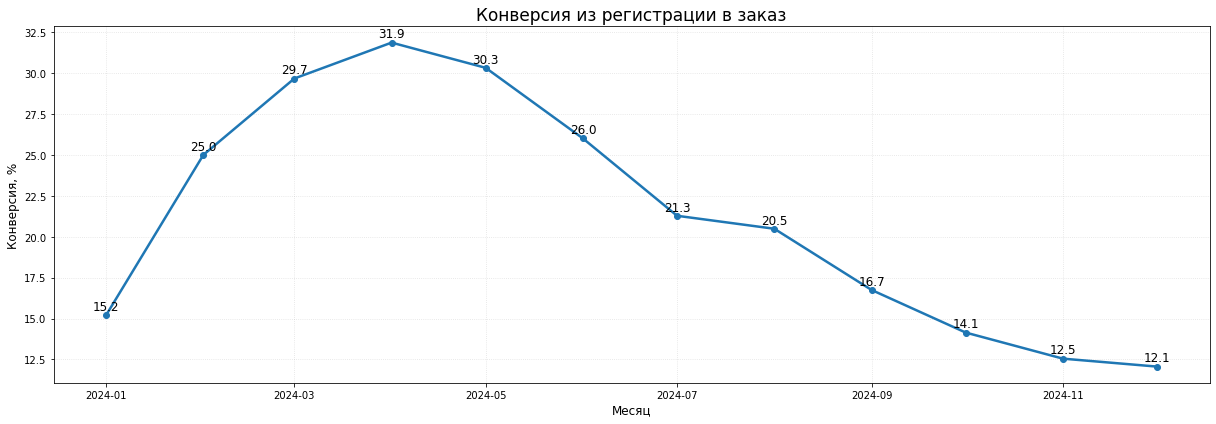

In [24]:
pa_marketplace_orders2 = pa_marketplace_orders.drop_duplicates(subset=['user_id'], keep='first')
order_users = pa_marketplace_orders2.groupby('order_month')['user_id'].nunique().reset_index().rename(columns={'order_month': 'cohort_month',
                                                                                                             'user_id': 'order_users'})
reg_order_users = pd.merge(reg_users, order_users, on='cohort_month')
reg_order_users['conv'] = reg_order_users['order_users'] / reg_order_users['user_id'] *100
reg_order_users

plt.figure(figsize=(17,6))
plt.plot(reg_order_users['cohort_month'], reg_order_users['conv'], marker='o', linewidth=2.5)
plt.title('Конверсия из регистрации в заказ', fontsize=17)
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Конверсия, %', fontsize=12)
for x, y in zip(reg_order_users['cohort_month'], reg_order_users['conv']):
    plt.annotate(
        f'{y:.1f}',  
        xy=(x, y),
        xytext=(0, 5), 
        textcoords='offset points',
        ha='center',
        fontsize=12,
        color='black',
        fontweight=500
    )
plt.grid(linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

Ключевые особенности:
- Резкий рост конверсии в первом квартале с 15% в январе до 32% в апреле - рост в 2 раза за 3 месяца. 
- Пик конверсии - апрель (32%).
- Резкий обвал после апреля. С 32% в апреле до 21% в июле, а затем - до 20,5% в августе.
- Снижение во второй половине года. С июля (21%) до декабря (12%) конверсия упала на 9 п.п.
- Декабрь  минимальное значение за год (12%).

Рост конверсии с января по апрель может быть связан с запуском промо‑механик для новых пользователей, бонусами за первую покупку, упрощённой регистрацией или внешними факторами (праздники, начало года).
Падение конверсии к ноябрю - тревожный сигнал: новые регистрации всё реже превращаются в заказы, что напрямую бьёт по выручке и окупаемости привлечения. Если затраты на привлечение новых пользователей остаются на прежнем уровне, а конверсия падает, ROI маркетинга будет снижаться - нужно либо сокращать бюджет, либо срочно повышать конверсионность воронки.

---

**Вывод**

Продукт прошёл этап активного масштабирования в первой половине года и столкнулся с замедлением роста и ухудшением эффективности во второй.

Положительные стороны
1) Масштабное расширение базы пользователей. Резкий рост привлечения в июле закрепился на новом уровне (4383–4601 новых пользователей в месяц). Рост MAU - сильный результат, подтверждающий работоспособность каналов привлечения.<br>
2) Стабильность выручки от платящих пользователей. Средний платёж одного платящего пользователя держался на высоком уровне (34-35 тыс. рублей), а в ноябре был зафиксирован пик среднего чека (14845 рублей) - вероятно, за счёт предновогоднего спроса. Это говорит о том, что платящая аудитория остаётся лояльной и сохраняет покупательскую способность.<br>
3) Рост активности в начале года. DAU стабильно рос с января по май (с 50 до 350 пользователей в день), а Stickiness поднялся с 9,58% до 11,27% - продукт успешно вовлекал аудиторию на старте.

Проблемы
1) Падение общей выручки на пользователя. Хотя выручка от платящих стабильна, средняя выручка на любого пользователя упала с 16169 рублей в мае до 5836 рублей в декабре. Это сигнализирует о снижении доли платящих пользователей либо о росте доли бесплатной аудитории с низкой монетизацией.<br>
2) Ухудшение удержания и вовлечённости. Stickiness к декабрю снизился до 8% (с пика 11,27%), а Retention Rate в первый месяц колеблется от 20,7% до 36,8% - большая часть пользователей уходит в первые месяцы. Особенно тревожно снижение удержания у поздних когорт, что может указывать на ухудшение качества трафика или ослабление ценности продукта.<br>
3) Замедление роста активности. DAU после мая стабилизировался на уровне 350–370, а с октября начал снижаться до 260–280 к январю 2025 года. MAU после августовского пика (3861) также плавно снизился к декабрю.<br>
4) Сезонное давление на средний чек. Декабрьский спад среднего чека до 13734 рублей (после ноябрьского пика) может быть следствием массовых скидок.

Масштабная закупка трафика в июле дала прирост базы, но не обеспечила роста выручки и удержания. Ядро платящих пользователей стабильно, но его доля в общей базе сокращается. Это создаёт риск зависимости от постоянного притока новых пользователей и роста рекламных расходов. Необходимо сфокусироваться на удержании и вовлечённости, оптимизировать рекламные расходы и учесть сезонность в планировании.

---

### 3. Оценка метрик монетизации и юнит-экономики

Выполните анализ монетизации. Определите, сколько зарабатывает продукт и сколько тратит на привлечение.

Важны как агрегированные метрики (ARPU, AOV), так и показатели эффективности (CAC, ROI, Payback Period).

Сформулируйте первые выводы по результатам анализа метрик. Сделайте это в формате записки для заказчика. Изложите все основные результаты так, чтобы прослеживалась связь между мыслями. Не пишите много — заказчик не будет читать записку полностью, а просто просмотрит.

Напишите выводы в конце блока, чтобы заказчик мог быстро ознакомиться с основными результатами.

**1) Рассчитаем САС по месяцам**

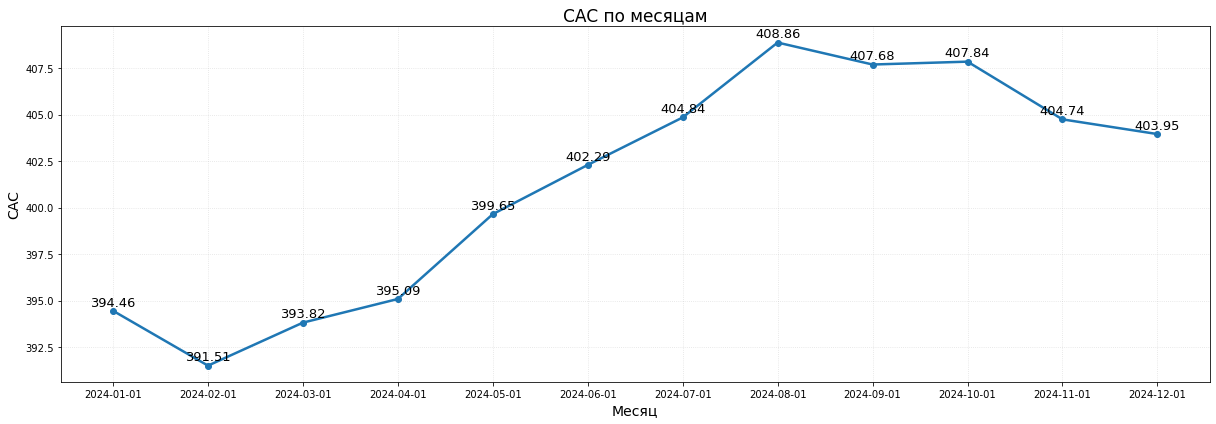

In [25]:
ads = ads.rename(columns={'spend_month': 'cohort_month'})
ad_costs = pd.merge(ads, new_users_month, on='cohort_month')
ad_costs['cac'] = ad_costs['budget'] / ad_costs['user_id']


plt.figure(figsize=(17,6))
plt.plot(ad_costs['cohort_month'], ad_costs['cac'], marker='o', linewidth=2.5)
plt.title('CAC по месяцам', fontsize=17)
plt.xlabel('Месяц', fontsize=14)
plt.ylabel('CAC', fontsize=14)
for x, y in zip(ad_costs['cohort_month'], ad_costs['cac']):
    plt.annotate(
        f'{y:.2f}',  
        xy=(x, y),
        xytext=(0, 5), 
        textcoords='offset points',
        ha='center',
        fontsize=13,
        color='black',
        fontweight=500
    )
plt.grid(linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

Ключевые особенности:
- Январь–февраль 2024: снижение CAC с 395 рублей в январе до 392 рублей в феврале. Это может быть связано с низкой сезонной активностью, более дешёвыми каналами или точечными акциями
- Март–август 2024: устойчивый рост CAC с 394 рублей до 409 рублей. Пик приходится на август, это может быть следствием масштабирования в дорогих каналах
- Сентябрь–декабрь 2024: CAC упал до 404 рублей. Возможные причины: оптимизация кампаний, перераспределение бюджета в более дешёвые каналы, снижение сезонного спроса.

Рост CAC в середине года - сигнал о повышении стоимости трафика. Снижение CAC к концу года - позитивный сигнал, но важно проверить, не связано ли оно с сокращением объёма трафика или переходом на менее релевантную аудиторию.

Возможные причины динамики
1) Переход на более дорогие каналы повышает средний CAC<br>
2) Оптимизация и перераспределение. Снижение CAC в конце года может быть результатом отключения неэффективных кампаний, перераспределения бюджета.

 **2) Рассчитаем LTV и ROI по месяцам**

In [26]:
unit = pd.merge(revenues, ad_costs, on='cohort_month')
unit['ltv'] = unit['total_sum']*0.05 / unit['user_id']
unit['roi'] = (unit['ltv'] - unit['cac']) / unit['cac'] * 100

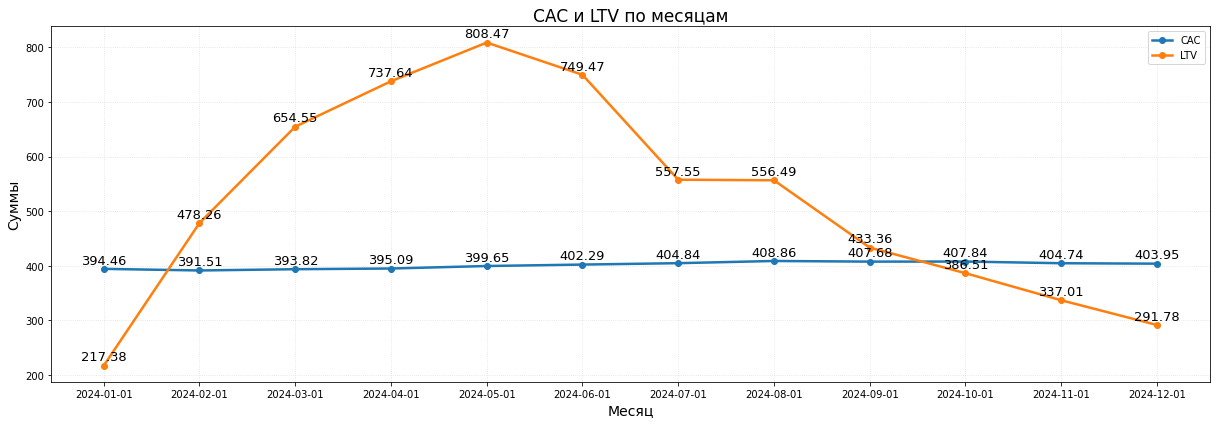

In [27]:
plt.figure(figsize=(17,6))

plt.plot(unit['cohort_month'], unit['cac'], marker='o', linewidth=2.5)
for x, y in zip(unit['cohort_month'], unit['cac']):
    plt.annotate(
        f'{y:.2f}',  
        xy=(x, y),
        xytext=(0, 5), 
        textcoords='offset points',
        ha='center',
        fontsize=13,
        color='black',
        fontweight=500
    )
    
plt.plot(unit['cohort_month'], unit['ltv'], marker='o', linewidth=2.5)
for x, y in zip(unit['cohort_month'], unit['ltv']):
    plt.annotate(
        f'{y:.2f}',  
        xy=(x, y),
        xytext=(0, 5), 
        textcoords='offset points',
        ha='center',
        fontsize=13,
        color='black',
        fontweight=500
    )

plt.title('CAC и LTV по месяцам', fontsize=17)
plt.xlabel('Месяц', fontsize=14)
plt.ylabel('Суммы', fontsize=14)
plt.legend(labels=['CAC', 'LTV'], loc='best')
plt.grid(linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

Рассмотрим САС и LTV в динамике

CAC (синяя линия) имеет диапазон 387–409 рублей с небольшими колебаниями, минимум в октябре (387 рублей), максимум в августе (409 рублей)
LTV (оранжевая линия) имеет диапазон 217–808 рублей с резким ростом с января (217 рублей) по май (808 рублей) и снижением до декабря. График имеет вид горба в середине года<br>
Графики пересекаются в январе и сентябре. В ноябре–декабре LTV < CAC - привлечение становится убыточной.

Пик LTV в мае: следствие высокой конверсии, роста среднего чека.<br>
Спад LTV во второй половине года: ухудшилось удержание, снизилась монетизация, новые пользователи приносят меньше дохода.<br>
Перекрест LTV и CAC: начиная с октября каждый новый клиент окупается хуже или не окупается вовсе.<br>
Стабильный CAC при падающем LTV - плохая комбинация: при одинаковых затратах на привлечениедоход от клиентов ниже.

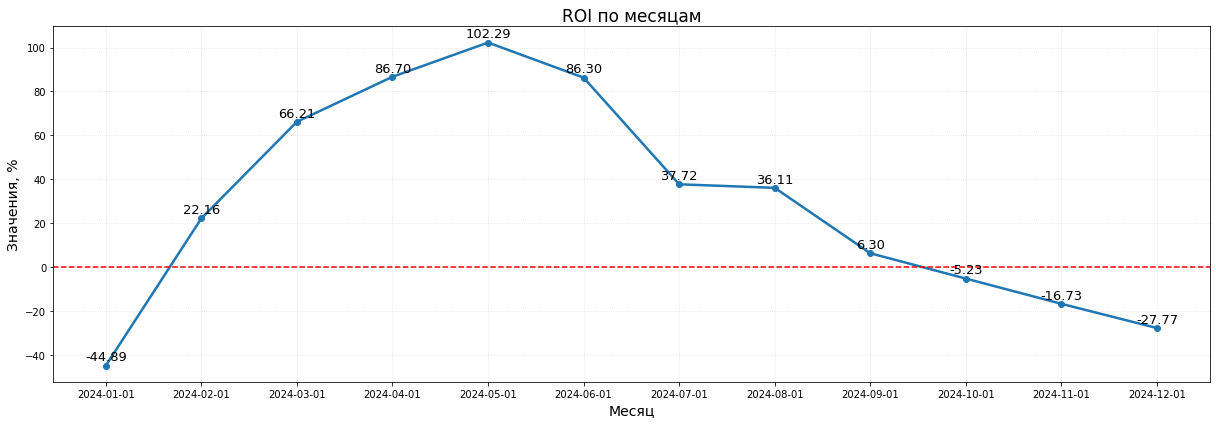

In [28]:
plt.figure(figsize=(17,6))
plt.plot(unit['cohort_month'], unit['roi'], marker='o', linewidth=2.5)
for x, y in zip(unit['cohort_month'], unit['roi']):
    plt.annotate(
        f'{y:.2f}',  
        xy=(x, y),
        xytext=(0, 5), 
        textcoords='offset points',
        ha='center',
        fontsize=13,
        color='black',
        fontweight=500
    )
plt.axhline(y=0, color='red', linestyle='--')
plt.title('ROI по месяцам', fontsize=17)
plt.xlabel('Месяц', fontsize=14)
plt.ylabel('Значения, %', fontsize=14)
plt.grid(linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

Особенности графика
- Январь 2024: глубокий минус (-45%). Старт года убыточный: инвестиции не окупились, вероятно, из‑за высоких стартовых затрат, низкой конверсии или сезонного спада
- Февраль–май 2024: стремительный рост. ROI вырос с 22% в феврале до пика в 102% в мае
- Июнь–июль 2024: умеренное снижение. ROI упал с 86% в июне до 38% в июле. Причиной могло стать увеличение стоимости трафика, сезонные колебания
- Август–декабрь 2024: устойчивый спад ниже порога окупаемости. ROI снизился с 36% в августе до -28% в декабре. С сентября показатель стабильно ниже 0%: инвестиции перестают окупаться.

Наблюдаются большие колебания в графике: от -44,89% до +102,29% - разброс более чем в 4,5 раза. С октября ROI стабильно отрицательный - каждый вложенный рубль приносит убыток. Это требует срочного пересмотра стратегии.
Май был успешным, но последующие месяцы показывают, что эффект не удалось закрепить. Конец года оказался убыточным вследствие увеличения стоимости привлечения без роста среднего чека.

---

**Вывод**

В первой половине года бизнес демонстрировал рост эффективности привлечения и монетизации, но во второй половине произошло обратное - экономика привлечения стала убыточной из‑за падения LTV при стабильно высокой стоимости трафика.

Положительные моменты первой половины года
1) Рост LTV, ROI в плюсе. LTV вырос с 217 рублей в январе до пика в 808 рублей в мае - это следствие роста среднего чека и более лучших показателей удержания ранних когорт. Параллельно ROI поднялся с -45% в январе до 102% в мае, что говорит о сильной отдаче вложений.<br>
2) Относительная стабильность CAC. В первом квартале CAC колебался в узком диапазоне 392-395 рублей, что позволяло масштабироваться без резкого роста стоимости привлечения.<br>
3) Рост LTV опережал рост CAC, что обеспечивало положительную экономику.

Проблемы второй половины года
1) Спад LTV при стабильном CAC. После майского пика LTV начал устойчиво снижаться и к декабрю опустился ниже уровня CAC. Это означает, что доход от новых клиентов перестал покрывать затраты на их привлечение.<br>
2) Отрицательный ROI с октября. ROI стабильно ниже 0% в октябре-декабре (до -28% в декабре). При этом CAC оставался на высоком уровне (387-409 рублей), а LTV не смог компенсировать рост стоимости трафика.<br>
3) Линии LTV и CAC пересеклись в сентябре, а в ноябре-декабре LTV < CAC, привлечение новых пользователей стало убыточным.<br>
4) Высокая волатильность ROI. Разброс показателя более чем в 4,5 раза (от -44,89% до +102,29%) говорит о нестабильности: успех мая не удалось закрепить, а последующие месяцы показали ускоряющийся убыток.<br>
5) Снижение среднего чека в декабре. Падение среднего чека до 13734 рублей (после ноябрьского пика в 14845 рублей) на фоне высоких рекламных расходов дополнительно ухудшило экономику.

Снижение LTV во второй половине года связано с ухудшением удержания, они приносят меньше дохода, чем ранние когорты. Бизнес делал ставку на рост объёма трафика (в том числе за счёт увеличения рекламных расходов), но не смог удержать экономику на устойчивом уровне.

---

## Итоговый вывод


Успех первой половины года был построен на эффекте низкой базы, улучшении удержания ранних когорт и росте среднего чека. Это дало всплеск LTV и ROI при умеренном CAC.
Во второй половине года модель «масштабирования любой ценой» перестала работать: LTV новых когорт оказался ниже CAC, ROI ушёл в минус, а доля платящих пользователей в общей базе сократилась.
Ключевая проблема не в отсутствии трафика, а в ухудшении качества новых когорт и слабой монетизации растущей бесплатной аудитории.

## 4. Поиск инсайтов, точек роста и сегментация


После того как вы провели верхнеуровневую оценку данных, самое время переходить от общей картины к точечным наблюдениям. Посмотрите вглубь данных: по каналам,
сегментам пользователей, категориям товаров, регионам, типам устройств. Ищите
закономерности, различия, аномалии.

Цель — сформировать обоснованные гипотезы:

* какие сегменты работают лучше остальных
* какие сегменты работают хуже остальных
* на каких этапах воронки теряются пользователи
* какие группы можно или нужно масштабировать
* куда стоит инвестировать больше внимания или ресурсов

По итогам анализа также:

* сформулируйте в виде аналитической записки выводы
* сформулируйте несколько гипотез, которые помогут развить продукт. Например: «Если предлагать клиентам на iOS персонализированные скидки, то они станут чаще конвертировать в продукт». При формулировании гипотез опишите, на что вы опираетесь при её формировании. Например, на динамику метрики или на взаимосвязь метрик.

Напишите выводы в конце блока, чтобы заказчик мог быстро ознакомиться с основными результатами.
Отправьте работу на проверку ревьюеру. Ревьюер будет проверять корректность выводов и гипотез, а не сам код расчета, поэтому проверьте, что у вас есть выводы по каждому из блоков в предназначенном для этого месте.
После завершения ревью вы получите от ревьюера новые вводные и задачу от бизнеса.


**Рассмотрим гендерное распределение пользователей**

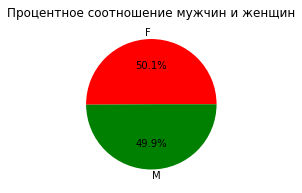

In [29]:
gender = pa_marketplace_users.groupby('gender')['user_id'].nunique().reset_index()
gender['share'] = gender['user_id'] / gender['user_id'].sum()
gender['share'].plot(
    figsize=(3, 3),
    kind='pie',
    title='Процентное соотношение мужчин и женщин',fontsize=10,
    autopct='%.1f%%',
    ylabel='',
    colors=['red', 'green'],
    labels=gender['gender']
)
plt.show()

In [30]:
men = pa_marketplace_users[pa_marketplace_users['gender']== 'M']
women = pa_marketplace_users[pa_marketplace_users['gender']== 'F']

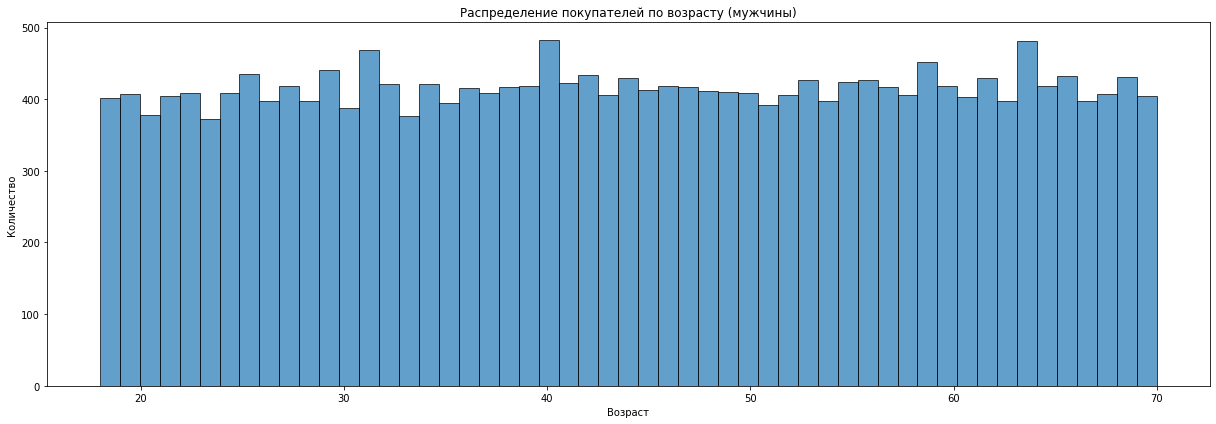

In [31]:
plt.figure(figsize=(17,5))
men['age'].hist(figsize=(17, 6), bins=53, edgecolor='black', alpha=0.7)
plt.title('Распределение покупателей по возрасту (мужчины)')
plt.xlabel('Возраст')          
plt.ylabel('Количество')
plt.tight_layout()
plt.grid(alpha=0.3)
plt.show()

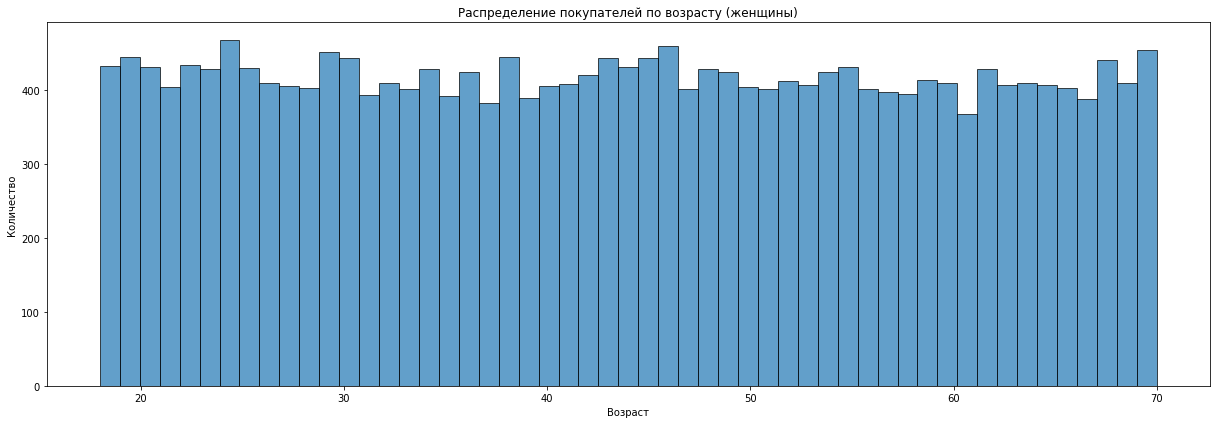

In [32]:
plt.figure(figsize=(17,5))
women['age'].hist(figsize=(17, 6), bins=53, edgecolor='black', alpha=0.7)
plt.title('Распределение покупателей по возрасту (женщины)')
plt.xlabel('Возраст')          
plt.ylabel('Количество')
plt.tight_layout()
plt.grid(alpha=0.3)
plt.show()

In [33]:
men['age'].describe().reset_index()

,index,age
0,count,22025.000000
1,mean,44.175165
2,std,15.238133
3,min,18.000000
4,25%,31.000000
5,50%,44.000000
6,75%,57.000000
7,max,70.000000


In [34]:
women['age'].describe().reset_index()

,index,age
0,count,22126.000000
1,mean,43.812483
2,std,15.347287
3,min,18.000000
4,25%,30.000000
5,50%,44.000000
6,75%,57.000000
7,max,70.000000


На круговой диаграмме показано практически равное процентное соотношение мужчин и женщин в исследуемой выборке: женщины составляют 50,1%, мужчины - 49,9%, что свидетельствует о сбалансированности по гендерному признаку.

*Мужчины*<br>
Количество покупателей в каждой возрастной группе держится на уровне 380–450 человек, резких провалов нет. Наиболее выраженные всплески приходятся на возраст 40 и 63 лет (выше 470 человек). Это может указывать на отдельные сегменты с повышенной вовлечённостью (активные покупатели среднего возраста и мужчины предпенсионного/пенсионного возраста).
Распределение близко к равномерному, без резкого перекоса в сторону молодёжи или пожилых.

*Женщины*<br>
Аналогично мужской аудитории равномерное распределение по возрасту без выраженного доминирующего сегмента. Количество покупательниц в разных возрастах колеблется в диапазоне примерно 380–450 человек. Нет возрастных групп, где спрос резко падает.
На графике есть отдельные пики в районе 25, 45 и 70 лет.

Нет рисков, связанных с демографическими колебаниями: даже если одна возрастная когорта сократится, спрос может быть поддержан другими сегментами. Существует баланс между молодежью и пожилой аудиторией. Ценность продукта воспринимается одинаково в разных поколениях.

**Посмотрим на пользователей в разбивке по регионам**

In [35]:
regions = pa_marketplace_users.groupby('region')['user_id'].nunique().sort_values()

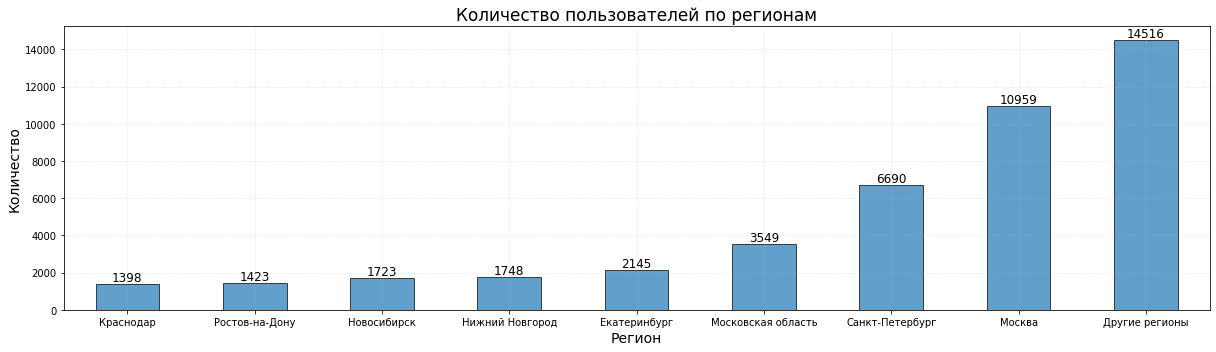

In [36]:
diagr = regions.plot(kind='bar', figsize=(17, 5), legend=False, rot=0, edgecolor='black', alpha=0.7)
plt.title('Количество пользователей по регионам',fontsize=17)
plt.ylabel('Количество', fontsize=14)
plt.xlabel('Регион', fontsize=14)
for bar in diagr.patches:
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width()/2,
                height + 0.1, 
                f'{height}',
                ha='center',
                va='bottom',
                fontsize=12,
                color='black')
plt.grid(linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

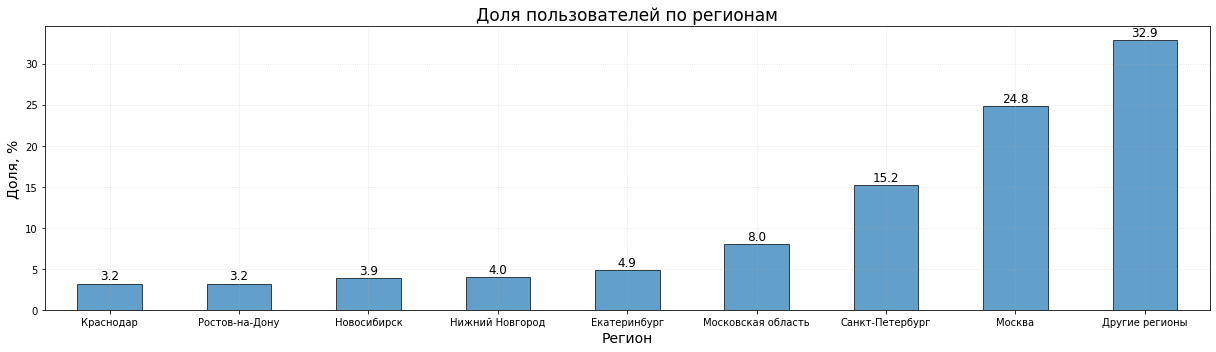

In [37]:
regions_per = regions.copy().reset_index()
regions_per['share'] = (regions_per['user_id'] / regions_per['user_id'].sum()*100).round(1)

diagr2 = regions_per.plot(x='region', y='share', kind='bar', figsize=(17, 5), legend=False, rot=0, edgecolor='black', alpha=0.7)
plt.title('Доля пользователей по регионам',fontsize=17)
plt.ylabel('Доля, %', fontsize=14)
plt.xlabel('Регион', fontsize=14)
for bar in diagr2.patches:
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width()/2,
                height + 0.1, 
                f'{height}',
                ha='center',
                va='bottom',
                fontsize=12,
                color='black')
plt.grid(linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

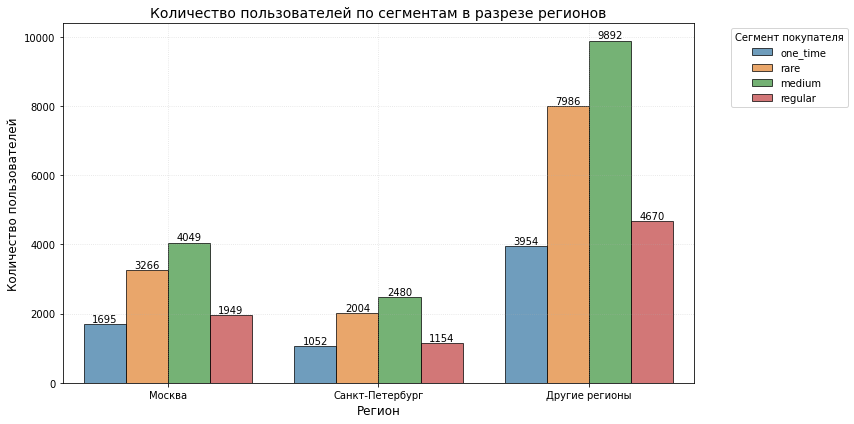

In [38]:

# Другие регионы
other_regions = pa_marketplace_users[~pa_marketplace_users['region'].isin(['Москва', 'Санкт-Петербург'])]
other_regions = other_regions.groupby('buyer_segment')['user_id'].nunique().reset_index()
other_regions['region'] = 'Другие регионы'
other_regions = other_regions[['region', 'buyer_segment', 'user_id']]

# Мос и СПб
main = pa_marketplace_users[pa_marketplace_users['region'].isin(['Москва', 'Санкт-Петербург'])]
main = main.groupby(['region', 'buyer_segment'])['user_id'].nunique().reset_index()

# Объединение и визуализация
region_segment = pd.concat([main, other_regions])
order = ['one_time', 'rare', 'medium', 'regular']
region_segment['buyer_segment'] = pd.Categorical(region_segment['buyer_segment'], 
                                     categories=order, 
                                     ordered=True)
region_segment = region_segment.sort_values('buyer_segment')

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=region_segment, x='region', y='user_id', hue='buyer_segment', ax=ax, edgecolor='black', alpha=0.7)

for container in ax.containers:
    # Проходимся по каждому столбцу внутри контейнера
    for bar in container:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, 
                height, 
                f'{int(height)}', 
                ha='center', 
                va='bottom', 
                fontsize=10,
                color='black')

ax.set_title('Количество пользователей по сегментам в разрезе регионов', fontsize=14)
ax.set_xlabel('Регион', fontsize=12)
ax.set_ylabel('Количество пользователей', fontsize=12)

ax.legend(title='Сегмент покупателя', bbox_to_anchor=(1.05, 1), loc='best')
plt.grid(linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()


Лидер по числу пользователей - категория «Другие регионы» (14516 человек, 32,9%), почти треть всей аудитории, больше, чем в Москве (24,8%) и Санкт‑Петербурге (15,2%). Высокая доля аудитории располагается за пределами крупнейших городов. Москва на втором месте (10959 пользователей), Санкт‑Петербург - на третьем (6690). Московская область - 3549 пользователей (8%). Остальные крупные города (Екатеринбург, Нижний Новгород, Новосибирск, Ростов‑на‑Дону, Краснодар) формируют относительно небольшую долю, в совокупности эти города дают менее 20% аудитории.

Таким образом, продукт востребован не только в крупных городах. Москва и Петербург тоже важные драйверы роста. Крупные региональные центры пока не формируют значимого объёма. Это может быть связано с низкой узнаваемостью бренда или особенностями спроса. Тем не менее это стратегически важный сегмент

Рассмотрим основные особенности пользователей по сегментам<br>
- Доминирующий сегмент - medium. Во всех регионах он самый крупный: 4049 (Москва), 2480 (Санкт-Петербург), 9892 (Другие регионы). Это говорит о том, что ядро аудитории - пользователи со средней частотой покупок.
- Сегмент regular - самый маленький во всех регионах. Несмотря на важность лояльных клиентов, их доля относительно невелика: 1949 (Москва), 1154 (Санкт-Петербург), 4670 (Другие регионы).<br>

Схожая структура сегментов в Москве и Санкт-Петербурге. Несмотря на разницу в объёмах, соотношение долей сегментов в столицах близко - это позволяет масштабировать вовлеченность между этими городами.

**Рассмотрим пользователей по каналам привлечения и маркетинговые расходы**

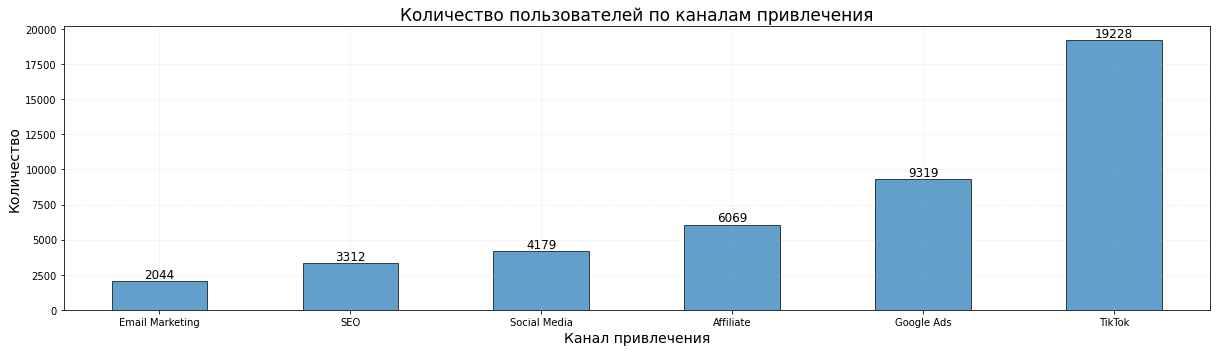

In [39]:
channels = pa_marketplace_users.groupby('acq_channel')['user_id'].nunique().sort_values()

diagr3 = channels.plot(kind='bar', figsize=(17, 5), legend=False, rot=0, edgecolor='black', alpha=0.7)
plt.title('Количество пользователей по каналам привлечения',fontsize=17)
plt.ylabel('Количество', fontsize=14)
plt.xlabel('Канал привлечения', fontsize=14)
for bar in diagr3.patches:
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width()/2,
                height + 0.1, 
                f'{height}',
                ha='center',
                va='bottom',
                fontsize=12,
                color='black')
plt.grid(linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

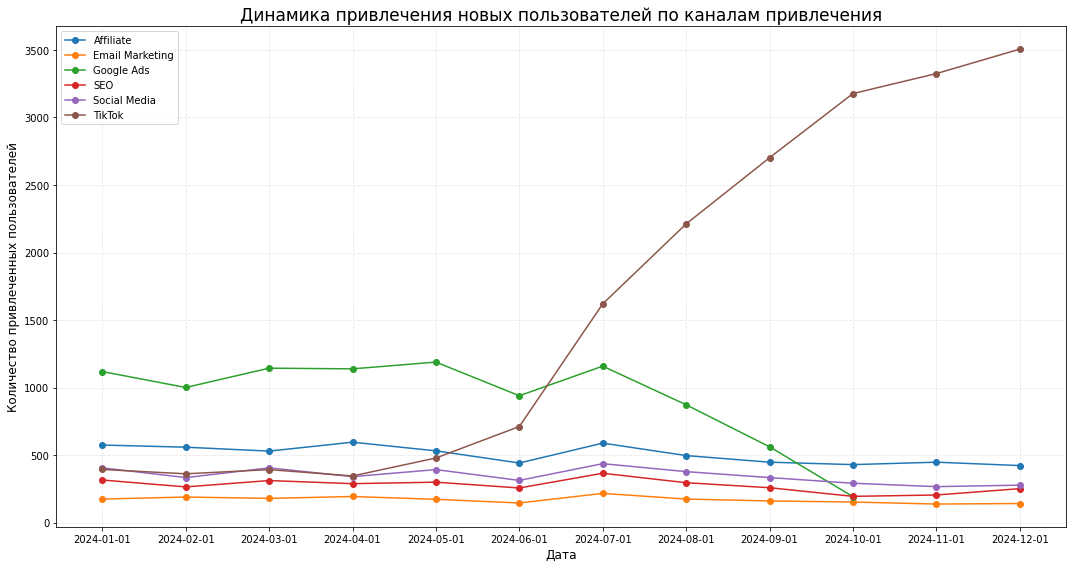

In [40]:
channels_dates = pa_marketplace_users.groupby(['cohort_month','acq_channel'])['user_id'].nunique().reset_index()
plt.figure(figsize=(15,8))

for channel in channels_dates['acq_channel'].unique():
    data_plot = channels_dates[channels_dates['acq_channel']==channel]
    plt.plot(data_plot['cohort_month'], data_plot['user_id'], marker='o', label=channel)
    
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Количество привлеченных пользователей', fontsize=12)
plt.title('Динамика привлечения новых пользователей по каналам привлечения', fontsize=17)
plt.xticks()
plt.legend(channels_dates['acq_channel'].unique())
plt.grid( linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

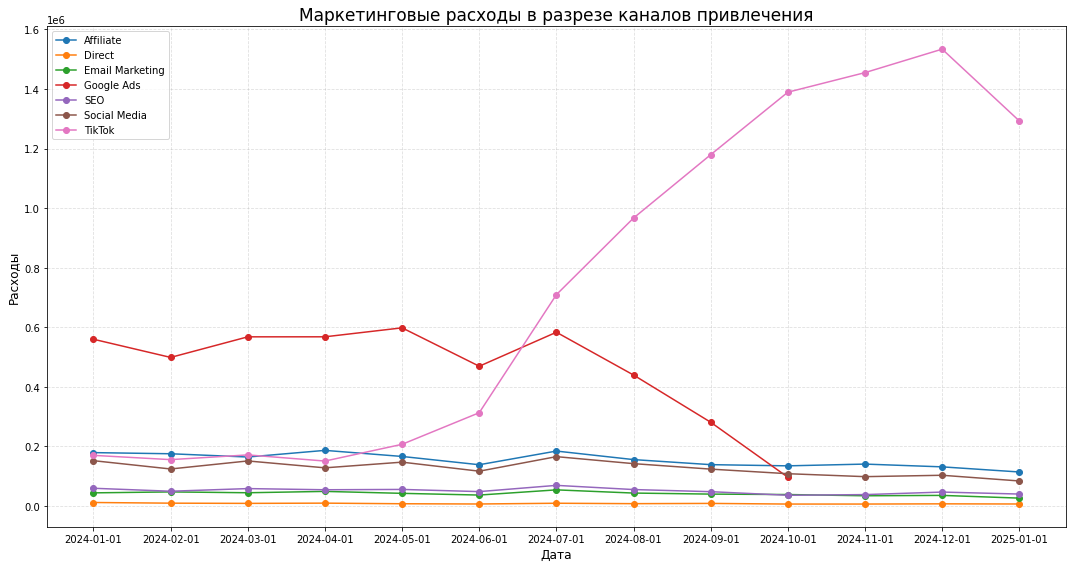

In [41]:
campaign_costs = pa_marketplace_campaign_costs.groupby(['spend_month', 'acq_channel'])['budget'].sum().reset_index().rename(
    columns={'spend_month':'cohort_month'})

plt.figure(figsize=(15,8))

for channel in campaign_costs['acq_channel'].unique():
    data_plot = campaign_costs[campaign_costs['acq_channel']==channel]
    plt.plot(data_plot['cohort_month'], data_plot['budget'], marker='o', label=channel)
    
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Расходы', fontsize=12)
plt.title('Маркетинговые расходы в разрезе каналов привлечения', fontsize=17)
plt.xticks()
plt.legend(campaign_costs['acq_channel'].unique())
plt.grid( linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

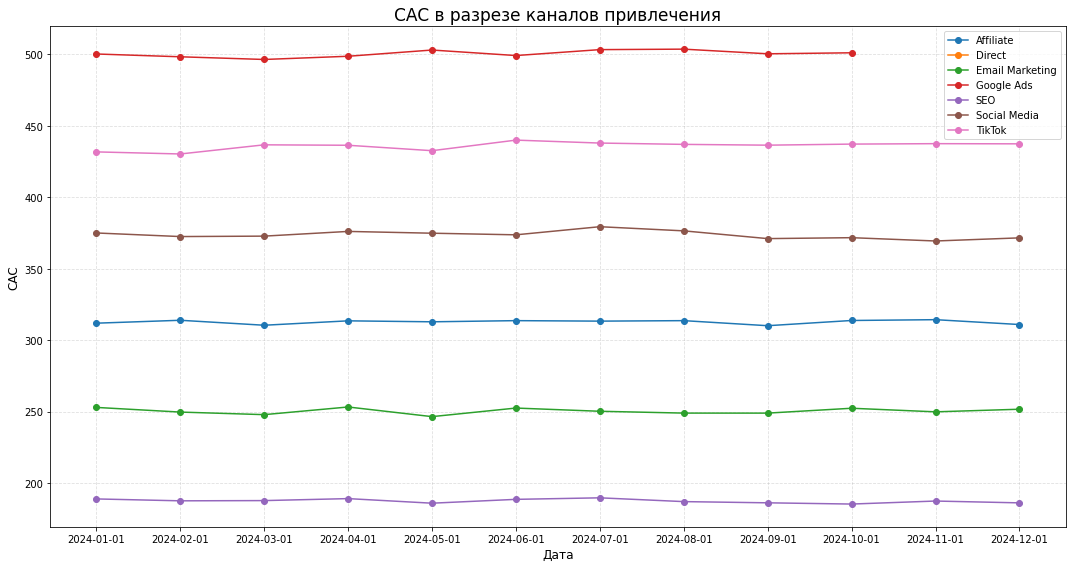

In [42]:
campaign_costs = pd.merge(campaign_costs, channels_dates, on=['cohort_month', 'acq_channel'], how='left')
campaign_costs ['cac_channel'] = campaign_costs['budget'] / campaign_costs['user_id'] 

plt.figure(figsize=(15,8))

for channel in campaign_costs['acq_channel'].unique():
    data_plot = campaign_costs[campaign_costs['acq_channel']==channel]
    plt.plot(data_plot['cohort_month'], data_plot['cac_channel'], marker='o', label=channel)
    
plt.xlabel('Дата', fontsize=12)
plt.ylabel('CAC', fontsize=12)
plt.title('CAC в разрезе каналов привлечения', fontsize=17)
plt.xticks()
plt.legend(campaign_costs['acq_channel'].unique())
plt.grid( linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Количество пользователей по каналам привлечения:
- Абсолютный лидер - TikTok (19228 пользователей). Это более чем в 2 раза превышает следующий по объёму канал (Google Ads) и формирует свыше 40% всей привлечённой аудитории и создаёт зависимость от одной платформы. Поэтому любые риски (например, изменения алгоритмов) напрямую влияют на общий объём привлечения. С июня по декабрь линия TikTok демонстрирует устойчивый и сильный рост: с 750 пользователей в июне до 3500 в декабре.
- Google Ads - второй по объёму канал (9319 пользователей). В феврале–мае канал стабильно даёт более 1000 пользователей, в июне  резкое падение до 950, а к октябрю- до 200. К декабрю канал практически выключен по объёму.
- Affiliate - 6069 пользователей. В динамике линия колеблется в диапазоне 400–600 пользователей, без резких скачков, затем постепенное снижение до 450 к декабрю.
- Social Media - 4179 пользователей. В начале года 350–400 пользователей, в июне–июле рост до 450, затем снижение до 250 к декабрю.
- SEO - 3312 пользователей. Даёт умеренный объём трафика, характерный для органического канала с накопительным эффектом. В динамике численность держится в диапазоне 250–350 пользователей.
- Email Marketing - наименьший объём (2044 пользователя). Это может быть связано с ограниченным размером базы, частотой рассылок. На протяжении всего анализируемого периода 150–250 пользователей в месяц.

Резкое падение Google Ads во второй половине года и одновременный взрывной рост TikTok указывают на перераспределение бюджета и/или изменение стратегии привлечения.

Одновременно TikTok - главный драйвер роста расходов во второй половине года. Линия демонстрирует рост с июня (300 тыс. рублей) в июне до пика (1,5 млн рублей) в декабре.<br>
Google Ads - резкое снижение расходов. Красная линия держится на уровне 0,5–0,6 млн рублей до июля, затем падает: к октябрю - до 0,1 млн рублей, а в декабре имеет нулевой показатель. Это указывает на сворачивание активности в этом канале.<br>
Рост расходов на TikTok практически точно совпадает по времени со снижением Google Ads: с июля по октябрь бюджет «перетекает» из одного канала в другой.<br>
Affiliate, Social Media - умеренная стабильность. Линии (голубая, коричневая) колеблются в диапазоне 0,1–0,2 млн рублей без выраженных трендов.<br>
Email Marketing, SEO, Direct - самые низкобюджетные каналы, держатся в диапазоне 0,03–0,07 млн рублей, без значимых изменений. Это говорит о минимальном финансировании этих направлений.<br>

CAC в разрезе каналов привлечения
- Google Ads - самый дорогой канал. CAC стабильно держится на уровне 500 рублей на протяжении всего года, без выраженных трендов на снижение или рост.
- TikTok - второй по стоимости канал. CAC колеблется в диапазоне 430–445 рублей.
- Social Media - умеренно дорогой канал. CAC находится на уровне 370–385 рублей.
- Affiliate - средний уровень. CAC держится в диапазоне 310–320 рублей.
- Email Marketing - относительно дешёвый канал. CAC в диапазоне 245–255 рублей.
- SEO - самый дешёвый канал. CAC на уровне 185–190 рублей.
- Direct - единственный канал, с помощью которого не было привлечено ни одного пользователя.

Google Ads и TikTok формируют основную нагрузку на бюджет: при CAC 500 и 440 рублей соответственно, окупаемость этих каналов напрямую зависит от LTV и конверсии пользователей. SEO и Email Marketing - наиболее экономичные каналы.<br>
Отсутствие резких скачков по большинству каналов говорит о предсказуемости расходов. Даже небольшое снижение CAC в дорогих каналах (например, на 5–10%) может дать существенную экономию бюджета за счёт масштаба.

**Посмотрим на пользователей, которые совершили заказ, в разбивке по каналам привлечения**

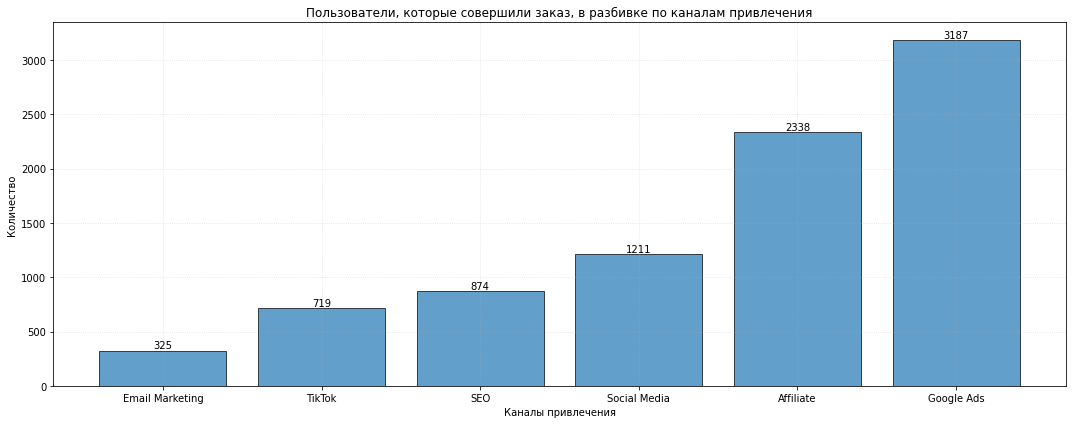

In [43]:
acq_channels_orders = pd.merge(pa_marketplace_users[['user_id', 'acq_channel']], 
                               pa_marketplace_orders[['user_id']], 
                               on='user_id')
acq_channels_orders_groups = acq_channels_orders.groupby('acq_channel')['user_id'].nunique().reset_index().sort_values(by='user_id')

plt.figure(figsize=(15,6))
bars = plt.bar (acq_channels_orders_groups['acq_channel'], acq_channels_orders_groups['user_id'],edgecolor='black', alpha=0.7)
plt.title('Пользователи, которые совершили заказ, в разбивке по каналам привлечения')
plt.xlabel('Каналы привлечения')
plt.ylabel('Количество')
for bar in bars.patches:
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width()/2,
                height + 0.1, 
                f'{height:.0f}',
                ha='center',
                va='bottom',
                fontsize=10,
                color='black')
plt.tight_layout()
plt.grid(linestyle=':', alpha=0.4)
plt.show()

Email Marketing - 325 пользователей. Самый слабый канал в этой выборке.<br>
TikTok- 719 пользователей. Более чем в 2 раза эффективнее email‑рассылок.<br>
SEO - 874 пользователя.<br>
Social Media - 1211 пользователей.<br>
Affiliate - 2338 пользователей. Почти вдвое сильнее Social Media.<br>
Google Ads - 3187 пользователей. Лидер по количеству привлеченных платящих пользователей

Особенности:
- Доминирование платных каналов Google Ads и Affiliate
- Слабость email‑маркетинга. Стоит проверить качество базы, частоту рассылок, релевантность предложений и кликабельность писем.
- Лидер Google Ads даёт львиную долю всех заказов. Это делает канал важным для выручки.

**Проанализируем пользователей в разрезе устройств**

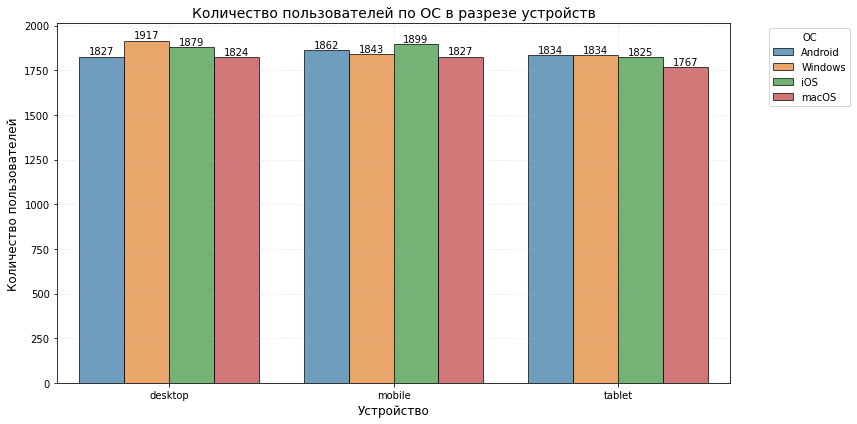

In [44]:
os_device = pa_marketplace_events.groupby(['device','os'])['user_id'].nunique().reset_index()
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=os_device, x='device', y='user_id', hue='os', ax=ax, edgecolor='black', alpha=0.7)

for container in ax.containers:
    # Проходимся по каждому столбцу внутри контейнера
    for bar in container:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, 
                height, 
                f'{int(height)}', 
                ha='center', 
                va='bottom', 
                fontsize=10,
                color='black')

ax.set_title('Количество пользователей по ОС в разрезе устройств', fontsize=14)
ax.set_xlabel('Устройство', fontsize=12)
ax.set_ylabel('Количество пользователей', fontsize=12)

ax.legend(title='ОС', bbox_to_anchor=(1.05, 1), loc='best')
plt.grid(linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

In [45]:
os_device

,device,os,user_id
0,desktop,Android,1827
1,desktop,Windows,1917
2,desktop,iOS,1879
3,desktop,macOS,1824
4,mobile,Android,1862
5,mobile,Windows,1843
6,mobile,iOS,1899
7,mobile,macOS,1827
8,tablet,Android,1834
9,tablet,Windows,1834


Основные особенности
1) Desktop. Лидирует Windows (1917 пользователей), затем macOS (1824) и Android (1827), замыкает iOS (1879). <br>
2) Mobile. Лидер - iOS (1899 пользователей), далее Android (1862), Windows (1843) и macOS (1827).<br>
3) Tablet. Лидеры - Android (1834) и Windows (1834), затем iOS (1825) и macOS (1767). Равенство Android и Windows на планшетах выглядит аномально: обычно планшеты работают на Android или iOS, а Windows встречается редко и в нишевых сегментах.

**Построим воронку событий основных шагов от просмотра страницы до завершения оформления заказа**

In [46]:
# Создадим функцию для расчета воронок
steps = ['page_view', 'product_view', 'add_to_cart', 'checkout_start', 'checkout_complete']
def funnels(data):
    data = data.groupby('event_type')['user_id'].nunique().reindex(steps).reset_index()
    data['conversion'] = (data['user_id'] / data['user_id'].iloc[0] * 100).round(1)
    data['conversion_from_previous_%'] = (data['user_id'] / data['user_id'].shift(1) * 100).round(1)
    return data

In [47]:
funnel_events = pa_marketplace_events[pa_marketplace_events['event_type'].isin(steps)]
funnel_events = funnels(funnel_events)

In [48]:
funnel_events2 = funnel_events.T
funnel_events2['5']=['order', 
                     pa_marketplace_orders['user_id'].nunique(), 
                     0,0]

funnel_events2['6']=['registration', 
                     pa_marketplace_users['user_id'].nunique(), 
                     0,0]

funnel_events2 = funnel_events2.iloc[:, [6, 0, 1, 2, 3, 4, 5]]
funnel_events2 = funnel_events2.T
funnel_events2['conversion'] = funnel_events2['user_id'] / funnel_events2['user_id'].iloc[0] * 100
funnel_events2['conversion_from_previous_%'] = funnel_events2['user_id'] / funnel_events2['user_id'].shift(1) * 100
funnel_events2

,event_type,user_id,conversion,conversion_from_previous_%
6,registration,44151,100.0,NaN
0,page_view,22098,50.050961,50.050961
1,product_view,22069,49.985278,99.868766
2,add_to_cart,20411,46.229983,92.487199
3,checkout_start,16769,37.98102,82.15668
4,checkout_complete,13897,31.476071,82.873159
5,order,8922,20.207923,64.200907


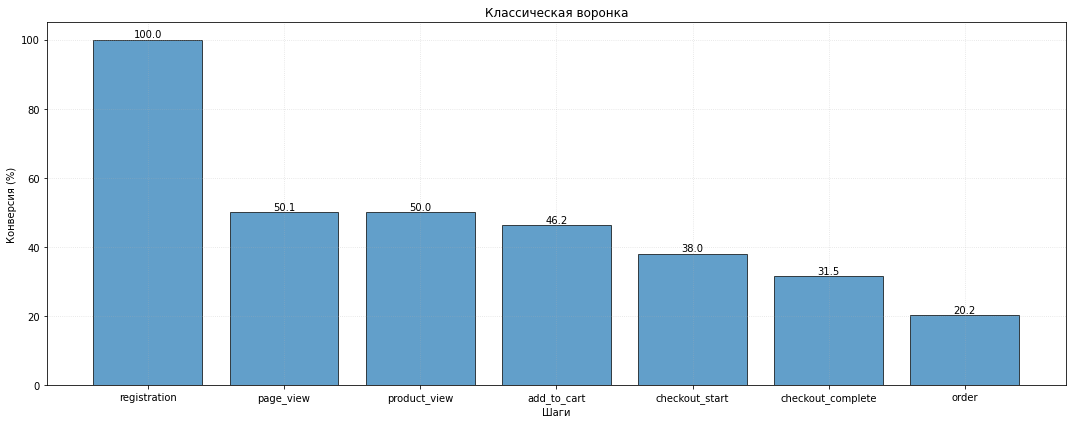

In [49]:
# Визуализируем классическую воронку

plt.figure(figsize=(15,6))
bars = plt.bar (funnel_events2['event_type'], funnel_events2['conversion'], edgecolor='black', alpha=0.7)
plt.title('Классическая воронка')
plt.xlabel('Шаги')
plt.ylabel('Конверсия (%)')
for bar in bars.patches:
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width()/2,
                height + 0.1, 
                f'{height:.1f}',
                ha='center',
                va='bottom',
                fontsize=10,
                color='black')
plt.tight_layout()
plt.grid(linestyle=':', alpha=0.4)
plt.show()

1) Самое резкое падение - между регистрацией и просмотром страниц со 100% до 50%. Это может говорить о том, что значительная часть зарегистрировавшихся пользователей либо не находит интересного контента, либо сталкивается с барьерами (сложная навигация, медленная загрузка, отсутствие релевантных рекомендаций). Вероятно, процесс регистрации обременителен (много полей, обязательная верификация по SMS и т.п.) и есть ли альтернатива в виде входа через соцсети/аккаунт Google/Apple.<br>
2) Практически нулевая потеря между page_view и product_view. Аномально низкий отток: пользователи, дошедшие до просмотра страниц, смотрят товары. Возможно, на этом этапе работает эффективная рекомендательная система или каталог устроен так, что переход к товарам - естественный следующий шаг.<br>
3) Падение с 46% до 38% (add_to_cart - checkout_start) может указывать на то, что пользователи кладут товары в корзину, но не переходят к покупке. Возможно, стоит внедрить напоминания (email, пуш-уведомления) и упрощённый чекаут для «брошенных корзин».<br>
4) Провалы на этапе оформления заказа. Особенно критичны два участка:
- checkout_start - checkout_complete: 31%
- checkout_complete - order: 20%<br>
Возможно, есть проблемы с оплатой, неожиданные расходы, сложный процесс ввода данных, отсутствие нужных способов оплаты.

posx and posy should be finite values
posx and posy should be finite values


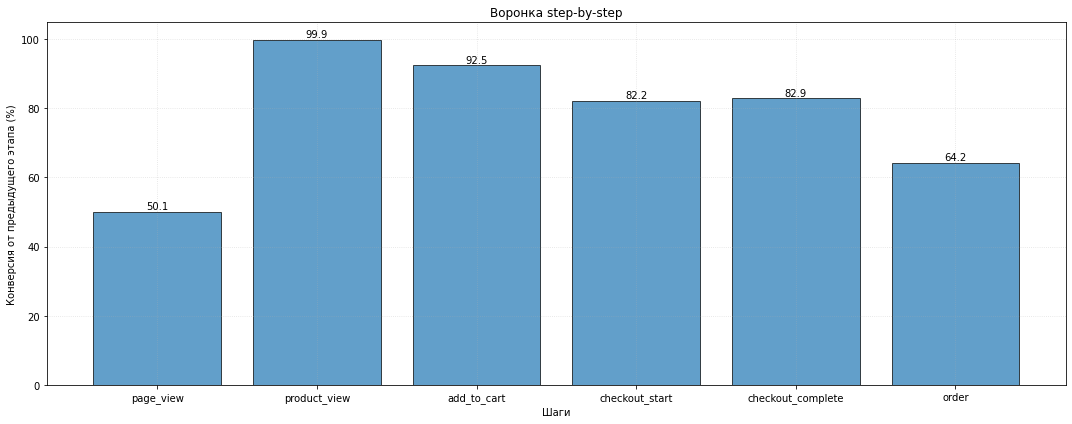

In [50]:
# Визуализируем воронку step-by-step 

plt.figure(figsize=(15,6))
bars = plt.bar (funnel_events2['event_type'], funnel_events2['conversion_from_previous_%'],edgecolor='black', alpha=0.7)
plt.title('Воронка step-by-step')
plt.xlabel('Шаги')
plt.ylabel('Конверсия от предыдущего этапа (%)')
for bar in bars.patches:
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width()/2,
                height + 0.1, 
                f'{height:.1f}',
                ha='center',
                va='bottom',
                fontsize=10,
                color='black')
plt.tight_layout()
plt.grid(linestyle=':', alpha=0.4)
plt.show()

Ключевые особенности
- Главная проблема - переход от просмотра страницы к просмотру товара (50%). Половина трафика теряется ещё до знакомства с продуктом. Возможные причины: нерелевантные карточки, плохая навигация, медленная загрузка, отсутствие фильтров или сортировки.
- Высокая вовлечённость после просмотра товара (99,9%).
- Небольшие потери на чекауте (82% и 83%)
- Финальное падение до 64,2% Это может быть связано с проблемами с оплатой или сложностью финального подтверждения.

**Рассчитаем воронки по устройствам из просмотра страницы в заказ**

In [51]:
device_orders = pd.merge(pa_marketplace_events[['user_id', 'device']], 
                         pa_marketplace_orders, 
                         on='user_id')
device_orders_group = device_orders.groupby('device')['user_id'].nunique().reset_index()
device_orders_group

,device,user_id
0,desktop,2428
1,mobile,2493
2,tablet,2377


In [52]:
# Мобильная версия
funnel_events_m = pa_marketplace_events[pa_marketplace_events['event_type'].isin(steps)]
funnel_events_m = funnel_events_m[funnel_events_m['device']=='mobile']
funnel_events_m = funnels(funnel_events_m)

funnel_events_m2 = funnel_events_m.T
funnel_events_m2['5']=['order', 
                     device_orders_group.iloc[1,1], 
                     0,0]

funnel_events_m2 = funnel_events_m2.T
funnel_events_m2['conversion'] = funnel_events_m2['user_id'] / funnel_events_m2['user_id'].iloc[0] * 100
funnel_events_m2['conversion_from_previous_%'] = funnel_events_m2['user_id'] / funnel_events_m2['user_id'].shift(1) * 100
funnel_events_m2

,event_type,user_id,conversion,conversion_from_previous_%
0,page_view,7423,100.0,NaN
1,product_view,7413,99.865284,99.865284
2,add_to_cart,6848,92.253806,92.378254
3,checkout_start,5572,75.06399,81.366822
4,checkout_complete,4607,62.063856,82.681263
5,order,2493,33.584804,54.113306


In [53]:
# Десктопная версия
funnel_events_d = pa_marketplace_events[pa_marketplace_events['event_type'].isin(steps)]
funnel_events_d = funnel_events_d[funnel_events_d['device']=='desktop']
funnel_events_d = funnels(funnel_events_d)

funnel_events_d2 = funnel_events_d.T
funnel_events_d2['5']=['order', 
                     device_orders_group.iloc[0,1], 
                     0,0]

funnel_events_d2 = funnel_events_d2.T
funnel_events_d2['conversion'] = funnel_events_d2['user_id'] / funnel_events_d2['user_id'].iloc[0] * 100
funnel_events_d2['conversion_from_previous_%'] = funnel_events_d2['user_id'] / funnel_events_d2['user_id'].shift(1) * 100
funnel_events_d2

,event_type,user_id,conversion,conversion_from_previous_%
0,page_view,7431,100.0,NaN
1,product_view,7419,99.838514,99.838514
2,add_to_cart,6858,92.289059,92.438334
3,checkout_start,5697,76.665321,83.070866
4,checkout_complete,4766,64.136725,83.658066
5,order,2428,32.673934,50.944188


In [54]:
# Планшеты
funnel_events_t = pa_marketplace_events[pa_marketplace_events['event_type'].isin(steps)]
funnel_events_t = funnel_events_t[funnel_events_t['device']=='tablet']
funnel_events_t = funnels(funnel_events_t)

funnel_events_t2 = funnel_events_t.T
funnel_events_t2['5']=['order', 
                     device_orders_group.iloc[2,1], 
                     0,0]

funnel_events_t2 = funnel_events_t2.T
funnel_events_t2['conversion'] = funnel_events_t2['user_id'] / funnel_events_t2['user_id'].iloc[0] * 100
funnel_events_t2['conversion_from_previous_%'] = funnel_events_t2['user_id'] / funnel_events_t2['user_id'].shift(1) * 100
funnel_events_t2

,event_type,user_id,conversion,conversion_from_previous_%
0,page_view,7244,100.0,NaN
1,product_view,7237,99.903368,99.903368
2,add_to_cart,6705,92.559359,92.648888
3,checkout_start,5500,75.924903,82.028337
4,checkout_complete,4524,62.451684,82.254545
5,order,2377,32.813363,52.541998


In [55]:
# Объединим данные
funnel_events_m2 = funnel_events_m2.rename(columns={'user_id': 'count_users_mobile', 
                                         'conversion':'conversion_mobile', 
                                         'conversion_from_previous_%': 'conversion_from_previous_%_mobile'})

funnel_events_d2 = funnel_events_d2.rename(columns={'user_id': 'count_users_desktop', 
                                         'conversion':'conversion_desktop', 
                                         'conversion_from_previous_%': 'conversion_from_previous_%_desktop'})

funnel_events_t2 = funnel_events_t2.rename(columns={'user_id': 'count_users_tablet', 
                                         'conversion':'conversion_tablet', 
                                         'conversion_from_previous_%': 'conversion_from_previous_%_tablet'})

funnel_events_devices = pd.concat([funnel_events_m2.T, funnel_events_d2.T, funnel_events_t2.T])
funnel_events_devices

,0,1,2,3,4,5
event_type,page_view,product_view,add_to_cart,checkout_start,checkout_complete,order
count_users_mobile,7423,7413,6848,5572,4607,2493
conversion_mobile,100.0,99.865284,92.253806,75.06399,62.063856,33.584804
conversion_from_previous_%_mobile,NaN,99.865284,92.378254,81.366822,82.681263,54.113306
event_type,page_view,product_view,add_to_cart,checkout_start,checkout_complete,order
count_users_desktop,7431,7419,6858,5697,4766,2428
conversion_desktop,100.0,99.838514,92.289059,76.665321,64.136725,32.673934
conversion_from_previous_%_desktop,NaN,99.838514,92.438334,83.070866,83.658066,50.944188
event_type,page_view,product_view,add_to_cart,checkout_start,checkout_complete,order
count_users_tablet,7244,7237,6705,5500,4524,2377


Сравним воронки по устройствам
1. Переход от `page_view` к `product_view` практически идентичен на всех устройствах: более 99%. Проблем на этом этапе нет.
2. Переход от `product_view` к `add_to_cart` выше 92%. Этап добавления в корзину отрабатывает одинаково хорошо на всех устройствах.
3. Переход от `add_to_cart` к `checkout_start`. На мобильных устройствах (81%) пользователи чаще отказываются от начала оформления заказа. 
4. Переход от `checkout_start` к `checkout_complete` (заполнение данных). На этом этапе mobile снова чуть отстаёт (83%). Вероятно, пользователи, которые всё-таки начали оформление на мобильном, чаще его завершают.
5. Переход от `checkout_complete` к `order` (финальная оплата). Самый сильный отсев: mobile 54%, desktop 51%, tablet 53%.
Больше половины пользователей, дошедших до финального экрана, не завершают покупку. При этом на мобильных устройствах конверсия здесь даже чуть выше, чем на desktop. Это может указывать на более высокую готовность к покупке у мобильной аудитории, которая дошла до оплаты, либо на более удобные платёжные методы на мобильных устройствах.
6. Итоговые конверсии в заказ (от `page_view`): mobile: 34%, desktop: 33%, tablet: 33%.
Мобильные устройства показывают самую высокую итоговую конверсию, несмотря на более низкие промежуточные показатели на этапе начала оформления.

**Рассчитаем воронки по ОС**

In [56]:
os_orders = pd.merge(pa_marketplace_events[['user_id', 'os']], 
                         pa_marketplace_orders, 
                         on='user_id')
os_orders_group = os_orders.groupby('os')['user_id'].nunique().reset_index()
os_orders_group

,os,user_id
0,Android,1845
1,Windows,1837
2,iOS,1816
3,macOS,1800


In [57]:
# iOS
funnel_events_ios = pa_marketplace_events[pa_marketplace_events['event_type'].isin(steps)]
funnel_events_ios = funnel_events_ios[funnel_events_ios['os']=='iOS']
funnel_events_ios = funnels(funnel_events_ios)

funnel_events_ios2 = funnel_events_ios.T
funnel_events_ios2['5']=['order', 
                     os_orders_group.iloc[2,1], 
                     0,0]

funnel_events_ios2 = funnel_events_ios2.T
funnel_events_ios2['conversion'] = funnel_events_ios2['user_id'] / funnel_events_ios2['user_id'].iloc[0] * 100
funnel_events_ios2['conversion_from_previous_%'] = funnel_events_ios2['user_id'] / funnel_events_ios2['user_id'].shift(1) * 100
funnel_events_ios2

,event_type,user_id,conversion,conversion_from_previous_%
0,page_view,5592,100.0,NaN
1,product_view,5589,99.946352,99.946352
2,add_to_cart,5157,92.22103,92.270531
3,checkout_start,4244,75.894134,82.295908
4,checkout_complete,3496,62.517883,82.375118
5,order,1816,32.474964,51.94508


In [58]:
# Android
funnel_events_Android = pa_marketplace_events[pa_marketplace_events['event_type'].isin(steps)]
funnel_events_Android = funnel_events_Android[funnel_events_Android['os']=='Android']
funnel_events_Android = funnels(funnel_events_Android)

funnel_events_Android2 = funnel_events_Android.T
funnel_events_Android2['5']=['order', 
                     os_orders_group.iloc[0,1], 
                     0,0]

funnel_events_Android2 = funnel_events_Android2.T
funnel_events_Android2['conversion'] = funnel_events_Android2['user_id'] / funnel_events_Android2['user_id'].iloc[0] * 100
funnel_events_Android2['conversion_from_previous_%'] = funnel_events_Android2['user_id'] / funnel_events_Android2['user_id'].shift(1) * 100
funnel_events_Android2

,event_type,user_id,conversion,conversion_from_previous_%
0,page_view,5514,100.0,NaN
1,product_view,5502,99.782372,99.782372
2,add_to_cart,5108,92.636924,92.838968
3,checkout_start,4199,76.151614,82.204385
4,checkout_complete,3513,63.710555,83.662777
5,order,1845,33.460283,52.519214


In [59]:
# Windows
funnel_events_win = pa_marketplace_events[pa_marketplace_events['event_type'].isin(steps)]
funnel_events_win = funnel_events_win[funnel_events_win['os']=='Windows']
funnel_events_win = funnels(funnel_events_win)

funnel_events_win2 = funnel_events_win.T
funnel_events_win2['5']=['order', 
                     os_orders_group.iloc[1,1], 
                     0,0]

funnel_events_win2 = funnel_events_win2.T
funnel_events_win2['conversion'] = funnel_events_win2['user_id'] / funnel_events_win2['user_id'].iloc[0] * 100
funnel_events_win2['conversion_from_previous_%'] = funnel_events_win2['user_id'] / funnel_events_win2['user_id'].shift(1) * 100
funnel_events_win2

,event_type,user_id,conversion,conversion_from_previous_%
0,page_view,5581,100.0,NaN
1,product_view,5575,99.892492,99.892492
2,add_to_cart,5157,92.402795,92.502242
3,checkout_start,4243,76.025802,82.276517
4,checkout_complete,3489,62.515678,82.229555
5,order,1837,32.915248,52.651189


In [60]:
# macOS
funnel_events_mac = pa_marketplace_events[pa_marketplace_events['event_type'].isin(steps)]
funnel_events_mac = funnel_events_mac[funnel_events_mac['os']=='macOS']
funnel_events_mac = funnels(funnel_events_mac)

funnel_events_mac2 = funnel_events_mac.T
funnel_events_mac2['5']=['order', 
                     os_orders_group.iloc[3,1], 
                     0,0]

funnel_events_mac2 = funnel_events_mac2.T
funnel_events_mac2['conversion'] = funnel_events_mac2['user_id'] / funnel_events_mac2['user_id'].iloc[0] * 100
funnel_events_mac2['conversion_from_previous_%'] = funnel_events_mac2['user_id'] / funnel_events_mac2['user_id'].shift(1) * 100
funnel_events_mac2

,event_type,user_id,conversion,conversion_from_previous_%
0,page_view,5411,100.0,NaN
1,product_view,5403,99.852153,99.852153
2,add_to_cart,4989,92.201072,92.33759
3,checkout_start,4083,75.457402,81.840048
4,checkout_complete,3399,62.816485,83.247612
5,order,1800,33.26557,52.956752


In [61]:
# Объединим данные
funnel_events_ios2 = funnel_events_ios2.rename(columns={'user_id': 'count_users_ios', 
                                         'conversion':'conversion_ios', 
                                         'conversion_from_previous_%': 'conversion_from_previous_%_ios'})

funnel_events_Android2 = funnel_events_Android2.rename(columns={'user_id': 'count_users_Android', 
                                         'conversion':'conversion_Android', 
                                         'conversion_from_previous_%': 'conversion_from_previous_%_Android'})

funnel_events_win2 = funnel_events_win2.rename(columns={'user_id': 'count_users_win', 
                                         'conversion':'conversion_win', 
                                         'conversion_from_previous_%': 'conversion_from_previous_%_win'})

funnel_events_mac2 = funnel_events_mac2.rename(columns={'user_id': 'count_users_mac', 
                                         'conversion':'conversion_mac', 
                                         'conversion_from_previous_%': 'conversion_from_previous_%_mac'})


funnel_events_os = pd.concat([funnel_events_ios2.T, funnel_events_Android2.T, funnel_events_win2.T, funnel_events_mac2.T])
funnel_events_os

,0,1,2,3,4,5
event_type,page_view,product_view,add_to_cart,checkout_start,checkout_complete,order
count_users_ios,5592,5589,5157,4244,3496,1816
conversion_ios,100.0,99.946352,92.22103,75.894134,62.517883,32.474964
conversion_from_previous_%_ios,NaN,99.946352,92.270531,82.295908,82.375118,51.94508
event_type,page_view,product_view,add_to_cart,checkout_start,checkout_complete,order
count_users_Android,5514,5502,5108,4199,3513,1845
conversion_Android,100.0,99.782372,92.636924,76.151614,63.710555,33.460283
conversion_from_previous_%_Android,NaN,99.782372,92.838968,82.204385,83.662777,52.519214
event_type,page_view,product_view,add_to_cart,checkout_start,checkout_complete,order
count_users_win,5581,5575,5157,4243,3489,1837


Проанализируем показатели<br>
Итоговая конверсия в заказ (от page_view): iOS 33%, Android 34%, Windows 33%, macOS 33%. Почти идентична по всем ОС.

1. Page view - Product view. Конверсия здесь стабильно высокая 99% на всех ОС. Проблем на этом этапе нет.
2. Product view - Add to cart. Этап добавления в корзину отрабатывает также одинаково хорошо. 
3. Add to cart - Checkout start. macOS демонстрирует самое сильное падение. 
4. Checkout start - Checkout complete. Android и macOS показывают более высокую конверсию на этом этапе, чем iOS и Windows. 
5. Checkout complete - Order (финальная оплата). Самый сильный отсев: больше половины пользователей, дошедших до финального экрана, не завершают покупку. При этом macOS показывает самую высокую конверсию на этом этапе (на 1 п.п. выше iOS). Это может говорить о более высокой готовности к покупке у пользователей Mac, которые дошли до оплаты, либо о более удобных платёжных методах на этой ОС.

**Рассмотрим категории товаров**

In [62]:
categories = pa_marketplace_orders.groupby('category_name').agg(order_count=('order_id', 'count'),
                                                                order_sum=('total_price', 'sum'),
                                                                user_count=('user_id', 'nunique')
                                                               ).reset_index().sort_values(by='order_count', ascending=False)
categories.index = range(1, len(categories) + 1)
categories

,category_name,order_count,order_sum,user_count
1,Продукты питания,4027,11928953.88,2659
2,Детская одежда,1421,6426106.06,942
3,Зоотовары,1396,7451679.28,888
4,Книги и канцтовары,1316,4088868.74,739
5,Аксессуары для гаджетов,1255,13869405.42,726
6,Обувь мужская,1253,18849633.69,730
7,Одежда для спорта,1248,10718016.62,726
8,Товары для кухни,1237,20608036.11,637
9,Обувь женская,1211,17209783.72,757
10,Женская одежда,1191,13746700.97,646


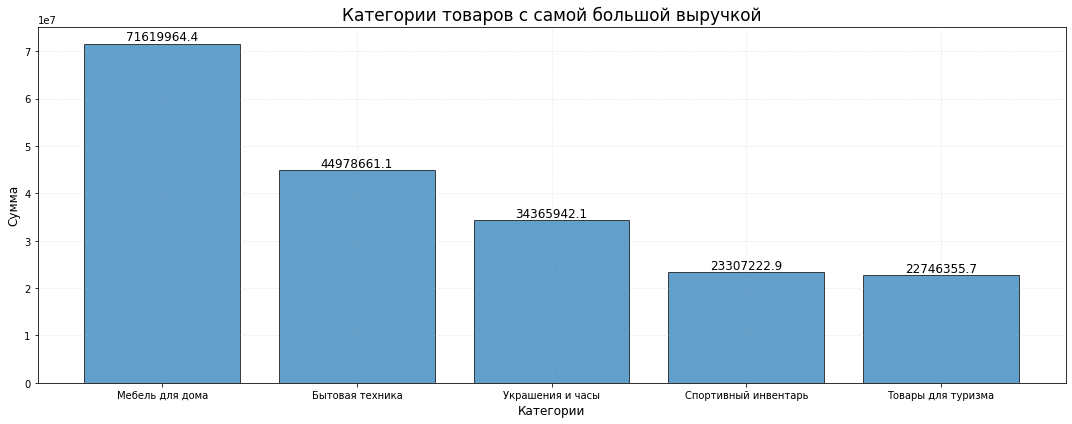

In [63]:
order_sum = categories.sort_values(by='order_sum', ascending=False).head(5)
plt.figure(figsize=(15,6))
bars = plt.bar (order_sum['category_name'], order_sum['order_sum'],edgecolor='black', alpha=0.7)
plt.title('Категории товаров с самой большой выручкой', fontsize=17)
plt.xlabel('Категории', fontsize=12)
plt.ylabel('Сумма', fontsize=12)
for bar in bars.patches:
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width()/2,
                height + 0.1, 
                f'{round(height, 1)}',
                ha='center',
                va='bottom',
                fontsize=12,
                color='black',
                fontweight=500)
plt.tight_layout()
plt.grid(linestyle=':', alpha=0.4)
plt.show()

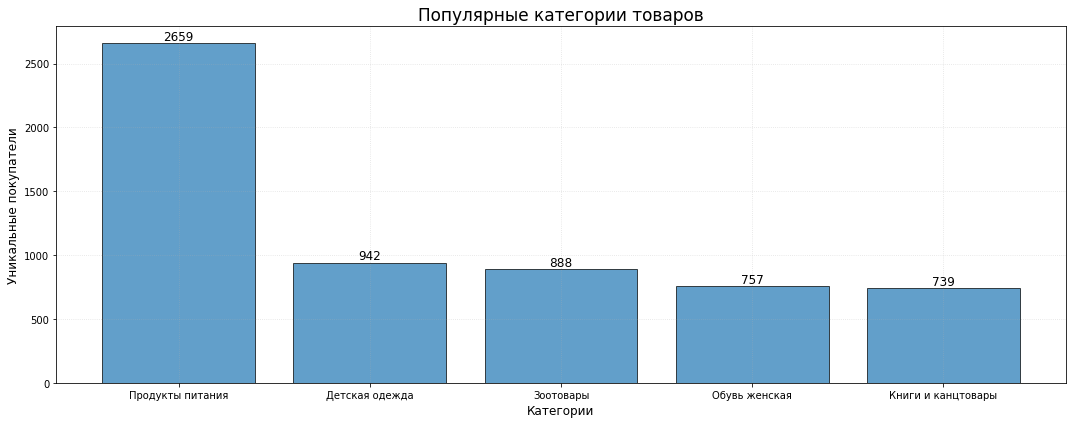

In [64]:
user_count = categories.sort_values(by='user_count', ascending=False).head(5)
plt.figure(figsize=(15,6))
bars = plt.bar (user_count['category_name'], user_count['user_count'],edgecolor='black', alpha=0.7)
plt.title('Популярные категории товаров', fontsize=17)
plt.xlabel('Категории', fontsize=12)
plt.ylabel('Уникальные покупатели', fontsize=12)
for bar in bars.patches:
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width()/2,
                height + 0.1, 
                f'{round(height, 1)}',
                ha='center',
                va='bottom',
                fontsize=12,
                color='black',
                fontweight=500)
plt.tight_layout()
plt.grid(linestyle=':', alpha=0.4)
plt.show()

*Анализ размера выручки* <br>
- Мебель для дома - абсолютный лидер по выручке. Сумма составляет 71 619 964 рубля. Такая высокая выручка может объясняться высокой средней стоимостью единицы товара и/или большим объёмом продаж.<br>
- Бытовая техника - вторая по выручке категория - 44 978 661 рубль, уступает Мебели для дома, но опережает остальные категории.<br>
- Украшения и часы - третья по выручке категория - 34 365 942 рубля.<br>
Спортивный инвентарь и Товары для туризма - близкие по выручке категории. Выручка составляет 23 307 223 рубля и 22 746 356 рублей соответственно.

На «Мебель для дома» и «Бытовую технику» приходится более 65% общей выручки по этим пяти категориям. Это создаёт зависимость финансовых результатов от успешности именно этих направлений. Схожие показатели «Спортивного инвентаря» и «Товаров для туризма» - признак смежных рынков. Эти категории могут иметь пересекающуюся аудиторию и схожие сезонные тренды, что позволяет объединять их в промо‑кампаниях.

*Популярные категории товаров*
- Продукты питания - абсолютный лидер по охвату аудитории. Категория привлекает 2659 уникальных покупателей, что в 2,8 раза больше, чем у Детской одежды (942). Такой разрыв типичен для товаров повседневного спроса.
- Детская одежда и Зоотовары - близкие по популярности категории - 942 и 888 покупателей.
- Обувь женская и Книги и канцтовары - менее востребованные категории. 757 и 739 покупателей - показатели похожи, уступают лидерам.

После Продуктов питания все остальные категории находятся в диапазоне 739–942 покупателей - то есть разрыв между лидером и остальными составляет более 1700 покупателей. Эта категория - основной драйвер трафика. Если Продукты питания обеспечивают основную часть трафика, любые проблемы в этой категории (дефицит, рост цен, снижение качества) могут существенно повлиять на общие показатели магазина.

**Посмотрим на количество заказов**

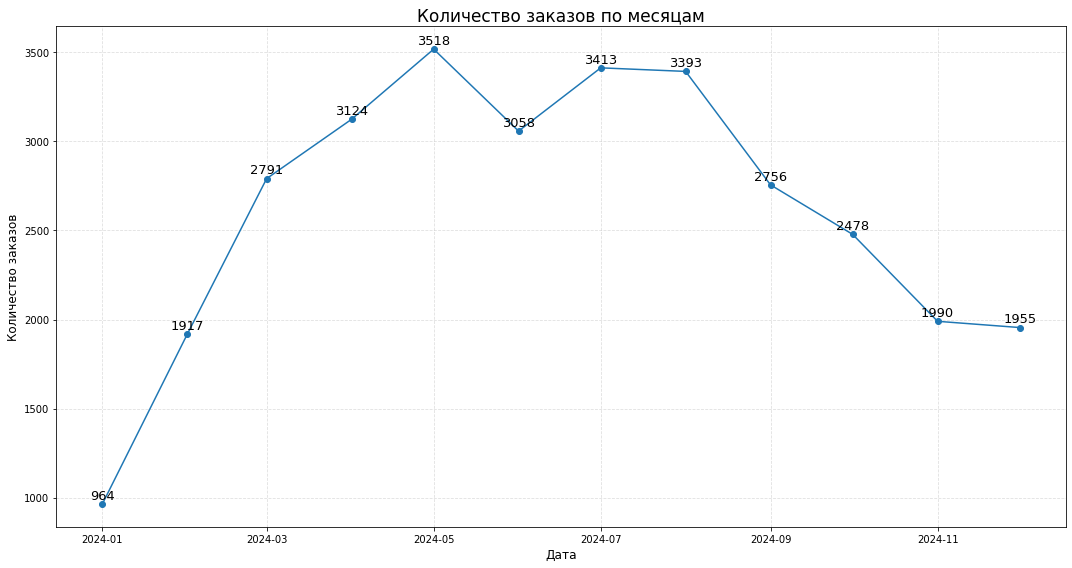

In [65]:
orders_dates = pa_marketplace_orders.groupby('order_month')['order_id'].count().reset_index()
plt.figure(figsize=(15,8))

plt.plot(orders_dates['order_month'], orders_dates['order_id'], marker='o')
    
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Количество заказов', fontsize=12)
plt.title('Количество заказов по месяцам', fontsize=17)
for x, y in zip(orders_dates['order_month'], orders_dates['order_id']):
    plt.annotate(
        f'{y:.0f}',  
        xy=(x, y),
        xytext=(0, 5), 
        textcoords='offset points',
        ha='center',
        fontsize=13,
        color='black',
        fontweight=500
    )
plt.xticks()
plt.grid( linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

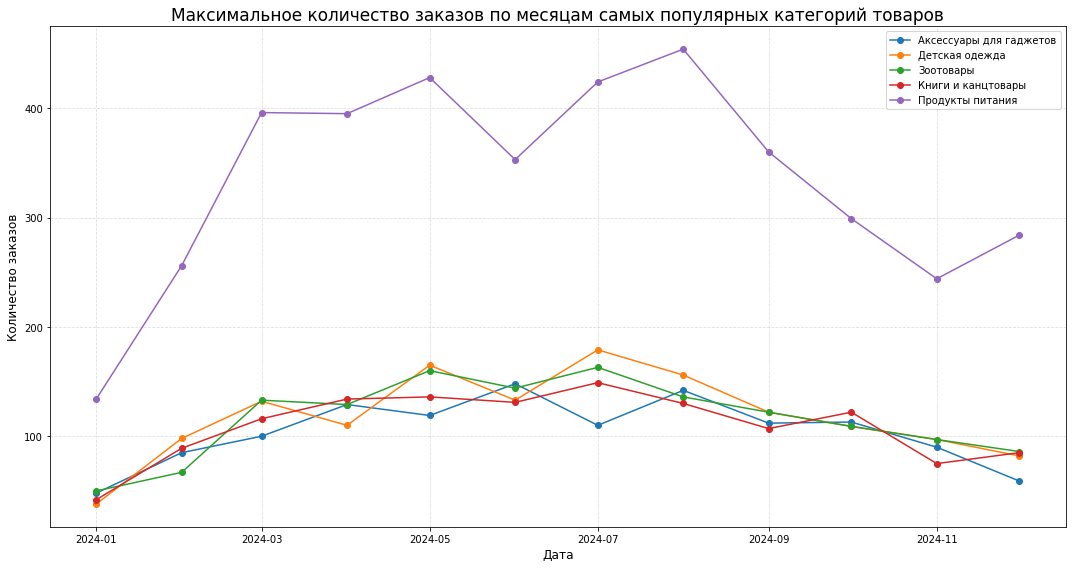

In [66]:
categories_orders = pa_marketplace_orders[pa_marketplace_orders['category_name'].isin(['Продукты питания', 
                                                                                       'Детская одежда', 
                                                                                       'Зоотовары', 
                                                                                       'Книги и канцтовары', 
                                                                                       'Аксессуары для гаджетов'])]

categories_orders_dates = categories_orders.groupby(['order_month','category_name'])['order_id'].count().reset_index()

plt.figure(figsize=(15,8))

for category in categories_orders_dates['category_name'].unique():
    data_plot = categories_orders_dates[categories_orders_dates['category_name']==category]
    plt.plot(data_plot['order_month'], data_plot['order_id'], marker='o', label=category)

plt.xlabel('Дата', fontsize=12)
plt.ylabel('Количество заказов', fontsize=12)
plt.title('Максимальное количество заказов по месяцам самых популярных категорий товаров', fontsize=17)
plt.xticks()
plt.legend(categories_orders_dates['category_name'].unique())
plt.grid( linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Особенности
- Резкий рост в начале года. С января (964 заказа) до мая (3518 заказов) количество заказов выросло в 3,65 раза - это самый резкий рост за весь период.
- Волатильность в середине года. После мая - спад до 3058 заказов в июне, затем снова рост в июле (3413) и августе (3393). Это говорит о наличии сезонных всплесков или разовых факторов (акции, выход новинок, внешние события).
- Снижение с сентября (2756 заказов) по ноябрь (1955).
- Декабрь - минимальное значение с мая (1955).

Резкий рост в первом квартале и пик в мае могут быть связаны с праздничным спросом (8 Марта, предмайские распродажи), запуском промо‑кампании или выходом востребованного товара. Снижение с сентября по ноябрь - тревожный сигнал: возможно, исчерпался эффект от весенних акций, усилилась конкуренция, изменились потребительские предпочтения. Текущая динамика показывает, что разовые всплески не превращаются в устойчивый рост - нужны системные меры для стабилизации и увеличения объёмов.

*Популярность товаров*<br>
Продукты питания - абсолютный лидер по объёму заказов. Фиолетовая линия стабильно находится выше всех остальных: рост со 130 заказов в январе до пика в 450 в августе, затем снижение до 270 в ноябре. Даже минимальное значение в ноябре превышает максимумы остальных категорий.
Остальные категории в схожем диапазоне 50–180 заказов, колеблются в узком коридоре. В марте–июле линии Детская одежда, Зоотовары, Книги и канцтовары и Аксессуары для гаджетов многократно пересекаются, что говорит о схожей динамике спроса и отсутствии устойчивого лидера среди них.

Наблюдается высокая зависимость от категории Продукты питания. На неё приходится подавляющая часть заказов - любые изменения в этой категории будут напрямую влиять на общие показатели маркетплейса.

**Найдем самые популярные товары**

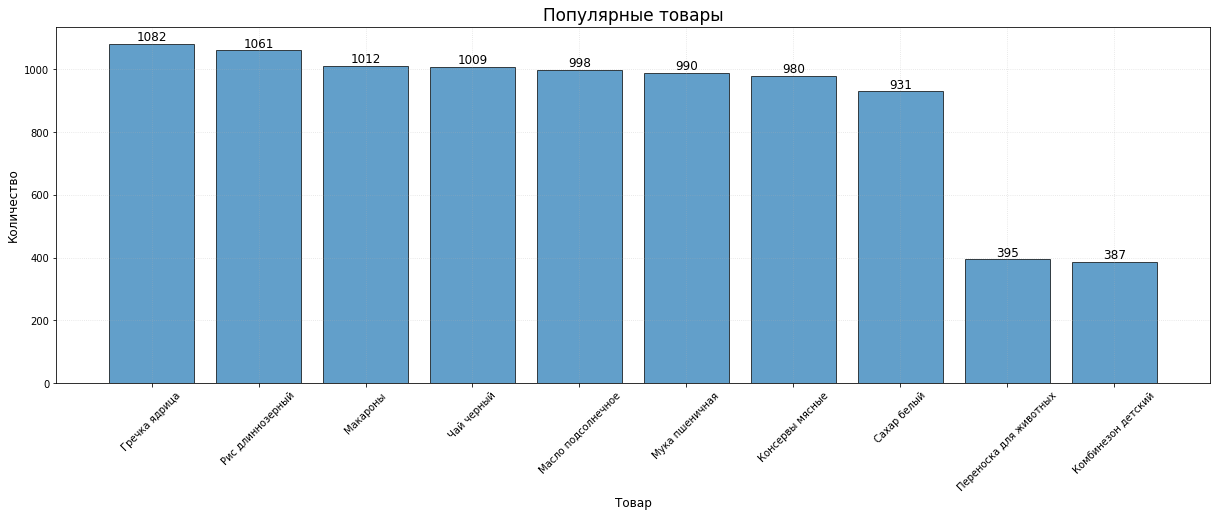

In [67]:
products = pa_marketplace_orders.groupby('product_name')['quantity'].sum().reset_index().sort_values(
    by='quantity', ascending=False).head(10)

plt.figure(figsize=(17,6))
bars = plt.bar (products['product_name'], products['quantity'],edgecolor='black', alpha=0.7)
plt.title('Популярные товары', fontsize=17)
plt.xlabel('Товар', fontsize=12)
plt.ylabel('Количество', fontsize=12)
for bar in bars.patches:
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width()/2,
                height + 0.1, 
                f'{round(height, 1)}',
                ha='center',
                va='bottom',
                fontsize=12,
                color='black',
                fontweight=500)
plt.tight_layout()
plt.xticks(rotation=45)
plt.grid(linestyle=':', alpha=0.4)
plt.show()

Ядро спроса - базовые продукты питания. В топ‑8 входят гречка (1082), рис (1061), макароны (1012), чай черный (1009), масло подсолнечное (998), мука пшеничная (990), консервы мясные (980), сахар (931). Все они демонстрируют близкие объёмы.
Два последних товара Переноска для животных (395) и Комбинезон детский (387) показывают объёмы ниже, чем у товаров из топ‑8.
Разброс между максимумом (1082) и минимумом (931) в топ‑8 небольшой, что говорит о сбалансированности спроса: ни один товар не доминирует настолько, чтобы искажать общую картину. Товары «хвоста» - нишевые или ситуативные, могут относиться к сезонным, целевым или менее востребованным категориям, их объёмы ниже и не конкурируют с базовыми продуктами.

Стабильность спроса на базовые продукты - опора выручки. Поскольку спрос на базовые продукты стабилен и равномерен, можно формировать готовые наборы. Это повысит средний чек без потери конверсии. Товары с низкими объёмами требуют иной стратегии: либо усиление продвижения, либо оптимизация ассортимента.

## Выводы по этапу 3

Представьте ключевые выводы в текстовом виде здесь или приложите ссылку на документ с презентацией.

Не забудьте предоставить доступ на просмотр и комментирование документа.

*Преимущества*<br>
- Гендерное распределение практически равное, а возрастная структура равномерна без резких провалов. Это снижает риски, связанные с демографическими колебаниями.
- Переход от просмотра страницы к просмотру товара стабильно превышает 99% на всех устройствах и ОС — рекомендательная система и навигация работают эффективно.
- Стабильный спрос на базовые товары. Топ‑категории (гречка, рис, макароны) демонстрируют высокий спрос, что позволяет масштабировать продажи через готовые наборы и кросс‑продажи.
- Итоговая конверсия в заказ почти идентична по mobile, desktop, tablet и по всем ОС (32–34%), что говорит об универсальности пользовательского опыта.

*Недостатки*<br>
- Отсев на финальных этапах чекаута. На переходе от `checkout_complete` к `order` теряется более половины пользователей. Это главный источник упущенной выручки.
- Зависимость от одного канала. TikTok формирует свыше 40% всей привлечённой аудитории и является основным драйвером роста расходов. Любые изменения алгоритмов или внешние ограничения напрямую повлияют на объёмы трафика и выручку.
- Падение активности в Google Ads, уъход площадки из России. Канал практически выключен по объёму к декабрю, при этом он был лидером по количеству платящих пользователей (3187 заказов). Это создаёт риск потери значимого сегмента аудитории без гарантированной компенсации за счёт других каналов.
- Аномалии в распределении по устройствам. Равенство Android и Windows на планшетах выглядит нетипично и требует проверки корректности разметки данных.

## 5. Подготовка эксперимента и подведение его результатов

Данные для анализа

```python
pa_diploma_events_AB = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_events_AB.csv')
pa_diploma_orders_AB = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_orders_AB.csv')
pa_diploma_sessions_AB = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_sessions_AB.csv')
pa_diploma_users_AB = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_users_AB.csv')
```

Результаты сплита

```python
pa_diploma_AB_split_users = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_AB_split_users.csv')
```

* user_id – id клиента
* group – группа, в которую попал клиент

Таблицы с данными о пользователях, событиях и заказах идентичны таблицам с историческими данными.

Описание таблицы `sessions_AB`

| Поле | Описание |
|------|----------|
| `session_id` | Уникальный идентификатор сессии. |
| `user_id` | Уникальный идентификатор пользователя. |
| `session_start` | Дата и время начала сессии. |
| `os` | Операционная система устройства. |
| `device` | Тип устройства. |
| `region` | Регион пользователя. |
| `browser` | Браузер, используемый пользователем. |
| `country` | Страна пользователя. |
| `entry_path` | Путь входа (начальная страница сессии). |
| `path_start` | Путь начала отслеживания. |
| `utm_source` |  |
| `screen_size` | Разрешение экрана устройства. |
| `scroll_depth` | Глубина прокрутки. |
| `user_segment` | Сегмент пользователя (regular/premium и т.д.). |
| `utm_campaign_id` | Идентификатор рекламной кампании. |
| `session_week` | Неделя сессии. |
| `session_month` | Месяц сессии. |

# Дизайн эксперимента:

Бонус на первую покупку для пользователей TikTok

## 1. Контекст и цель эксперимента

- **Бизнес-контекст:** Команда продукта запускает эксперимент, направленный на повышение конверсии среди пользователей, привлечённых через канал TikTok. Для стимулирования первой покупки пользователям будет предоставлен бонус на первую покупку.  
- **Цель:** Проверить, влияет ли предоставление бонуса на первую покупку на конверсию и выручку среди пользователей TikTok.  
- **Гипотеза:** Предоставление бонуса на первую покупку новым пользователям, привлеченным через TikTok, приведет к увеличению конверсии в первую покупку

---

## 2. Формат эксперимента

- **Тип эксперимента:** Сплит-роллинг (rolling split)  
- **Канал:** Только пользователи, пришедшие с TikTok  
- **Группы:**  
  - **Контрольная (A):** пользователи TikTok без бонуса  
  - **Тестовая (B):** пользователи TikTok с бонусом на первую покупку  
- **Распределение:** Равномерное распределение новых пользователей TikTok между группами по дате регистрации  
- **Период проведения:** 3 недели (фиксировано)

---

## 3. Ключевые метрики

### Основная метрика

- **Конверсия в первую покупку** — доля пользователей, зарегистрировавшихся с TikTok и совершивших первую покупку  
  - *Цель:* увеличить конверсию с помощью бонуса  
  - *Критерий успеха:* статистически значимый рост конверсии в тестовой группе

### Вспомогательные метрики

- **ARPU** (средняя выручка на пользователя TikTok)  
- **ARPPU** (средняя выручка на покупателя TikTok)  
- **AOV** (средний чек TikTok)

### Барьерная метрика

- **Общая выручка от пользователей TikTok**

---

## 4. Размеры групп и запуск

- **Целевая аудитория:** только пользователи TikTok  
- **Размеры групп:** определяются по фактическому трафику TikTok за период эксперимента  
- **Комментарий:** запуск без предварительного расчёта мощности и MDE из-за срочности задачи


**1 Проведем предобработку данных**

In [68]:
events_AB = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_events_AB.csv', 
                        parse_dates=['event_date', 'event_week','event_month'])

orders_AB = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_orders_AB.csv',
                       parse_dates=['order_date', 'order_week','order_month'])

sessions_AB = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_sessions_AB.csv',
                         parse_dates=['session_start', 'session_week','session_month'])

users_AB = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_users_AB.csv',
                      parse_dates=['registration_date', 'cohort_week','cohort_month'])

In [69]:
# Таблица с событиями
data_info(events_AB)
unique_values_data(events_AB, columns=['event_type', 'os', 'device', 'event_index', 'user_segment'])

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 831231 entries, 0 to 831230
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   event_id      831231 non-null  int64         
 1   session_id    831231 non-null  int64         
 2   user_id       831231 non-null  int64         
 3   event_date    831231 non-null  datetime64[ns]
 4   event_type    831231 non-null  object        
 5   os            831231 non-null  object        
 6   device        831231 non-null  object        
 7   event_index   831231 non-null  int64         
 8   user_segment  831231 non-null  object        
 9   product_name  409054 non-null  object        
 10  event_week    831231 non-null  datetime64[ns]
 11  event_month   831231 non-null  datetime64[ns]
dtypes: datetime64[ns](3), int64(4), object(5)
memory usage: 76.1+ MB
None
________________________________________________
Первые 5 строк датасета:


,event_id,session_id,user_id,event_date,event_type,os,device,event_index,user_segment,product_name,event_week,event_month
0,3132,479,100,2024-01-01 15:23:56,page_view,iOS,mobile,1,regular,NaN,2024-01-01,2024-01-01
1,3133,479,100,2024-01-01 15:24:01,product_view,iOS,mobile,2,regular,Шорты для тренировок,2024-01-01,2024-01-01
2,3134,479,100,2024-01-01 15:24:10,product_click,iOS,mobile,3,regular,Куртка детская,2024-01-01,2024-01-01
3,3135,479,100,2024-01-01 15:25:10,add_to_cart,iOS,mobile,4,regular,Балетки классические,2024-01-01,2024-01-01
4,3136,479,100,2024-01-01 15:25:46,checkout_start,iOS,mobile,5,regular,NaN,2024-01-01,2024-01-01


________________________________________________
Количество пропусков в абсолютном выражении:
event_id             0
session_id           0
user_id              0
event_date           0
event_type           0
os                   0
device               0
event_index          0
user_segment         0
event_week           0
event_month          0
product_name    422177
dtype: int64
________________________________________________
Количество пропусков в относительном выражении:
event_id        0.000
session_id      0.000
user_id         0.000
event_date      0.000
event_type      0.000
os              0.000
device          0.000
event_index     0.000
user_segment    0.000
event_week      0.000
event_month     0.000
product_name    0.508
dtype: float64
________________________________________________
Наличие дубликатов в абсолютном выражении:
0
Наличие дубликатов в относительном выражении:
0.0
Уникальные значения в столбце "event_type":
['add_to_cart' 'banner_click' 'category_view' 'checko

In [70]:
# Таблица с заказами
data_info(orders_AB)
unique_values_data(orders_AB, columns=['category_name'])

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33280 entries, 0 to 33279
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       33280 non-null  int64         
 1   user_id        33280 non-null  int64         
 2   order_date     33280 non-null  datetime64[ns]
 3   product_name   33280 non-null  object        
 4   quantity       33280 non-null  int64         
 5   unit_price     33280 non-null  float64       
 6   total_price    33280 non-null  float64       
 7   category_name  33280 non-null  object        
 8   order_week     33280 non-null  datetime64[ns]
 9   order_month    33280 non-null  datetime64[ns]
dtypes: datetime64[ns](3), float64(2), int64(3), object(2)
memory usage: 2.5+ MB
None
________________________________________________
Первые 5 строк датасета:


,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month
0,1,3,2024-01-19 01:52:52,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
1,2,3,2024-01-19 01:52:52,Молоток слесарный,1,11340.38,11340.38,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
2,3,3,2024-01-19 01:52:52,Секатор садовый,2,10892.09,21784.18,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
3,4,3,2024-01-25 13:59:38,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-22,2024-01-01
4,5,3,2024-01-25 13:59:38,Чай черный,1,2099.59,2099.59,Продукты питания,2024-01-22,2024-01-01


________________________________________________
Количество пропусков в абсолютном выражении:
order_id         0
user_id          0
order_date       0
product_name     0
quantity         0
unit_price       0
total_price      0
category_name    0
order_week       0
order_month      0
dtype: int64
________________________________________________
Количество пропусков в относительном выражении:
order_id         0.0
user_id          0.0
order_date       0.0
product_name     0.0
quantity         0.0
unit_price       0.0
total_price      0.0
category_name    0.0
order_week       0.0
order_month      0.0
dtype: float64
________________________________________________
Наличие дубликатов в абсолютном выражении:
0
Наличие дубликатов в относительном выражении:
0.0
Уникальные значения в столбце "category_name":
['Автотовары' 'Аксессуары для гаджетов' 'Бытовая техника'
 'Декор и освещение' 'Детская одежда' 'Детские игрушки' 'Женская одежда'
 'Зоотовары' 'Инструменты и садовый инвентарь' 'Книги и кан

In [71]:
# информация о сессиях
data_info(sessions_AB)
unique_values_data(sessions_AB, columns=['os', 'device', 'region', 'browser', 'country', 
                                         'entry_path', 'utm_source', 'screen_size', 
                                         'user_segment', 'utm_campaign_id'])

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127407 entries, 0 to 127406
Data columns (total 17 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   session_id       127407 non-null  int64         
 1   user_id          127407 non-null  int64         
 2   session_start    127407 non-null  datetime64[ns]
 3   os               127407 non-null  object        
 4   device           127407 non-null  object        
 5   region           127407 non-null  object        
 6   browser          127407 non-null  object        
 7   country          127407 non-null  object        
 8   entry_path       127407 non-null  object        
 9   path_start       127407 non-null  object        
 10  utm_source       127407 non-null  object        
 11  screen_size      127407 non-null  object        
 12  scroll_depth     127407 non-null  int64         
 13  user_segment     127407 non-null  object        
 1

,0,1,2,3,4
session_id,705,706,707,708,709
user_id,160,160,160,160,160
session_start,2024-01-12 02:30:37,2024-01-10 06:04:41,2024-01-23 03:31:16,2024-01-18 13:43:45,2024-01-21 01:09:58
os,Windows,Windows,Windows,Windows,Windows
device,mobile,mobile,mobile,mobile,mobile
region,Москва,Москва,Москва,Москва,Москва
browser,Safari,Safari,Safari,Safari,Safari
country,Россия,Россия,Россия,Россия,Россия
entry_path,/home,/home,/checkout,/category,/promo
path_start,/recommend/10,/sale/2,/click/20,/campaign/20,/sale/3


________________________________________________
Количество пропусков в абсолютном выражении:
session_id           0
user_segment         0
scroll_depth         0
screen_size          0
utm_source           0
path_start           0
session_week         0
entry_path           0
browser              0
region               0
device               0
os                   0
session_start        0
user_id              0
country              0
session_month        0
utm_campaign_id    328
dtype: int64
________________________________________________
Количество пропусков в относительном выражении:
session_id         0.000
user_segment       0.000
scroll_depth       0.000
screen_size        0.000
utm_source         0.000
path_start         0.000
session_week       0.000
entry_path         0.000
browser            0.000
region             0.000
device             0.000
os                 0.000
session_start      0.000
user_id            0.000
country            0.000
session_month      0.000
utm_c

In [72]:
# Информация о пользователях
data_info(users_AB)
unique_values_data(users_AB, columns=['os', 'device', 'gender', 'region', 'browser', 'country', 'acq_channel', 
                                      'user_segment', 'buyer_segment'])

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22196 entries, 0 to 22195
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            22196 non-null  int64         
 1   registration_date  22196 non-null  datetime64[ns]
 2   os                 22196 non-null  object        
 3   age                22196 non-null  int64         
 4   device             22196 non-null  object        
 5   gender             22196 non-null  object        
 6   region             22196 non-null  object        
 7   browser            22196 non-null  object        
 8   country            22196 non-null  object        
 9   acq_channel        22196 non-null  object        
 10  campaign_id        22196 non-null  float64       
 11  user_segment       22196 non-null  object        
 12  buyer_segment      22196 non-null  object        
 13  cohort_week        22196 non-null  dat

,user_id,registration_date,os,age,device,gender,region,browser,country,acq_channel,campaign_id,user_segment,buyer_segment,cohort_week,cohort_month
0,18,2024-01-01 05:26:00,Android,49,mobile,M,Екатеринбург,Edge,Россия,TikTok,10.0,спящий,one_time,2024-01-01,2024-01-01
1,22,2024-01-01 17:13:00,iOS,50,tablet,M,Санкт-Петербург,Chrome,Россия,TikTok,43.0,VIP,one_time,2024-01-01,2024-01-01
2,26,2024-01-01 21:15:00,iOS,60,desktop,F,Москва,Firefox,Россия,TikTok,27.0,активный,rare,2024-01-01,2024-01-01
3,33,2024-01-01 14:43:00,iOS,31,desktop,M,Екатеринбург,Firefox,Россия,TikTok,15.0,новичок,rare,2024-01-01,2024-01-01
4,39,2024-01-01 01:13:00,Android,44,tablet,M,Санкт-Петербург,Firefox,Россия,TikTok,15.0,спящий,rare,2024-01-01,2024-01-01


________________________________________________
Количество пропусков в абсолютном выражении:
user_id              0
registration_date    0
os                   0
age                  0
device               0
gender               0
region               0
browser              0
country              0
acq_channel          0
campaign_id          0
user_segment         0
buyer_segment        0
cohort_week          0
cohort_month         0
dtype: int64
________________________________________________
Количество пропусков в относительном выражении:
user_id              0.0
registration_date    0.0
os                   0.0
age                  0.0
device               0.0
gender               0.0
region               0.0
browser              0.0
country              0.0
acq_channel          0.0
campaign_id          0.0
user_segment         0.0
buyer_segment        0.0
cohort_week          0.0
cohort_month         0.0
dtype: float64
________________________________________________
Наличие дубл

In [73]:
# Распределение пользоателей по группам эксперимента
split_users = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_AB_split_users.csv')
data_info(split_users)

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2968 entries, 0 to 2967
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  2968 non-null   int64 
 1   group    2968 non-null   object
dtypes: int64(1), object(1)
memory usage: 46.5+ KB
None
________________________________________________
Первые 5 строк датасета:


,user_id,group
0,44965,control
1,44967,control
2,44968,control
3,44969,treatment
4,44970,control


________________________________________________
Количество пропусков в абсолютном выражении:
user_id    0
group      0
dtype: int64
________________________________________________
Количество пропусков в относительном выражении:
user_id    0.0
group      0.0
dtype: float64
________________________________________________
Наличие дубликатов в абсолютном выражении:
0
Наличие дубликатов в относительном выражении:
0.0


In [74]:
# Отберем пользователей, которые попали в эксперимент
events= pd.merge(split_users, events_AB)
users= pd.merge(split_users, users_AB)
sessions= pd.merge(split_users, sessions_AB)
orders= pd.merge(split_users, orders_AB)

In [75]:
# Проверим диапазон дат
start_r = users['registration_date'].min()
finish_r = users['registration_date'].max()
print('Регистрация: старт', start_r, 'финиш', finish_r)

start_s = sessions['session_start'].min()
finish_s = sessions['session_start'].max()
print('Сессии: старт', start_s, 'финиш', finish_s)

start_e = events['event_date'].min()
finish_e = events['event_date'].max()
print('События: старт', start_e, 'финиш', finish_e)

start_o = orders['order_date'].min()
finish_o = orders['order_date'].max()
print('Заказы: старт', start_o, 'финиш', finish_o)

Регистрация: старт 2025-01-01 00:05:00 финиш 2025-01-26 23:41:00
Сессии: старт 2025-01-02 03:24:57 финиш 2025-01-26 23:43:27
События: старт 2025-01-02 03:25:32 финиш 2025-01-26 23:46:15
Заказы: старт 2025-01-01 11:57:43 финиш 2025-01-26 20:39:35


In [76]:
# Отфильтруем ровно 3 недели: с 2025-01-01 по 2025-01-21

users = users[users['registration_date']<'2025-01-22 00:00:00']
sessions = sessions[sessions['session_start']<'2025-01-22 00:00:00']
events = events[events['event_date']<'2025-01-22 00:00:00']
orders = orders[orders['order_date']<'2025-01-22 00:00:00']

---

Информация для анализа также распределена по четырем датасетам: Пользователи, События, Покупки и Сессии. Данные не требуют преобразований, соответствуют всем стандартам. Типы для данных с датами преобразованы в datetime64[ns]. <br>
Один датасет содержит информацию о распределении пользователей на контрольную и тестовую группы.<br>
Все датасеты имеют полные данные без явных и скрытых дубликатов, готовы для последующего анализа.

Так как исследование должно проводиться 3 недели, данные были отфильтрованы ровно на этот период

---

**Проверим корректность распределения новых пользователей по группам**

In [77]:
# Количество пользователей в каждой группе
groups = users.groupby('group')['user_id'].nunique()
difference = 100* abs(groups.iloc[0]-groups.iloc[1])/groups.iloc[0]
print (f'Количество уникальных пользователей в группе А, контрольной: {groups.iloc[0]}')
print (f'Количество уникальных пользователей в группе B, тестовой: {groups.iloc[1]}')
print (f'Процентная разница в количестве пользователей в группах A и B: {difference.round(2)}%')

Количество уникальных пользователей в группе А, контрольной: 1213
Количество уникальных пользователей в группе B, тестовой: 1220
Процентная разница в количестве пользователей в группах A и B: 0.58%


In [78]:
# Считаем кол-во уникальных групп на user_id
flawed_users = users.groupby('user_id')['group'].nunique().reset_index()
# Фильтруем клиентов у которых больше 1 группы
flawed_users = flawed_users[flawed_users['group']>1]
flawed_users

,user_id,group


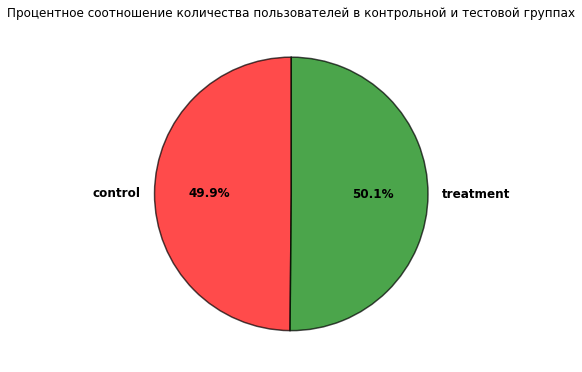

In [79]:
plt.figure(figsize=(6, 6))

groups.plot(
    kind='pie',
    title='Процентное соотношение количества пользователей в контрольной и тестовой группах',
    autopct='%.1f%%',
    ylabel='',
    colors=['red', 'green'],
    startangle=90,  
    textprops={'fontsize': 12, 'weight': 'bold'}, 
    wedgeprops={'edgecolor': 'black', 'linewidth': 1.5, 'alpha': 0.7}
)

plt.tight_layout() 
plt.show()


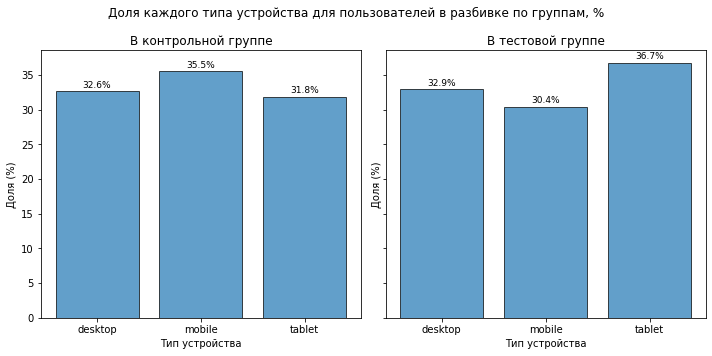

In [80]:
# Равномерность разделения пользователей по устройствам
# Рассчитываем данные для группы А
group_a_only = users[users['group'] == 'control'].groupby('device')['user_id'].nunique().reset_index()
group_a_only['share'] = (group_a_only['user_id']/group_a_only['user_id'].sum()*100).round(1)

# Рассчитываем данные для группы В
group_b_only = users[users['group'] == 'treatment'].groupby('device')['user_id'].nunique().reset_index()
group_b_only['share'] = (group_b_only['user_id']/group_b_only['user_id'].sum()*100).round(1)

# Визуализируем
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
# Доли в контрольной группе
diagr1 = ax1.bar(group_a_only['device'], group_a_only['share'], edgecolor='black', alpha=0.7)
ax1.set_title('В контрольной группе')
ax1.set_xlabel('Тип устройства')
ax1.set_ylabel('Доля (%)')
for bar in diagr1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, 
              height + 0.3, 
              f'{height:.1f}%',
              ha='center', 
              va='bottom', 
              fontsize=9)
    
# Доли в тестовой группе
diagr2 = ax2.bar(group_b_only['device'], group_b_only['share'], edgecolor='black', alpha=0.7)
ax2.set_title('В тестовой группе')
ax2.set_xlabel('Тип устройства')
ax2.set_ylabel('Доля (%)')
for bar in diagr2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width() / 2,
              height + 0.3,
              f'{height:.1f}%',
              ha='center',
              va='bottom',
              fontsize=9)

plt.suptitle('Доля каждого типа устройства для пользователей в разбивке по группам, %')
plt.tight_layout()
plt.show()

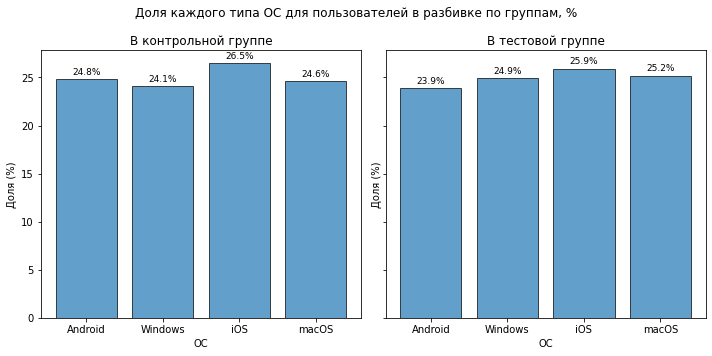

In [81]:
# Равномерность разделения пользователей по ОС
# Рассчитываем данные для группы А
group_a_only = users[users['group'] == 'control'].groupby('os')['user_id'].nunique().reset_index()
group_a_only['share'] = (group_a_only['user_id']/group_a_only['user_id'].sum()*100).round(1)

# Рассчитываем данные для группы В
group_b_only = users[users['group'] == 'treatment'].groupby('os')['user_id'].nunique().reset_index()
group_b_only['share'] = (group_b_only['user_id']/group_b_only['user_id'].sum()*100).round(1)

# Визуализируем
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
# Доли в контрольной группе
diagr1 = ax1.bar(group_a_only['os'], group_a_only['share'], edgecolor='black', alpha=0.7)
ax1.set_title('В контрольной группе')
ax1.set_xlabel('ОС')
ax1.set_ylabel('Доля (%)')
for bar in diagr1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, 
              height + 0.3, 
              f'{height:.1f}%',
              ha='center', 
              va='bottom', 
              fontsize=9)
    
# Доли в тестовой группе
diagr2 = ax2.bar(group_b_only['os'], group_b_only['share'], edgecolor='black', alpha=0.7)
ax2.set_title('В тестовой группе')
ax2.set_xlabel('ОС')
ax2.set_ylabel('Доля (%)')
for bar in diagr2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width() / 2,
              height + 0.3,
              f'{height:.1f}%',
              ha='center',
              va='bottom',
              fontsize=9)

plt.suptitle('Доля каждого типа ОС для пользователей в разбивке по группам, %')
plt.tight_layout()
plt.show()

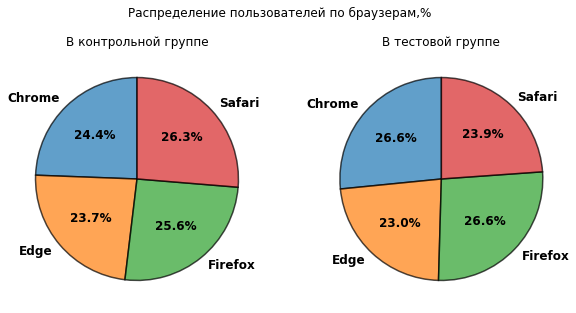

In [82]:
# Равномерность распределения пользователей по браузерам
# Рассчитываем данные для группы А
group_a_only_br = users[users['group'] == 'control'].groupby('browser')['user_id'].nunique().reset_index()
group_a_only_br['share'] = (group_a_only_br['user_id']/group_a_only_br['user_id'].sum()*100).round(1)

# Рассчитываем данные для группы В
group_b_only_br = users[users['group'] == 'treatment'].groupby('browser')['user_id'].nunique().reset_index()
group_b_only_br['share'] = (group_b_only_br['user_id']/group_b_only_br['user_id'].sum()*100).round(1)

# Визуализируем
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Группа A
ax1.pie(
    group_a_only_br['share'],
    labels=group_a_only_br['browser'],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 12, 'weight': 'bold'}, 
    wedgeprops={'edgecolor': 'black', 'linewidth': 1.5, 'alpha': 0.7}
)
ax1.set_title('В контрольной группе')

# Группа B
ax2.pie(
    group_b_only_br['share'],
    labels=group_b_only_br['browser'],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 12, 'weight': 'bold'}, 
    wedgeprops={'edgecolor': 'black', 'linewidth': 1.5, 'alpha': 0.7}
)
ax2.set_title('В тестовой группе')

plt.suptitle('Распределение пользователей по браузерам,%')
plt.show()

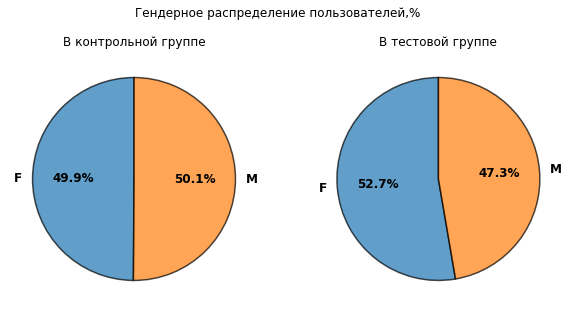

In [83]:
# Гендерное распределение пользователей
# Рассчитываем данные для контрольной группы
group_a_only_g = users[users['group'] == 'control'].groupby('gender')['user_id'].nunique().reset_index()
group_a_only_g['share'] = (group_a_only_g['user_id']/group_a_only_g['user_id'].sum()*100).round(1)

# Рассчитываем данные для тестовой группы
group_b_only_g = users[users['group'] == 'treatment'].groupby('gender')['user_id'].nunique().reset_index()
group_b_only_g['share'] = (group_b_only_g['user_id']/group_b_only_g['user_id'].sum()*100).round(1)

# Визуализируем
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Группа A
ax1.pie(
    group_a_only_g['share'],
    labels=group_a_only_g['gender'],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 12, 'weight': 'bold'}, 
    wedgeprops={'edgecolor': 'black', 'linewidth': 1.5, 'alpha': 0.7}
)
ax1.set_title('В контрольной группе')

# Группа B
ax2.pie(
    group_b_only_g['share'],
    labels=group_b_only_g['gender'],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 12, 'weight': 'bold'}, 
    wedgeprops={'edgecolor': 'black', 'linewidth': 1.5, 'alpha': 0.7}
)
ax2.set_title('В тестовой группе')

plt.suptitle('Гендерное распределение пользователей,%')
plt.show()

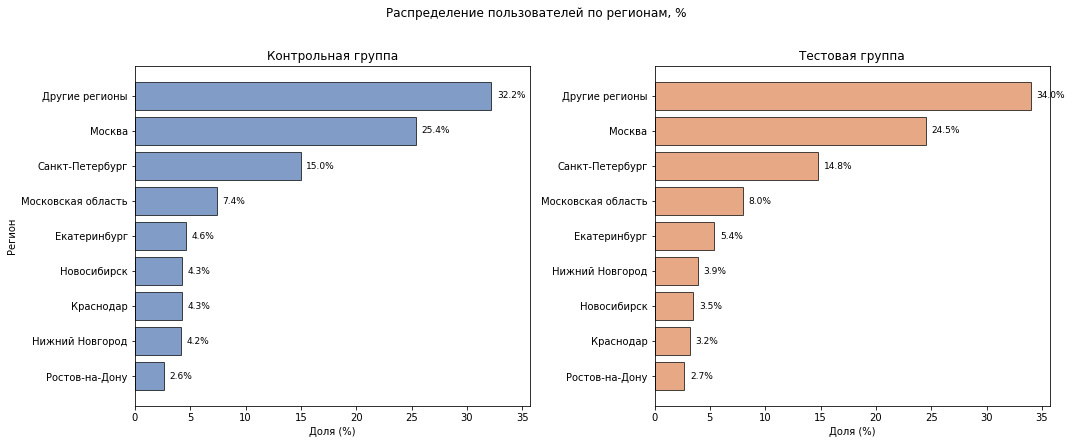

In [84]:
# Распределение пользователей по регионам
# Рассчитываем данные для контрольной группы
group_a_only_regi = users[users['group'] == 'control'].groupby('region')['user_id'].nunique().reset_index().sort_values(by='user_id')
group_a_only_regi['share'] = (group_a_only_regi['user_id']/group_a_only_regi['user_id'].sum()*100).round(1)

# Рассчитываем данные для тестовой группы
group_b_only_regi = users[users['group'] == 'treatment'].groupby('region')['user_id'].nunique().reset_index().sort_values(by='user_id')
group_b_only_regi['share'] = (group_b_only_regi['user_id']/group_b_only_regi['user_id'].sum()*100).round(1)

# Визуализируем
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharex=True)  # общая шкала X для сравнения

# Контрольная группа
bars1 = ax1.barh(group_a_only_regi['region'], group_a_only_regi['share'],
                 edgecolor='black', alpha=0.7, color='#4c72b0')
ax1.set_title('Контрольная группа')
ax1.set_xlabel('Доля (%)')
ax1.set_ylabel('Регион')

for bar in bars1:
    width = bar.get_width()
    y_pos = bar.get_y() + bar.get_height() / 2
    ax1.text(width + 0.5, y_pos, f'{width:.1f}%',
             va='center', ha='left', fontsize=9)

# Тестовая группа
bars2 = ax2.barh(group_b_only_regi['region'], group_b_only_regi['share'],
                 edgecolor='black', alpha=0.7, color='#dd8452')
ax2.set_title('Тестовая группа')
ax2.set_xlabel('Доля (%)')
ax2.set_ylabel('')

for bar in bars2:
    width = bar.get_width()
    y_pos = bar.get_y() + bar.get_height() / 2
    ax2.text(width + 0.5, y_pos, f'{width:.1f}%',
             va='center', ha='left', fontsize=9)

plt.suptitle('Распределение пользователей по регионам, %', y=1.02)
plt.tight_layout()
plt.show()

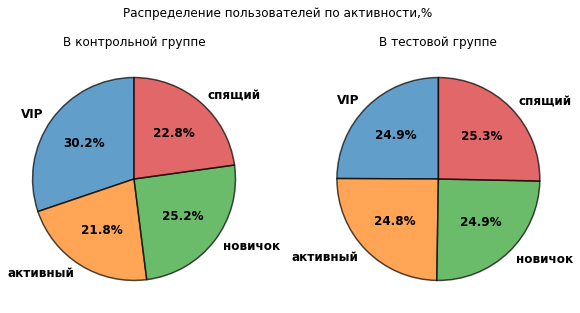

In [85]:
# Распределение пользователей по активности
# Рассчитываем данные для контрольной группы
group_a_only_user_segment = users[users['group'] == 'control'].groupby('user_segment')['user_id'].nunique().reset_index()
group_a_only_user_segment['share'] = (group_a_only_user_segment['user_id']/group_a_only_user_segment['user_id'].sum()*100).round(1)

# Рассчитываем данные для тестовой группы
group_b_only_user_segment = users[users['group'] == 'treatment'].groupby('user_segment')['user_id'].nunique().reset_index()
group_b_only_user_segment['share'] = (group_b_only_user_segment['user_id']/group_b_only_user_segment['user_id'].sum()*100).round(1)

# Визуализируем
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Группа A, контрольная
ax1.pie(
    group_a_only_user_segment['share'],
    labels=group_a_only_user_segment['user_segment'],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 12, 'weight': 'bold'}, 
    wedgeprops={'edgecolor': 'black', 'linewidth': 1.5, 'alpha': 0.7}
)
ax1.set_title('В контрольной группе')

# Группа B, тестовая
ax2.pie(
    group_b_only_user_segment['share'],
    labels=group_b_only_user_segment['user_segment'],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 12, 'weight': 'bold'}, 
    wedgeprops={'edgecolor': 'black', 'linewidth': 1.5, 'alpha': 0.7}
)
ax2.set_title('В тестовой группе')

plt.suptitle('Распределение пользователей по активности,%')
plt.show()

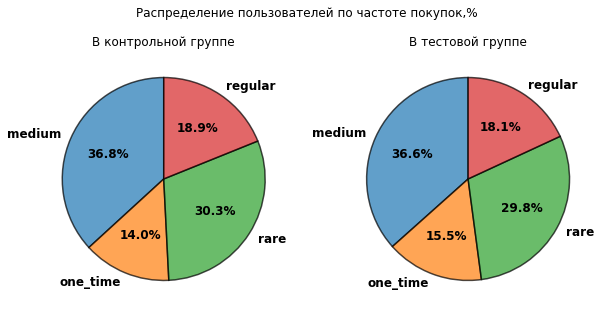

In [86]:
# Распределение пользователей по частоте покупок
# Рассчитываем данные для контрольной группы
group_a_only_buyer_segment = users[users['group'] == 'control'].groupby('buyer_segment')['user_id'].nunique().reset_index()
group_a_only_buyer_segment['share'] = (group_a_only_buyer_segment['user_id']/group_a_only_buyer_segment['user_id'].sum()*100).round(1)

# Рассчитываем данные для тестовой группы
group_b_only_buyer_segment = users[users['group'] == 'treatment'].groupby('buyer_segment')['user_id'].nunique().reset_index()
group_b_only_buyer_segment['share'] = (group_b_only_buyer_segment['user_id']/group_b_only_buyer_segment['user_id'].sum()*100).round(1)

# Визуализируем
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Группа A, контрольная
ax1.pie(
    group_a_only_buyer_segment['share'],
    labels=group_a_only_buyer_segment['buyer_segment'],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 12, 'weight': 'bold'}, 
    wedgeprops={'edgecolor': 'black', 'linewidth': 1.5, 'alpha': 0.7}
)
ax1.set_title('В контрольной группе')

# Группа B, тестовая
ax2.pie(
    group_b_only_buyer_segment['share'],
    labels=group_b_only_buyer_segment['buyer_segment'],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 12, 'weight': 'bold'}, 
    wedgeprops={'edgecolor': 'black', 'linewidth': 1.5, 'alpha': 0.7}
)
ax2.set_title('В тестовой группе')

plt.suptitle('Распределение пользователей по частоте покупок,%')
plt.show()

---

В результате проведения А/В-теста было выявлено незначительное различие в размерах групп: в контрольной группе А 1213 пользователй, в тестовой группе В 1220 пользователей. Разница составляет 0,58%, которую можно проигнорировать.<br>
При проверке на пересечение не было выявлено пользователей, которые бы оказались в обеих группах одновременно.<br>

Распределение пользователей по устройствам: пользователи десктопной версии имеют примерно одинаковую долю - около 32,5%. Пользователи мобильных устройств несколько разнятся: в контрольной 35,5%, а в тестовой - 30,4%. Также и с планшетами: в контрольной 31,8%, в тестовой - 36,7%.

Распределение пользователей по гендерному признаку тоже различается: в тестовой группе женщин больше на 2,8%, а мужчин меньше.
По степени активности разделение пользователей по группам аналогично разнятся: в контрольной группе VIP-пользователей больше (30,2%), а активных(21,8%) и спящих (22,8%) меньше, чем в тестовой (24,9%, 24,8%, 24,9% соответствено)

Распределение пользователей в разбивке по ОС в тестовой и контрольной группах примерно одинаково. Распределение по браузерам, регионам и частоте покупок также не имеет критичных различий между группами. 

Распределение не вполне корректно для строгого A/B‑теста: хотя по размеру групп и ряду признаков (ОС, браузеры, регионы, частота покупок) баланс есть, по ключевым сегментам (устройства, пол, активность) наблюдаются перекосы, которые могут исказить эффект теста.

---

**3 Рассчитаем конверсию в первую покупку и определим статистическую значимость роста конверсии в тестовой группе**

In [87]:
cohort_users_control = users.copy()
cohort_users_control['registration_date'] = cohort_users_control['registration_date'].dt.date
cohort_users_control = cohort_users_control[cohort_users_control['group']=='control'].groupby('registration_date')['user_id'].nunique().reset_index(name='users_control')
cohort_users_control['cohort_week'] = ['2025-01-01', '2025-01-01','2025-01-01','2025-01-01','2025-01-01','2025-01-01','2025-01-01',
                                      '2025-01-08', '2025-01-08', '2025-01-08', '2025-01-08', '2025-01-08', '2025-01-08', '2025-01-08',
                                      '2025-01-15', '2025-01-15', '2025-01-15', '2025-01-15', '2025-01-15', '2025-01-15', '2025-01-15']
cohort_users_control_week = cohort_users_control.groupby(['cohort_week'])['users_control'].sum().reset_index()

In [88]:
cohort_users_test = users.copy()
cohort_users_test['registration_date'] = cohort_users_test['registration_date'].dt.date
cohort_users_test = cohort_users_test[cohort_users_test['group']=='treatment'].groupby('registration_date')['user_id'].nunique().reset_index(name='users_test')
cohort_users_test['cohort_week'] = ['2025-01-01', '2025-01-01','2025-01-01','2025-01-01','2025-01-01','2025-01-01','2025-01-01',
                                      '2025-01-08', '2025-01-08', '2025-01-08', '2025-01-08', '2025-01-08', '2025-01-08', '2025-01-08',
                                      '2025-01-15', '2025-01-15', '2025-01-15', '2025-01-15', '2025-01-15', '2025-01-15', '2025-01-15']
cohort_users_test_week = cohort_users_test.groupby(['cohort_week'])['users_test'].sum().reset_index()

In [89]:
cohort_orders_control = orders.copy()
cohort_orders_control['order_date'] = cohort_orders_control['order_date'].dt.date
cohort_orders_control = cohort_orders_control.drop_duplicates(subset=['user_id'], keep='first')
cohort_orders_control = cohort_orders_control[cohort_orders_control['group']=='control'].groupby('order_date')['user_id'].nunique().reset_index(name='orders_control')
cohort_orders_control['cohort_week'] = ['2025-01-01', '2025-01-01',
                                      '2025-01-08', '2025-01-08', '2025-01-08', '2025-01-08',
                                      '2025-01-15', '2025-01-15', '2025-01-15']
cohort_orders_control_week = cohort_orders_control.groupby(['cohort_week'])['orders_control'].sum().reset_index()


In [90]:
cohort_orders_test = orders.copy()
cohort_orders_test['order_date'] = cohort_orders_test['order_date'].dt.date
cohort_orders_test = cohort_orders_test.drop_duplicates(subset=['user_id'], keep='first')
cohort_orders_test = cohort_orders_test[cohort_orders_test['group']=='treatment'].groupby('order_date')['user_id'].nunique().reset_index(name='orders_test')
cohort_orders_test['cohort_week'] = ['2025-01-01', '2025-01-01', '2025-01-01', '2025-01-01', '2025-01-01', '2025-01-01',
                                      '2025-01-08', '2025-01-08', '2025-01-08', '2025-01-08', '2025-01-08', '2025-01-08', '2025-01-08',
                                      '2025-01-15', '2025-01-15', '2025-01-15', '2025-01-15', '2025-01-15', '2025-01-15', '2025-01-15']
cohort_orders_test_week = cohort_orders_test.groupby(['cohort_week'])['orders_test'].sum().reset_index()


In [91]:
reg_AB = pd.merge(cohort_users_control[['registration_date', 'users_control']] , cohort_users_test[['registration_date', 'users_test']], on='registration_date').rename(columns={'registration_date':'date'})
order_AB = pd.merge(cohort_orders_control[['order_date', 'orders_control']] , cohort_orders_test[['order_date', 'orders_test']]).rename(columns={'order_date':'date'})
conv_AB = pd.merge(reg_AB, order_AB, on='date', how='left')
conv_AB['conv_control'] = (conv_AB['orders_control'] / conv_AB['users_control']*100).fillna(0)
conv_AB['conv_test'] = (conv_AB['orders_test'] / conv_AB['users_test']*100).fillna(0)


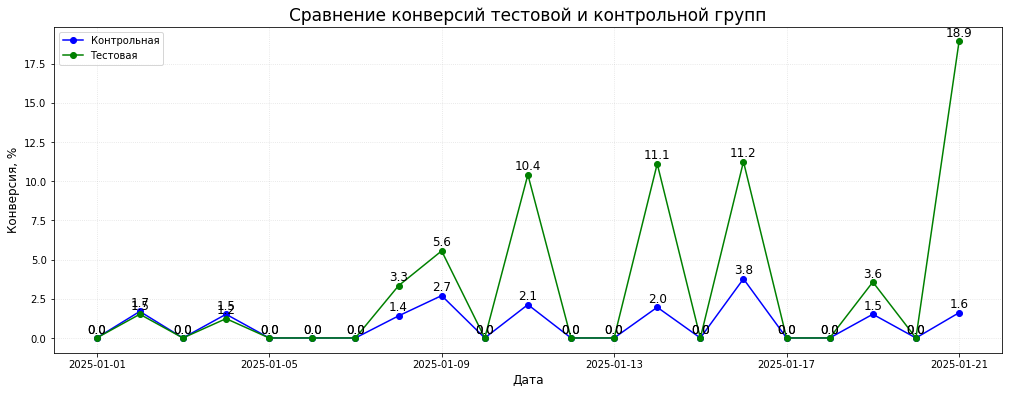

In [92]:
plt.subplots(figsize=(17,6))

plt.plot(conv_AB['date'], conv_AB['conv_control'], marker='o', color='blue', label='Контрольная')
for x, y in zip(conv_AB['date'], conv_AB['conv_control']):
    plt.annotate(
        f'{y:.1f}',  
        xy=(x, y),
        xytext=(0, 5), 
        textcoords='offset points',
        ha='center',
        fontsize=12,
        color='black'
    )

plt.plot(conv_AB['date'], conv_AB['conv_test'], marker='o', color='green', label='Тестовая')  
for x, y in zip(conv_AB['date'], conv_AB['conv_test']):
    plt.annotate(
        f'{y:.1f}',  
        xy=(x, y),
        xytext=(0, 5), 
        textcoords='offset points',
        ha='center',
        fontsize=12,
        color='black'
    )
                              
plt.title('Сравнение конверсий тестовой и контрольной групп', fontsize=17)
plt.legend()
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Конверсия, %', fontsize=12)
plt.xticks()
plt.grid(linestyle=':', alpha=0.4)
plt.show()

Видно, что поведение метрик сильно различается: у тестовой группы наблюдаются резкие всплески, а у контрольной - более сглаженная линия.

Особенности:
- резкие пики в тестовой группе, максимум приходтится на 21 января и составляет 18,9%
- нулевые значения. В отдельные дни конверсия в обеих группах равна 0 %. Такие падения вызваны отсутствием заказов в отдельные дни
- стабильно низкая конверсия в контрольной группе. Даже на фоне всплесков в тесте контрольная группа остаётся на низком уровне (до 4%), что может говорить о слабой активности или о том, что тест затронул более горячий сегмент.

*Определим статистическую значимость роста конверсии в тестовой группе*

In [93]:
conv_test_1 = conv_AB ['orders_control'].sum()
conv_test_2 = conv_AB ['orders_test'].sum()
conv_test_3 = conv_AB ['users_control'].sum()
conv_test_4 = conv_AB ['users_test'].sum()

In [94]:
alpha = 0.05
stat_ztest, p_value_ztest = proportions_ztest ([conv_test_1,conv_test_2], 
                                               [conv_test_3,conv_test_4], 
                                               alternative="smaller")
print('p-значение:', p_value_ztest)
print ('z-статистика:', stat_ztest.round(4))
if p_value_ztest<alpha:
    print ('Отвергаем нулевую гипотезу, результат статистически значим')
else:
    print ('Не получилось отвергнуть нулевую гипотезу, нет статистической значимости')

p-значение: 5.892219277259401e-05
z-статистика: -3.8506
Отвергаем нулевую гипотезу, результат статистически значим


**4 Проведем расчет вспомогательных метрик**

*1) ARPU (средняя выручка на пользователя TikTok) и ARPPU (средняя выручка на покупателя TikTok)*

In [95]:
def arpu_arppu(group):
    users_for_arpu = users.copy()
    users_for_arpu['date'] = users_for_arpu['registration_date'].dt.date

    revenue_for_arppu = orders.copy()
    revenue_for_arppu['date'] = revenue_for_arppu['order_date'].dt.date
    
    users_for_arpu = users_for_arpu[users_for_arpu['group']==group]
    users_for_arpu = users_for_arpu.groupby('date')['user_id'].nunique().reset_index(name='users')
    revenue_for_arppu = revenue_for_arppu[revenue_for_arppu['group']==group]
    revenue_for_arppu = revenue_for_arppu.groupby('date').agg(total_sum=('total_price', 'sum'),
                                                          buyers=('user_id', 'nunique')).reset_index()
    
    revenues_AB = pd.merge(users_for_arpu, revenue_for_arppu, on='date', how='left')
    revenues_AB['arpu'] = (revenues_AB['total_sum'] / revenues_AB['users']).fillna(0)
    revenues_AB['arppu'] = (revenues_AB['total_sum'] / revenues_AB['buyers']).fillna(0)
    revenues_AB[['total_sum', 'buyers']] = revenues_AB[['total_sum', 'buyers']].fillna(0)
    return revenues_AB

In [96]:
control_revenues_AB = arpu_arppu('control')
test_revenues_AB = arpu_arppu('treatment')

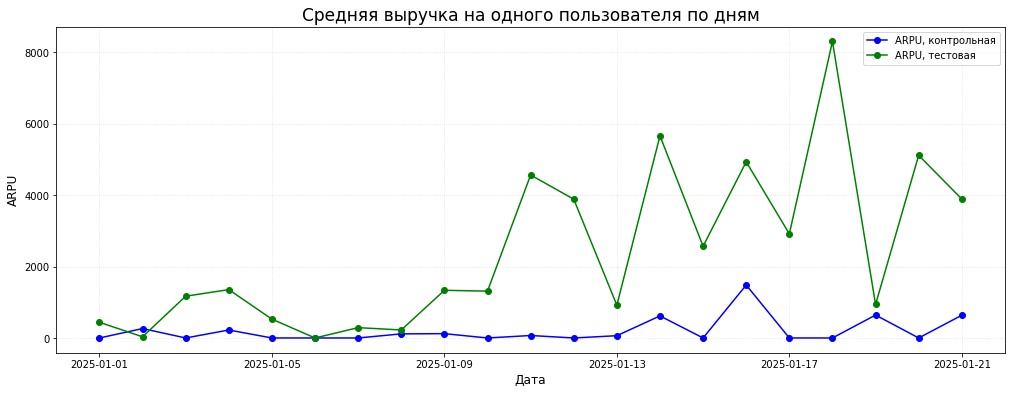

In [97]:
plt.subplots(figsize=(17,6))

plt.plot(control_revenues_AB['date'], control_revenues_AB['arpu'], 
         marker='o', color='blue', label='ARPU, контрольная')

plt.plot(test_revenues_AB['date'], test_revenues_AB['arpu'], marker='o', color='green', label='ARPU, тестовая')

plt.title('Cредняя выручка на одного пользователя по дням', fontsize=17)
plt.legend()
plt.xlabel('Дата', fontsize=12)
plt.ylabel('ARPU', fontsize=12)
plt.xticks()
plt.grid(linestyle=':', alpha=0.4)
plt.show()

ARPU в тестовой группе выше, чем в контрольной, за исключением отдельных дней в начале периода. Наблюдается высокая волатильность в тестовой группе: резкие пики и спады, что может указывать на точечные акции, изменения в монетизации. ARPU в контрольной группе остаётся относительно стабильным в диапазоне 0-1500 руб. Максимальный разрыв между группами фиксируется 18 января: ARPU тестовой группы превышает показатель контрольной более чем в 10 раз.

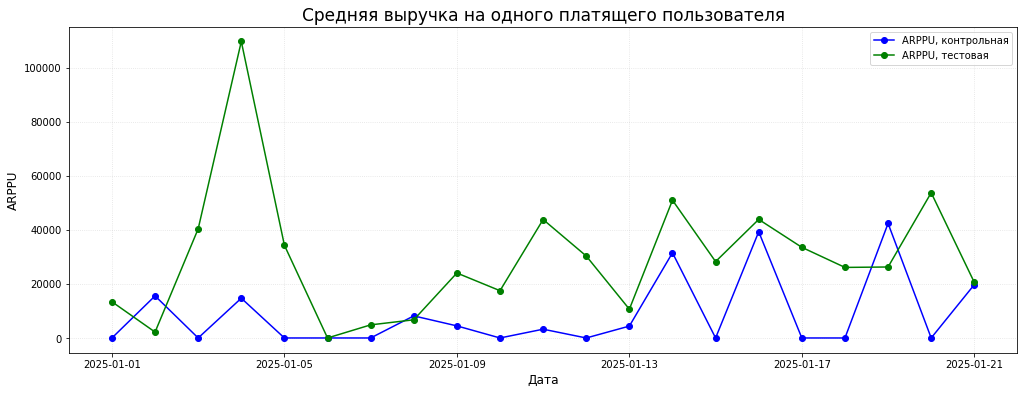

In [98]:
plt.subplots(figsize=(17,6))

plt.plot(control_revenues_AB['date'], control_revenues_AB['arppu'], 
         marker='o', color='blue', label='ARPPU, контрольная')  

plt.plot(test_revenues_AB['date'], test_revenues_AB['arppu'], marker='o', color='green', label='ARPPU, тестовая')  

plt.title('Cредняя выручка на одного платящего пользователя', fontsize=17)
plt.legend()
plt.xlabel('Дата', fontsize=12)
plt.ylabel('ARPPU', fontsize=12)
plt.xticks()
plt.grid(linestyle=':', alpha=0.4)
plt.show()

Особенности:
- Резкий всплеск ARPPU в тестовой группе 3-4 января: значение превышает 100 000 руб. Такая аномалия может быть вызвана единичными крупными платежами, ошибкой учёта или точечной акцией с высоким чеком.
- Высокая волатильность тестовой группы: после пика 4 января показатель падает до 3500 руб. к 5 января, затем наблюдаются повторяющиеся пики и спады. Это говорит о нестабильности монетизации или о влиянии внешних факторов (акции, реферальные программы, технические сбои).
- Стабильность контрольной группы: значения колеблются в диапазоне 0-42000 руб. При этом большинство дней демонстрируют ARPPU ниже 15000 руб., что пиков тестовой группы, но без экстремальных выбросов.
- В отдельные дни ARPPU контрольной группы приближается к или превышает показатели тестовой группы, что может указывать на временные изменения в поведении пользователей или на влияние внешних событий. В целом тестовая группа располагается выше контрольной, что говорит о более высокой средней выручке на платящего пользователя в тесте.

*Определим статистическую значимость ARPU*

In [99]:
users_for_arpu = users.copy()
revenue_for_arppu = orders.copy()

In [100]:
users_for_arpu_с = users_for_arpu[users_for_arpu['group']=='control']
users_for_arpu_с = users_for_arpu_с.drop_duplicates(subset=['user_id'], keep='first')

users_for_arpu_t = users_for_arpu[users_for_arpu['group']=='treatment']
users_for_arpu_t = users_for_arpu_t.drop_duplicates(subset=['user_id'], keep='first')

In [101]:
revenue_for_arppu_c = revenue_for_arppu[revenue_for_arppu['group']=='control']
revenue_for_arppu_c = revenue_for_arppu_c.groupby('user_id').agg(orders=('order_id','count'),
                                                                 total_sum=('total_price','sum')).reset_index()
revenue_for_arppu_c['arppu'] = revenue_for_arppu_c['total_sum']/revenue_for_arppu_c['orders']

revenue_for_arppu_t = revenue_for_arppu[revenue_for_arppu['group']=='treatment']
revenue_for_arppu_t = revenue_for_arppu_t.groupby('user_id').agg(orders=('order_id','count'),
                                                                 total_sum=('total_price','sum')).reset_index()
revenue_for_arppu_t['arppu'] = revenue_for_arppu_t['total_sum']/revenue_for_arppu_t['orders']

In [102]:
for_test_c = pd.merge(users_for_arpu_с, revenue_for_arppu_c, how='left')
for_test_t = pd.merge(users_for_arpu_t, revenue_for_arppu_t, how='left')

In [103]:
for_test_c['arpu'] = for_test_c['arppu'].fillna(0)
for_test_t['arpu'] = for_test_t['arppu'].fillna(0)

In [104]:
c_arpu = for_test_c['arpu']
t_arpu = for_test_c['arpu']

In [105]:
t_stat, p_value = ttest_ind(c_arpu, t_arpu, equal_var=False, alternative='less')
print(f"p-value: {p_value:.4f}")
print(f"t-статистика: {t_stat:.4f}")
if p_value<alpha:
    print (f'Отвергаем нулевую гипотезу, результат статистически значим')
else:
    print (f'Не получилось отвергнуть нулевую гипотезу, нет статистической значимости')

p-value: 0.5000
t-статистика: 0.0000
Не получилось отвергнуть нулевую гипотезу, нет статистической значимости


*Определим статистическую значимость ARPPU*

In [106]:
c_arppu = revenue_for_arppu_c['arppu']
t_arppu = revenue_for_arppu_t['arppu']

In [107]:
t_stat, p_value = ttest_ind(c_arppu, t_arppu, equal_var=False, alternative='less')
print(f"p-value: {p_value:.4f}")
print(f"t-статистика: {t_stat:.4f}")
if p_value<alpha:
    print (f'Отвергаем нулевую гипотезу, результат статистически значим')
else:
    print (f'Не получилось отвергнуть нулевую гипотезу, нет статистической значимости')

p-value: 0.8101
t-статистика: 0.9168
Не получилось отвергнуть нулевую гипотезу, нет статистической значимости


*2) AOV (средний чек TikTok)*

In [108]:
AOV = orders.copy()
AOV['date'] = AOV['order_date'].dt.date

# Контрольная
AOV_control = AOV[AOV['group']=='control']
AOV_control1 = AOV_control.groupby('date').agg(total_price=('total_price', 'sum'),
                                              quantity=('quantity', 'sum')).reset_index()
AOV_control1['aov'] = AOV_control1['total_price'] / AOV_control1['quantity']

# Тестовая
AOV_test = AOV[AOV['group']=='treatment']
AOV_test1 = AOV_test.groupby('date').agg(total_price=('total_price', 'sum'),
                                        quantity=('quantity', 'sum')).reset_index()
AOV_test1['aov'] = AOV_test1['total_price'] / AOV_test1['quantity']



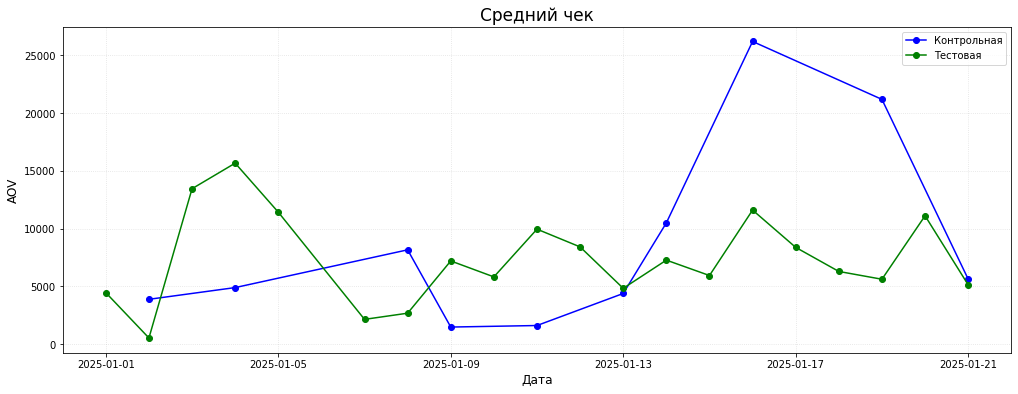

In [109]:
plt.subplots(figsize=(17,6))

plt.plot(AOV_control1['date'], AOV_control1['aov'], 
         marker='o', color='blue', label='Контрольная')

plt.plot(AOV_test1['date'], AOV_test1['aov'], marker='o', color='green', label='Тестовая')

plt.title('Средний чек', fontsize=17)
plt.legend()
plt.xlabel('Дата', fontsize=12)
plt.ylabel('AOV', fontsize=12)
plt.xticks()
plt.grid(linestyle=':', alpha=0.4)
plt.show()

Ключевые особенности:
- Резкий всплеск среднего чека в контрольной группе 16 января: значение достигает 26000 руб., что превышает все остальные показатели на графике. Это может быть связано с точечной акцией (например, распродажей дорогих товаров), изменением состава заказов или технической аномалией в учёте.
- Высокая волатильность тестовой группы в начале периода: 2 января AOV падает почти до нуля, а затем резко растёт до 13500 руб. 3 января и до 15500 руб. 4 января. Такая динамика может указывать на нестабильность выборки (например, малое количество заказов в отдельные дни) или на влияние внешних факторов.
- Сближение показателей 13 января: значения AOV в обеих группах практически совпадают (4500-5000 руб.), что может свидетельствовать о временном выравнивании поведения пользователей или об отсутствии эффекта от тестируемых изменений.
- Резкое падение обоих показателей к 21 января: средний чек в обеих группе снижается до 5000 руб.

Общая тенденция: в первой половине периода (до 13 января) средний чек в тестовой группе чаще выше, чем в контрольной, за исключением отдельных дней. Во второй половине периода (после 13 января) контрольная группа демонстрирует более высокие значения, главным образом за счёт аномального пика 16 января.

*Рассчитаем статистическую значимость AOV*

In [110]:
c_aov = AOV_control['total_price']
t_aov = AOV_test['total_price']

In [111]:
t_stat, p_value = ttest_ind(c_aov, t_aov, equal_var=False, alternative='less')
print(f"p-value: {p_value:.4f}")
print(f"t-статистика: {t_stat:.4f}")
if p_value<alpha:
    print (f'Отвергаем нулевую гипотезу, результат статистически значим')
else:
    print (f'Не получилось отвергнуть нулевую гипотезу, нет статистической значимости')

p-value: 0.6320
t-статистика: 0.3429
Не получилось отвергнуть нулевую гипотезу, нет статистической значимости


**Барьерная метрика: Общая выручка от пользователей TikTok**

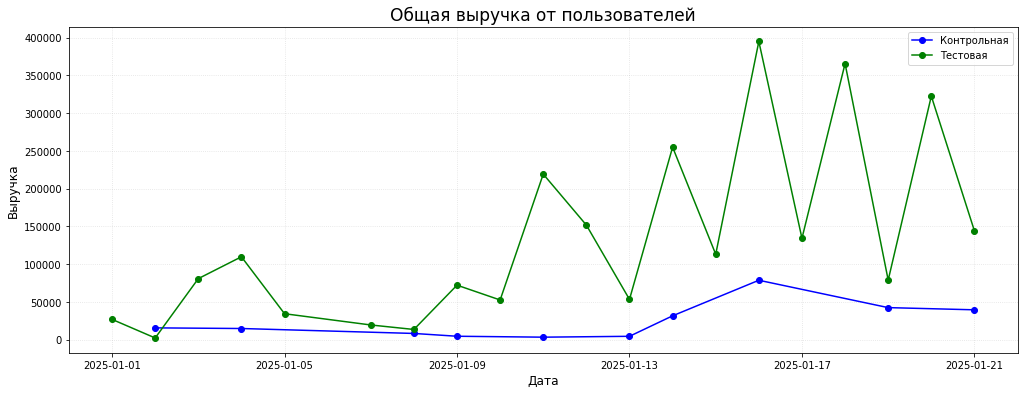

In [112]:
plt.subplots(figsize=(17,6))

plt.plot(AOV_control1['date'], AOV_control1['total_price'], 
         marker='o', color='blue', label='Контрольная')

plt.plot(AOV_test1['date'], AOV_test1['total_price'], marker='o', color='green', label='Тестовая')

plt.title('Общая выручка от пользователей', fontsize=17)
plt.legend()
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Выручка', fontsize=12)
plt.xticks()
plt.grid(linestyle=':', alpha=0.4)
plt.show()

На графике видна сильная волатильность выручки в тестовой группе при стабильно низком уровне в контрольной.

Контрольная группа демонстрирует низкий уровень выручки на старте (близко к 0–20 000 руб.), затем плавный рост до пика примерно в 80 000 руб. (около 15 января) и последующее снижение до 40 000 руб. к концу периода. Волатильность минимальна, тренд - умеренный рост с последующим спадом.

Тестовая группа характеризуется высокой волатильностью с резкими пиками и провалами. Начальные значения сопоставимы с контрольной группой, но уже к 3–4 января выручка резко возрастает до 110 000 руб. Далее наблюдаются экстремальные всплески, максимум 390 000 руб. (16 января).

*Определим статистическую значимость общей выручки*

Для этого используем бутстрап

In [113]:
np.random.seed(341)

data_control = AOV_control['total_price']
data_test = AOV_test['total_price']

n_iterations = 1000
boot_diffs = []

# Бутстрап-разница 25-х перцентилей между тестовой и контрольной группами
for i in range(n_iterations):
    boot_control = np.random.choice(data_control, size=len(data_control), replace=True)
    boot_test = np.random.choice(data_test, size=len(data_test), replace=True)

    # Для расчёта 25 перцентиля используем .percentile() из библиотеки numpy 
    control_25p = np.percentile(boot_control, 25)
    test_25p = np.percentile(boot_test, 25)

    # Находим разницу между значениями тестовой и контрольной групп
    boot_diffs.append(test_25p - control_25p)

# Создаём массив разниц между 25-ми перцентилями тестовой и контрольной групп
boot_diffs = np.array(boot_diffs)

# Доверительный интервал разницы между 25-ми перцентилями (перцентильный метод)
diff_ci = np.percentile(boot_diffs, [2.5, 97.5])

# Вывод доверительного интервала
print(f"25-й перцентиль контрольной группы: {np.percentile(data_control, 25):.2f}")
print(f"25-й перцентиль тестовой группы: {np.percentile(data_test, 25):.2f}")
print(f"95%-й доверительный интервал разности 25-х перцентилей [{diff_ci[0]:.2f}, {diff_ci[1]:.2f}]")

25-й перцентиль контрольной группы: 6645.10
25-й перцентиль тестовой группы: 2452.34
95%-й доверительный интервал разности 25-х перцентилей [-9459.25, -1313.46]


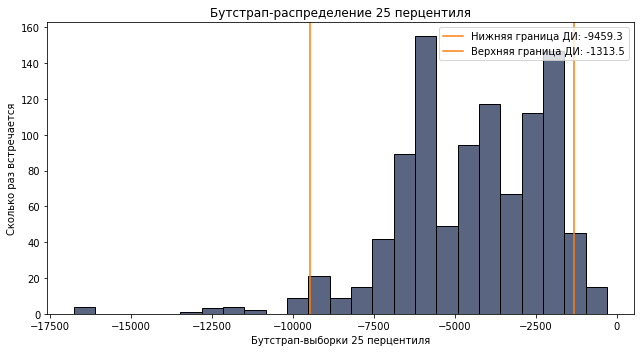

In [114]:
# Визуализация
plt.figure(figsize=(9, 5))
plt.hist(
   boot_diffs,
   bins=25,
   color='#586381',
   edgecolor='black',
   alpha=0.99
)


plt.axvline(
   diff_ci[0],
   color='#ff7f0e',
   linestyle='solid',
   label=f'Нижняя граница ДИ: {diff_ci[0]:.1f}'
)
plt.axvline(
   diff_ci[1],
   color='#ff7f0e',
   linestyle='solid',
   label=f'Верхняя граница ДИ: {diff_ci[1]:.1f}'
)

plt.title('Бутстрап-распределение 25 перцентиля')
plt.xlabel('Бутстрап-выборки 25 перцентиля')
plt.ylabel('Сколько раз встречается')
plt.legend(loc='upper right')
plt.gca().set_facecolor('white')
plt.tight_layout()
plt.show()

In [115]:
boot_diffs = []

# Бутстрап-разница 50-х перцентилей между тестовой и контрольной группами
for i in range(n_iterations):
    boot_control = np.random.choice(data_control, size=len(data_control), replace=True)
    boot_test = np.random.choice(data_test, size=len(data_test), replace=True)

    # Для расчёта 50 перцентиля используем .percentile() из библиотеки numpy 
    control_50p = np.percentile(boot_control, 50)
    test_50p = np.percentile(boot_test, 50)

    # Находим разницу между значениями тестовой и контрольной групп
    boot_diffs.append(test_50p - control_50p)

# Создаём массив разниц между 50-ми перцентилями тестовой и контрольной групп
boot_diffs = np.array(boot_diffs)

# Доверительный интервал разницы между 50-ми перцентилями (перцентильный метод)
diff_ci = np.percentile(boot_diffs, [2.5, 97.5])

# Вывод доверительного интервала
print(f"50-й перцентиль контрольной группы: {np.percentile(data_control, 50):.2f}")
print(f"50-й перцентиль тестовой группы: {np.percentile(data_test, 50):.2f}")
print(f"95%-й доверительный интервал разности 50-х перцентилей [{diff_ci[0]:.2f}, {diff_ci[1]:.2f}]")

50-й перцентиль контрольной группы: 10428.12
50-й перцентиль тестовой группы: 7658.35
95%-й доверительный интервал разности 50-х перцентилей [-12516.67, 2252.27]


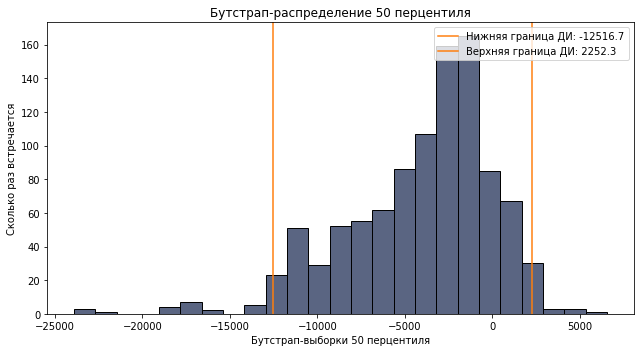

In [116]:
# Визуализация
plt.figure(figsize=(9, 5))
plt.hist(
   boot_diffs,
   bins=25,
   color='#586381',
   edgecolor='black',
   alpha=0.99
)


plt.axvline(
   diff_ci[0],
   color='#ff7f0e',
   linestyle='solid',
   label=f'Нижняя граница ДИ: {diff_ci[0]:.1f}'
)
plt.axvline(
   diff_ci[1],
   color='#ff7f0e',
   linestyle='solid',
   label=f'Верхняя граница ДИ: {diff_ci[1]:.1f}'
)

plt.title('Бутстрап-распределение 50 перцентиля')
plt.xlabel('Бутстрап-выборки 50 перцентиля')
plt.ylabel('Сколько раз встречается')
plt.legend(loc='upper right')
plt.gca().set_facecolor('white')
plt.tight_layout()
plt.show()

In [117]:
boot_diffs = []

# Бутстрап-разница 75-х перцентилей между тестовой и контрольной группами
for i in range(n_iterations):
    boot_control = np.random.choice(data_control, size=len(data_control), replace=True)
    boot_test = np.random.choice(data_test, size=len(data_test), replace=True)

    # Для расчёта 75 перцентиля используем .percentile() из библиотеки numpy 
    control_75p = np.percentile(boot_control, 75)
    test_75p = np.percentile(boot_test, 75)

    # Находим разницу между значениями тестовой и контрольной групп
    boot_diffs.append(test_75p - control_75p)

# Создаём массив разниц между 75-ми перцентилями тестовой и контрольной групп
boot_diffs = np.array(boot_diffs)

# Доверительный интервал разницы между 75-ми перцентилями (перцентильный метод)
diff_ci = np.percentile(boot_diffs, [2.5, 97.5])

# Вывод доверительного интервала
print(f"75-й перцентиль контрольной группы: {np.percentile(data_control, 75):.2f}")
print(f"75-й перцентиль тестовой группы: {np.percentile(data_test, 75):.2f}")
print(f"95%-й доверительный интервал разности 75-х перцентилей [{diff_ci[0]:.2f}, {diff_ci[1]:.2f}]")

75-й перцентиль контрольной группы: 19249.19
75-й перцентиль тестовой группы: 23654.51
95%-й доверительный интервал разности 75-х перцентилей [-20470.22, 15069.31]


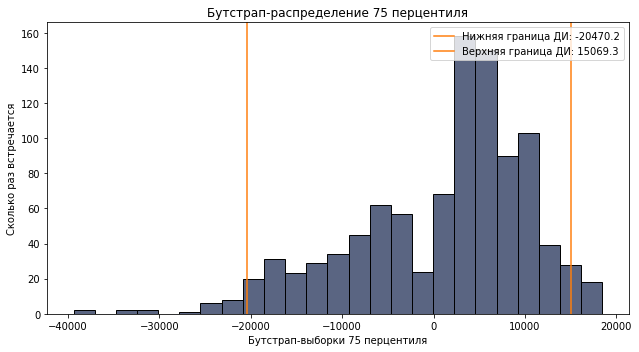

In [118]:
# Визуализация
plt.figure(figsize=(9, 5))
plt.hist(
   boot_diffs,
   bins=25,
   color='#586381',
   edgecolor='black',
   alpha=0.99
)


plt.axvline(
   diff_ci[0],
   color='#ff7f0e',
   linestyle='solid',
   label=f'Нижняя граница ДИ: {diff_ci[0]:.1f}'
)
plt.axvline(
   diff_ci[1],
   color='#ff7f0e',
   linestyle='solid',
   label=f'Верхняя граница ДИ: {diff_ci[1]:.1f}'
)

plt.title('Бутстрап-распределение 75 перцентиля')
plt.xlabel('Бутстрап-выборки 75 перцентиля')
plt.ylabel('Сколько раз встречается')
plt.legend(loc='upper right')
plt.gca().set_facecolor('white')
plt.tight_layout()
plt.show()

В сегменте самых дешёвых заказов (нижние 25%) выручка в тестовой группе упала. Снижение есть, и оно существенное - на 1300–9500 руб.

Для обычных заказов (50-й перцентиль) в большинстве выборок выручка чуть ниже, но из‑за сильной волатильности данных нельзя утверждать, что падение реально.

В сегменте более дорогих заказов (75‑й перцентиль) виден рост, но доверять результату нельзя: разброс результатов слишком большой.

Сейчас нельзя уверенно сказать, что тест сработал хорошо. Есть чёткий минус в нижнем сегменте, а плюсы в других сегментах не подтверждены.

posx and posy should be finite values
posx and posy should be finite values


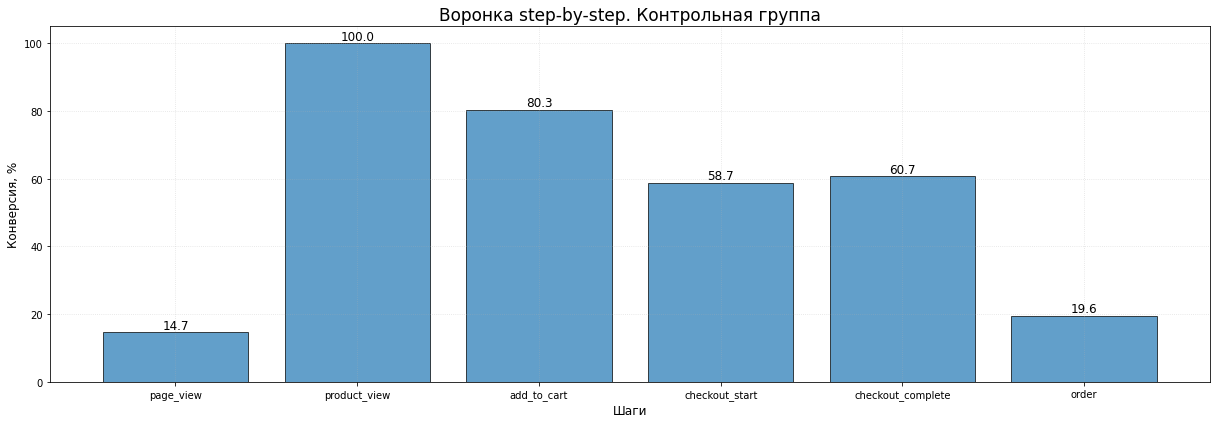

In [123]:
# Визуализируем воронки step-by-step

plt.figure(figsize=(17,6))
bars = plt.bar (funnel_control['event_type'], funnel_control['conversion_from_previous_%'],edgecolor='black', alpha=0.7)
plt.title('Воронка step-by-step. Контрольная группа', fontsize=17)
plt.xlabel('Шаги', fontsize=12)
plt.ylabel('Конверсия, %', fontsize=12)
for bar in bars.patches:
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width()/2,
                height + 0.1, 
                f'{round(height, 1)}',
                ha='center',
                va='bottom',
                fontsize=12,
                color='black',
                fontweight=500)
plt.tight_layout()
plt.grid(linestyle=':', alpha=0.4)
plt.show()

posx and posy should be finite values
posx and posy should be finite values


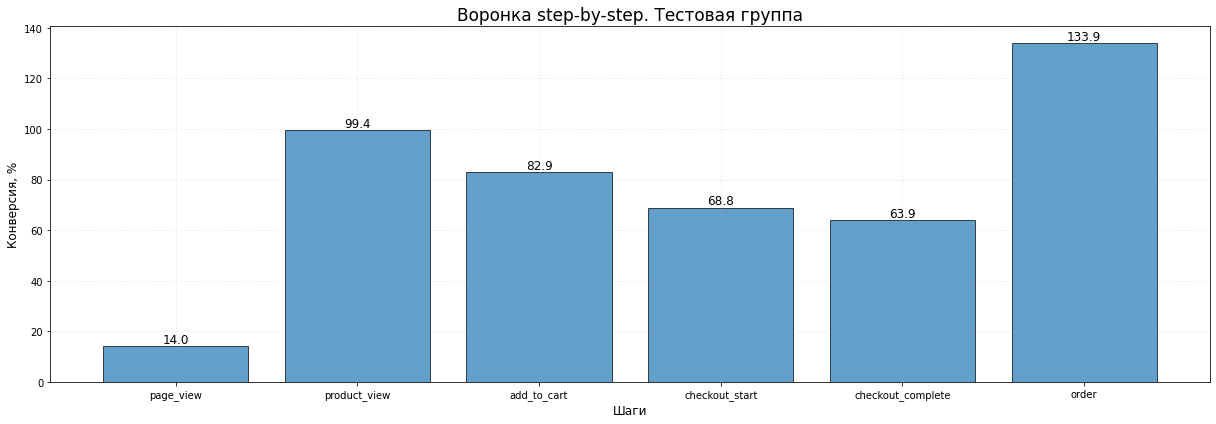

In [124]:
plt.figure(figsize=(17,6))
bars = plt.bar (funnel_test['event_type'], funnel_test['conversion_from_previous_%'],edgecolor='black', alpha=0.7)
plt.title('Воронка step-by-step. Тестовая группа', fontsize=17)
plt.xlabel('Шаги', fontsize=12)
plt.ylabel('Конверсия, %', fontsize=12)
for bar in bars.patches:
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width()/2,
                height + 0.1, 
                f'{round(height, 1)}',
                ha='center',
                va='bottom',
                fontsize=12,
                color='black',
                fontweight=500)
plt.tight_layout()
plt.grid(linestyle=':', alpha=0.4)
plt.show()

На графиках воронок step_by_step по по группам есть позитивная положительная разница в тестовой группе на этапе `add_to_cart` - 82,9% против контрольной 80,3%. Также и на последующих этапах - тестовая группа на пару процентных пункта опережает контрольную. Но и здесь ы видим аномалию на последнем шаге - `order` в тестовой группе превышает 100%. Либо данные имеют ошибку, либо не все пользователи проходят воронку и пропускают чекауты.

## Выводы по этапу 5

---
По результатам анализа можно сделать следующий вывод

Группы получились не совсем одинаковыми. В них по‑разному распределились пользователи по устройствам (мобильные, планшеты, десктоп), полу и уровню активности. Из‑за этого результаты могут быть искажены.

Конверсия в тестовой группе выросла, и это статистически значимо. То есть с большой вероятностью рост не случайный. Но при этом в контрольной группе конверсия стабильно низкая, а в тестовой - с резкими всплесками: в отдельные дни показатели сильно скачут.
Выручка и средний чек скачут в тестовой группе. Были дни, когда выручка и средний чек в тесте резко взлетали, а потом так же резко падали. Такие пики могут быть из‑за единичных крупных заказов, акций или ошибок в учёте.

По другим метрикам (ARPU, ARPPU, AOV) статистической значимости нет. Различия между группами могли получиться просто из‑за случайности или из‑за тех самых резких всплесков.

В дешёвых заказах выручка в тесте упала. В сегменте самых недорогих покупок тестовая группа показала минус. В более дорогих сегментах вроде бы есть рост, но из‑за сильной волатильности ему нельзя доверять.


Таким образом, тест дал неоднозначные результаты. С одной стороны, конверсия в тестовой группе выросла. С другой стороны, денежные метрики не стали лучше, а в дешёвых заказах выручка даже упала. При этом данные сильно искажены из‑за резких всплесков (вероятно, единичных крупных покупок) и из‑за того, что группы изначально отличались по составу пользователей.

Внедрять изменения на основе этого теста пока рано.